# Based on new label cropped dataset

# Lib

Installation / imports

In [1]:
import os
import glob
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
import math
import random
from collections import defaultdict
from torch.utils.data import Sampler, BatchSampler, DataLoader
import copy


1. vertify phone number in kaggle to allocate gpu
2. settings --> accelerator --> gpu t4 x2
3. settings --> turn on internet

4. test with NUM_EPOCHS = 1 & SCREEN_EPOCH = 1 first (even make batch_size = 4 & batch_size_list = 4), make sure theres no errors before running with NUM_EPOCHS = 30 & SCREEN_EPOCH = 5 (and batch_size = 4 & batch_size_list = 32)
5. make sure the /kaggle/working has space (5GB limit)

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.10.0+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4
capability: (7, 5)


# Dir

- load CSV annotation file
- check columns
- load image file paths
- remove missing/broken image paths if needed


In [3]:
#if local need change here
dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")

image_dir = dataset_dir / "image_crop_new/image_crop_new"
annotation_path = image_dir / "cropped_annotations.csv"

#image_dir = dataset_dir / "images/images" #original (not cropped images)
#annotation_path = dataset_dir / "labels/annotations.csv" #original dataset's csv


annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,source_image
0,train_00000_crop.jpeg,340,550,0,0,340,550,albopictus,train_00000.jpeg
1,train_00001_crop.jpeg,1050,1093,0,0,1050,1093,albopictus,train_00001.jpeg
2,train_00002_crop.jpeg,439,750,0,0,439,750,albopictus,train_00002.jpeg
3,train_00003_crop.jpeg,417,462,0,0,417,462,albopictus,train_00003.jpeg
4,train_00004_crop.jpeg,568,776,0,0,568,776,culex,train_00004.jpeg


In [4]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10485
class_label
albopictus            4655
culex                 4638
culiseta               632
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000_crop.jpeg,albopictus
1,train_00001_crop.jpeg,albopictus
2,train_00002_crop.jpeg,albopictus
3,train_00003_crop.jpeg,albopictus
4,train_00004_crop.jpeg,culex


# Label Processing
- convert species/class names into label_id
- create class_names list
- count samples per class

In [5]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

- split into:
  Train: 70%
  Validation: 15%
  Test: 15%
- use stratify=df["label_id"]


Reproducibility
- set seed = 42
- set random_state=42
- make train/val/test split consistent

In [6]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7339
Val: 1573
Test: 1573


In [7]:
# Count samples per class
class_counts = train_df["label_id"].value_counts().sort_index()
print(class_counts)

#class_weights = 1.0 / class_counts #tune with different class_weights
class_weights = 1.0 / np.sqrt(class_counts)
print(class_weights)

label_id
0      33
1    3258
2      59
3    3247
4     442
5     300
Name: count, dtype: int64
label_id
0    0.174078
1    0.017520
2    0.130189
3    0.017549
4    0.047565
5    0.057735
Name: count, dtype: float64


In [8]:
train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)

val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

print("Subset Train:", len(train_subset_df))
print("Subset Val:", len(val_subset_df))
print("Subset Test:", len(test_subset_df))

Subset Train: 283
Subset Val: 100
Subset Test: 99


/tmp/ipykernel_23/1350935851.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_23/1350935851.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_23/1350935851.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

# Augmentation / Preprocessing
Train transform:
- resize image
- random horizontal flip
- random rotation
- colour jitter
- convert to tensor
- normalise using ImageNet mean/std
  
Validation / Transform:
- resize image
- convert to tensor
- normalise using ImageNet mean/std

In [9]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Dataset
- create MosquitoDataset class
- return image tensor and label_id

In [10]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        #self.image_paths = df["label_id"].values
        #self.labels = df.iloc[:, -1].values
        self.image_paths = df['img_fName'].astype(str).values
        self.labels = df['label_id'].values

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_dir / self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# DataLoaders
- train_loader
- val_loader
- test_loader

In [11]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Model Setup

- define imbalance handling methods
- create_model()
- load pretrained ResNet50 / EfficientNet / MobileNet
- replace final classification layer
- freeze most layers
- unfreeze last layers

In [12]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)

def create_model(model_name, num_classes):
    if model_name == "efficientnet":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "mobilenet":
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model

# Imbalance Handling Setup
- class weights
- WeightedRandomSampler
- StratifiedBatchSampler
- Weighted Loss
- PF-loss
- optional focal loss

In [13]:
# WeightedRandomSampler
sample_weights = train_df["label_id"].map(class_weights).values
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # same size as train set
    replacement=True
)

# Sampler method
train_loader = DataLoader(
    train_dataset,   # your PyTorch Dataset
    batch_size=32,
    sampler=sampler,
    shuffle=False    # IMPORTANT: must be False when using sampler
)



# FocalLoss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none') 
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()



# PF-Loss
#PF-loss is not weighted loss and not sampler-based
class PFLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, inputs, targets):
        num_classes = inputs.size(1)

        probs = F.softmax(inputs, dim=1)
        true_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        class_means = []
        for c in range(num_classes):
            mask = (targets == c)
            if mask.any():
                q_c = true_probs[mask].mean()
            else:
                q_c = inputs.new_tensor(1.0)  # no loss contribution if class absent in batch
            class_means.append(q_c)

        class_means = torch.stack(class_means)
        loss = -torch.log(class_means + self.eps).mean()
        return loss



# StratifiedBatchSampler
class StratifiedBatchSampler(BatchSampler):
    def __init__(self, labels, batch_size, shuffle=True):
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_indices = {}
        for c in np.unique(self.labels):
            self.class_indices[c] = np.where(self.labels == c)[0].tolist()

        self.classes = list(self.class_indices.keys())
        self.num_classes = len(self.classes)
        self.num_batches = math.ceil(len(self.labels) / self.batch_size)

    def __iter__(self):
        pools = {c: idxs.copy() for c, idxs in self.class_indices.items()}

        if self.shuffle:
            for c in pools:
                random.shuffle(pools[c])

        for _ in range(self.num_batches):
            batch = []

            base = self.batch_size // self.num_classes
            remainder = self.batch_size % self.num_classes

            per_class = {c: base for c in self.classes}
            for c in self.classes[:remainder]:
                per_class[c] += 1

            for c in self.classes:
                need = per_class[c]

                if len(pools[c]) < need:
                    refill = self.class_indices[c].copy()
                    if self.shuffle:
                        random.shuffle(refill)
                    pools[c].extend(refill)

                batch.extend(pools[c][:need])
                pools[c] = pools[c][need:]

            if self.shuffle:
                random.shuffle(batch)

            yield batch

    def __len__(self):
        return self.num_batches

# Training loop definition

 Training Function
- run_experiment()
- choose method
- train for NUM_EPOCHS
- calculate train loss / train accuracy
- calculate validation loss / validation accuracy
- save best .pth
- save loss curve

In [14]:
NUM_EPOCHS = 30

#if local need change here
output_dir = Path("/kaggle/working/")


def run_experiment(
    model_name,
    method_name,
    class_weights=None,
    class_weights_tensor=None,
    lr=1e-4,
    batch_size=32,
    gamma=1.0,
    weight_formula_name="inverse",
    num_epochs=None
):
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    
    epochs_to_run = num_epochs if num_epochs is not None else NUM_EPOCHS

    val_acc_history = []

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []

    model = create_model(model_name, num_classes)
    model = model.to(device)

    # freeze all
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze last layers
    if model_name == "efficientnet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "resnet50":
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "mobilenet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    # optimizer = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, model.parameters()),
    #     lr=1e-4 #tune with different lr
    # )
    optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # =========================
    # BALANCING METHODS
    # =========================

    if method_name == "weighted_sampler":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = nn.CrossEntropyLoss()
    
    elif method_name == "weighted_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    elif method_name == "focal_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)
    
    elif method_name == "pf_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = PFLoss()
    
    elif method_name == "stratified_sampling":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss()

    elif method_name == "weighted_sampler_weighted_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "weighted_sampler_focal_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)

    elif method_name == "stratified_weighted_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "stratified_focal_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)

    elif method_name == "weighted_sampler_pf_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = PFLoss()
    
    elif method_name == "stratified_pf_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = PFLoss()

    else:
        raise ValueError(f"Unknown method_name: {method_name}")

    print(f"\n===== Training {model_name} with {method_name} =====")

    output_dir.mkdir(parents=True, exist_ok=True)

    patience = 5
    best_val_loss = float("inf")
    early_stop_counter = 0

    best_val_acc = 0
    val_acc = 0 
    best_val_balanced_acc = 0
    val_balanced_acc_history = []

    gamma_str = f"_g{gamma}" if method_name in ["focal_loss", "weighted_sampler_focal_loss", "stratified_focal_loss"] else ""
    run_name = f"{model_name}_{method_name}_lr{lr}_bs{batch_size}_ep{NUM_EPOCHS}{gamma_str}_w{weight_formula_name}"

    run_dir = output_dir / run_name ### make a folder for each run
    run_dir.mkdir(parents=True, exist_ok=True)
    
    for epoch in range(epochs_to_run):
        print(f"\n===== {model_name} | Epoch {epoch + 1}/{epochs_to_run} =====")

        # ================= TRAIN =================
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, targets) in enumerate(train_loader_used):
            images = images.to(device, non_blocking=True)
            targets = targets.long().to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            train_correct += (preds == targets).sum().item()
            train_total += targets.size(0)

            if batch_idx % 10 == 0:
                print(f"[Train] {model_name} | Epoch {epoch + 1} Batch {batch_idx}/{len(train_loader_used)} | Loss: {loss.item():.4f}")

        train_loss /= train_total
        train_acc = train_correct / train_total

        val_preds_all = []
        val_labels_all = []

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, (images, targets) in enumerate(val_loader):
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)

                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)
                val_preds_all.extend(preds.cpu().numpy())
                val_labels_all.extend(targets.cpu().numpy())

                if batch_idx % 10 == 0:
                    print(f"[Val] {model_name} | Epoch {epoch + 1} Batch {batch_idx}/{len(val_loader)} | Loss: {loss.item():.4f}")

        
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_balanced_acc = balanced_accuracy_score(val_labels_all, val_preds_all)
        val_balanced_acc_history.append(val_balanced_acc) 
        

        val_acc_history.append(val_acc)


        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)

        print(
            f"{model_name} | Epoch {epoch + 1}/{epochs_to_run} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ================= CHECKPOINT =================
        # checkpoint_path = output_dir / f"{run_name}_epoch_{epoch + 1}.pth"
        # torch.save({
        #     "epoch": epoch + 1,
        #     "model_state_dict": model.state_dict(),
        #     "optimizer_state_dict": optimizer.state_dict(),
        #     "train_loss": train_loss,
        #     "val_loss": val_loss,
        #     "train_acc": train_acc,
        #     "val_acc": val_acc,
        #     "class_names": class_names
        # }, checkpoint_path)
        #stop saving at every epoch, keep only the _best.pth saving
        #5GB limit on output files saved

        # ================= EARLY STOPPING =================
        if val_balanced_acc > best_val_balanced_acc:
            best_val_balanced_acc = val_balanced_acc
            early_stop_counter = 0
            #torch.save({dir}, best_model_path)

            best_model_path = run_dir / f"{run_name}_best.pth"
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "class_names": class_names
            }, best_model_path)

        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break


    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss_history, label="Train Loss")
    plt.plot(val_loss_history, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(run_dir / f"{run_name}_loss_curve.png", dpi=300)
    plt.show()
    
    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc_history, label="Train Accuracy")
    plt.plot(val_acc_history, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(run_dir / f"{run_name}_accuracy_curve.png", dpi=300)
    plt.show()
    

    return {
        "model": model_name,
        "method": method_name,
        "val_acc_history": val_acc_history,
        "best_val_acc": max(val_acc_history),
        "best_val_balanced_acc": max(val_balanced_acc_history),
        "val_balanced_acc_history": val_balanced_acc_history,
        "final_val_acc": val_acc,
        "model_obj": model,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "train_acc_history": train_acc_history,
        "run_dir": str(run_dir)
    }

# Evalution defintion 

Evaluate train / validation / test

Save results / best model

In [15]:
def evaluate_loader(model, loader):
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return {
        "preds": np.concatenate(all_preds),
        "labels": np.concatenate(all_labels),
        "probs": np.concatenate(all_probs)
    }

In [16]:
def get_class_weights(formula_name):
    class_counts = train_df["label_id"].value_counts().sort_index()

    if formula_name == "inverse":
        weights = 1.0 / class_counts

    elif formula_name == "sqrt_inverse":
        weights = 1.0 / np.sqrt(class_counts)

    elif formula_name == "log_inverse":
        weights = 1.0 / np.log(class_counts + 1)

    else:
        raise ValueError("Unknown class weight formula")

    return weights

# Train all combinations

# Run Experiments
- loop through:
  model
  method
  learning rate
  batch size
  class weight formula

# Evaluation
For each trained model, evaluate:
- train set
- validation set
- test set

Metrics:
- accuracy
- balanced accuracy
- macro precision
- macro recall
- macro F1
- weighted F1
- ROC-AUC
- confusion matrix
- per-class precision/recall/F1


optimizing for balanced accuracy during training, and reporting macro F1 as final benchmark

weighted_loss and weighted_sampler are the only competitive methods — focal_loss has decent balanced_acc but macro_f1 tanks badly (0.51-0.53).


# Notes

## Models
- Tested: `ResNet50`, `EfficientNet`, `MobileNetV2`
- Retained only `ResNet50` as strongest overall and minority-class performance.

## Methods
Retained:
- `weighted_sampler`
- `weighted_loss`
- `focal_loss`
- `stratified_weighted_loss`

Dropped due to weak improvement, instability, or over-correction:
- `pf_loss` -> underperformed
- `stratified_sampling` -> preserves batch distribution but does not sufficiently rebalance classes

- `weighted_sampler_weighted_loss` -> double-counting the same class weight information in both sampler and loss tends to over-correct
- `weighted_sampler_focal_loss`

- `stratified_focal_loss` -> stratified doesn't oversample enough, focal loss overshoots and destabilises
- `weighted_sampler_pf_loss` -> PF-loss already balances per-class internally, sampler on top is redundant double-correction
- `stratified_pf_loss` -> same redundancy issue as above, plus weaker sampler

## Hyperparameters
- LR: `5e-4`, `3e-4`, `1e-4`
- Batch size: `32`
- Gamma: `1.0` (for `focal_loss` only) -> dropped gamma = `2.0`, underperforms
- Weight formulas: `sqrt_inverse`, `inverse`


Total 18 combinations

### Phase 1 — Screening (5 epochs)
- 8 configs: `weighted_sampler`, `weighted_loss`, `focal_loss`, `stratified_weighted_loss` × `sqrt_inverse`/`inverse` formula
- Fixed `lr=3e-4` for fair comparison
- Select top 2 by validation balanced accuracy

### Phase 2 — Full Training (30 epochs)
- Top 2 from Phase 1 screening
- \+ 3 forced configs: `focal_loss × sqrt_inverse`, `focal_loss × inverse`, `stratified_weighted_loss × sqrt_inverse`
- = up to 5 unique configs, LR sweep: `[5e-4, 3e-4, 1e-4]`
- Best model selected by validation balanced accuracy


### Compute Comparison
| Approach | Runs | Epochs | Total |
|---|---|---|---|
| Old | 18 runs × 30 epochs | 30 | 540 epochs |
| New | 8 runs × 5 epochs + ~15 runs × 30 epochs | 5 / 30 | ~490 epochs worst case |

> Most compute is focused only on the strongest methods from screening rather than running all combinations for full epochs.

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]



===== Training resnet50 with weighted_sampler =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8136
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.2328
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.9097
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.1236
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 1.0387
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.5080
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.8790
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.8641
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.8638
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.5453
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.7625
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.3346
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.7062
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.3809
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.6162
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.4905
[Train] resnet50 | Epoch 1 B

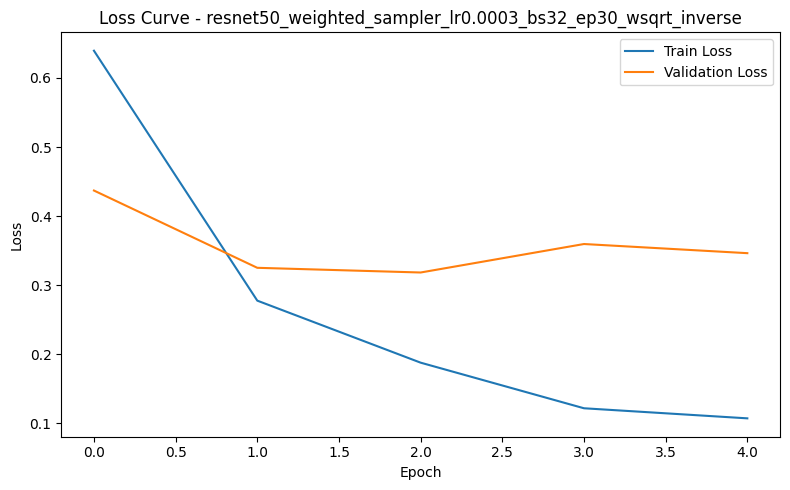

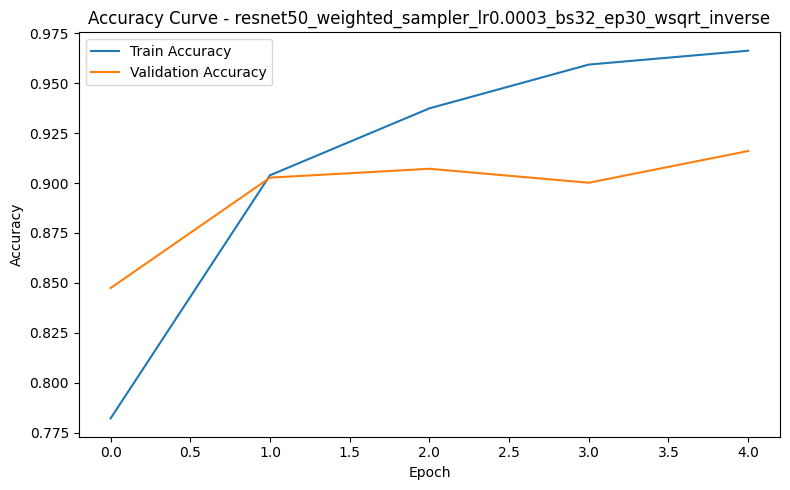


===== Training resnet50 with weighted_sampler =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.7841
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.5646
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.3141
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.9950
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 1.0195
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.5960
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.5756
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.6859
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.5918
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.4934
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.6042
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.3185
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.4550
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.2879
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.5441
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.5306
[Train] resnet50 | Epoch 1 B

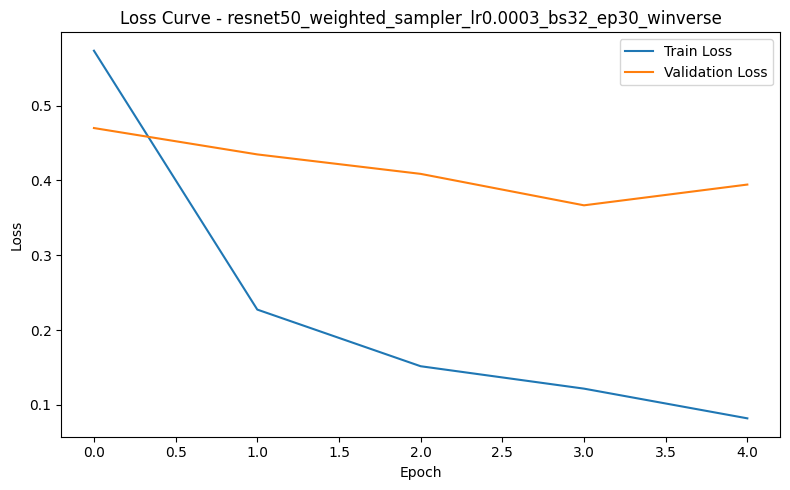

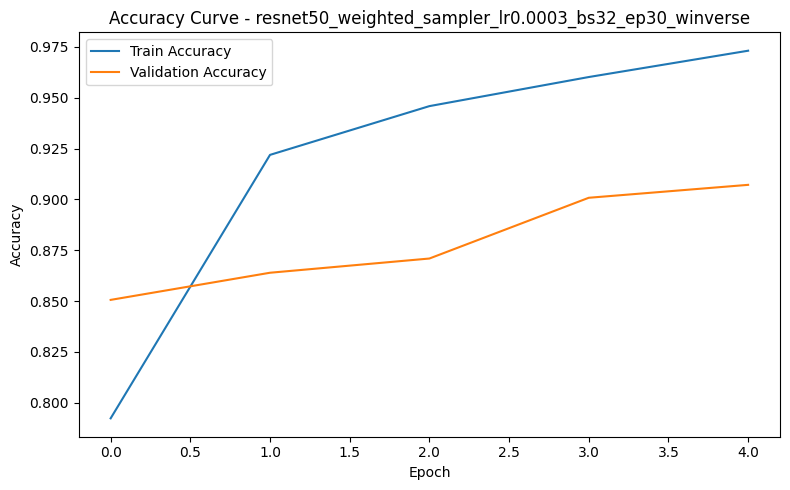


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8372
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.2874
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.4596
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.8796
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.4356
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.8701
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.9175
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.1270
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.9750
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.5165
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.3547
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.7508
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.9803
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.5400
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.6143
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.5591
[Train] resnet50 | Epoch 1 Batc

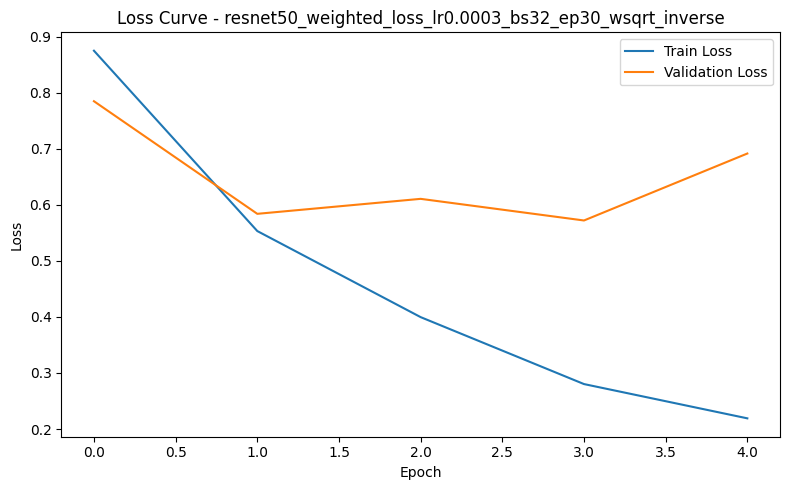

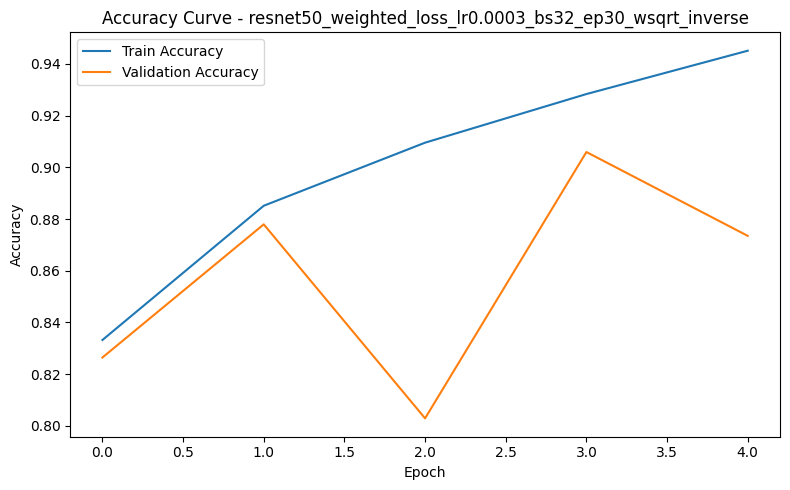


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 2.0978
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.1368
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.1762
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.8446
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.2587
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.3372
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.4872
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 1.2081
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.9742
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5205
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.0262
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.5535
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 1.0257
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.9304
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 1.0054
[Train] resnet50 | Epoch 1 Batc

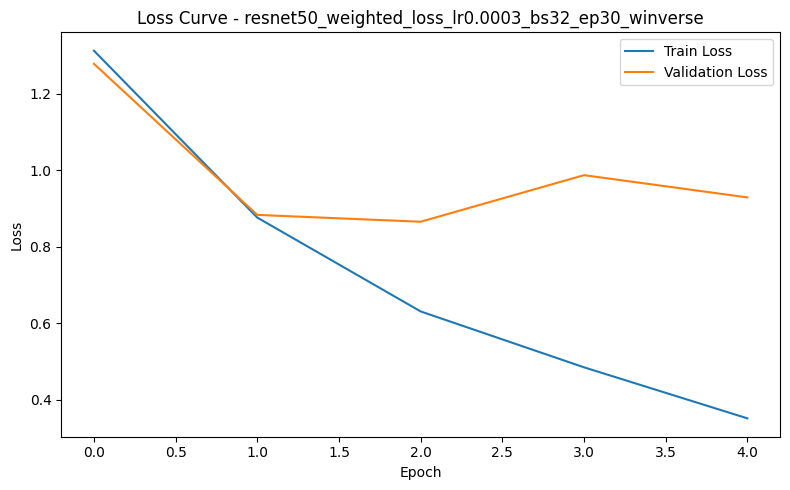

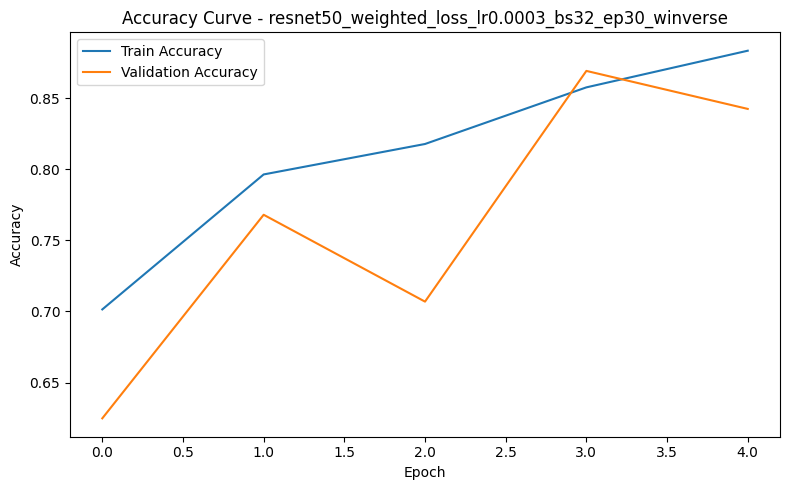


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0020
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0049
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0010
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0022
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0017
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0015
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0028
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0025
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0011
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0033
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 1

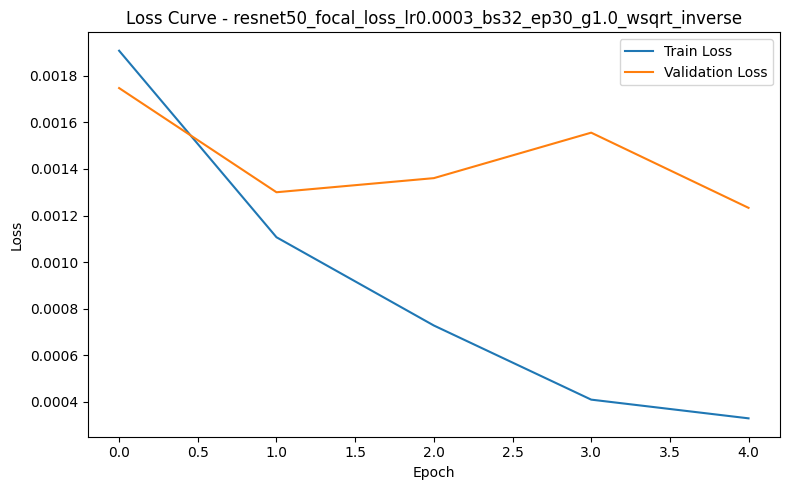

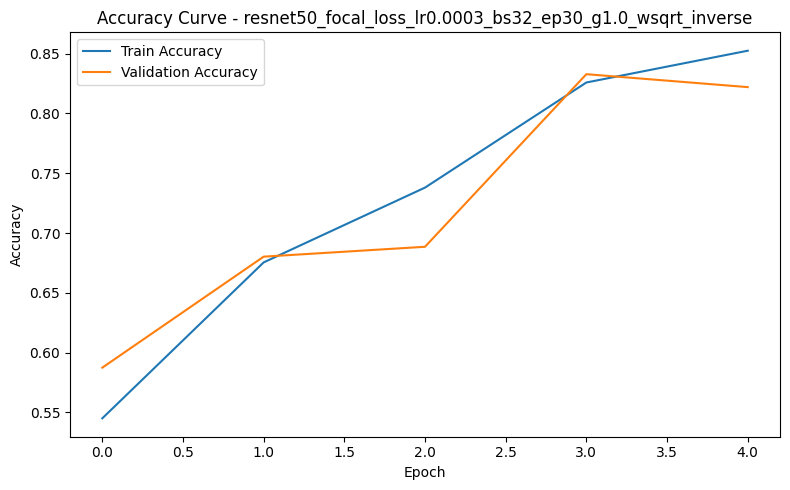


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0001
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 1

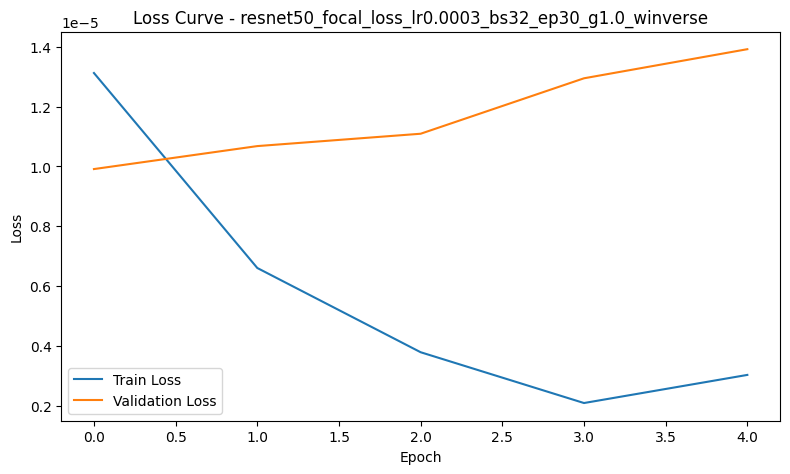

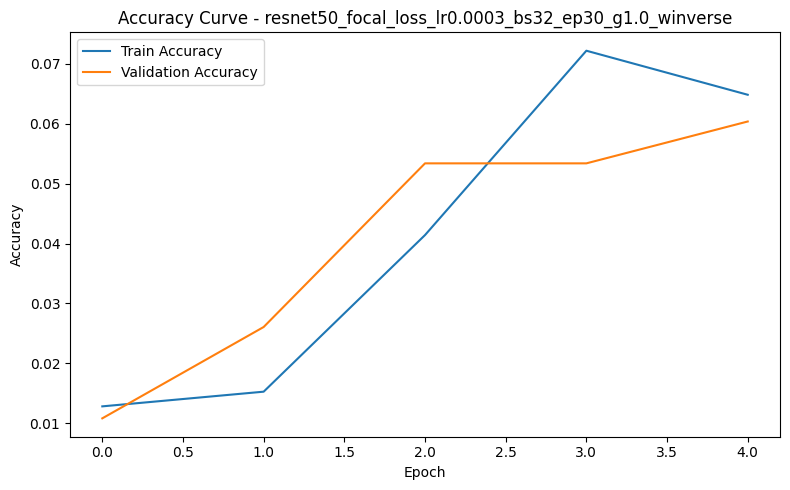


===== Training resnet50 with stratified_weighted_loss =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8122
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.2449
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.8992
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.6375
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.4943
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.4151
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.2387
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.2360
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.2094
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.2002
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.2272
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.1405
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.2523
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.1443
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.2385
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.2046
[Train] resnet50 | E

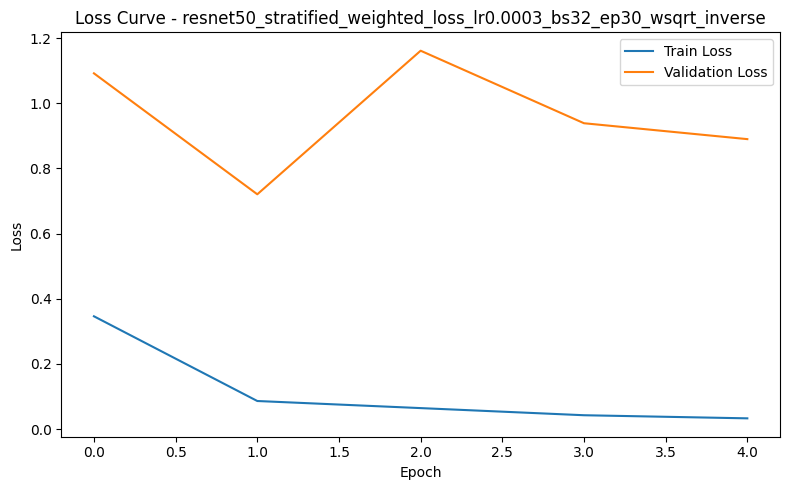

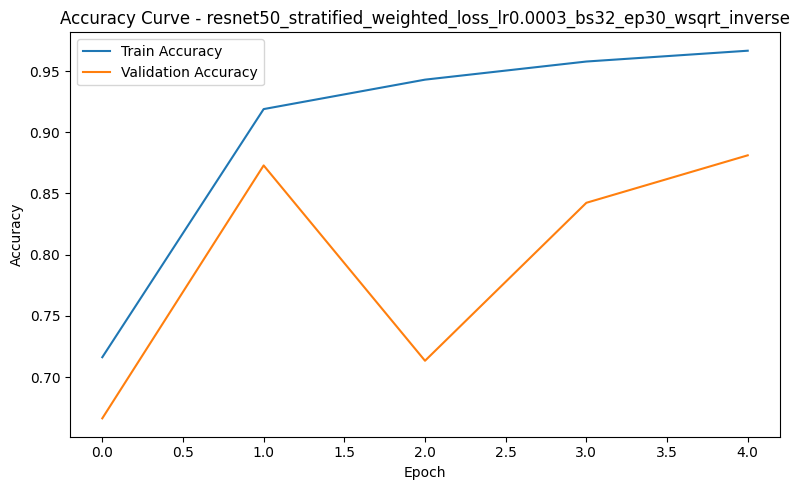


===== Training resnet50 with stratified_weighted_loss =====

===== resnet50 | Epoch 1/5 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8074
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.8075
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.5012
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.3309
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.2516
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.1941
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.1510
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.1657
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.1344
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.1091
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.1100
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0877
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.1723
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.1044
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0962
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0848
[Train] resnet50 | E

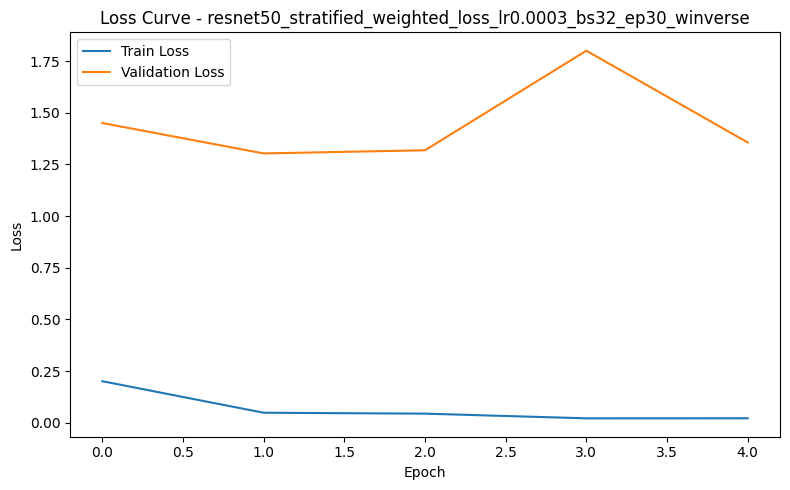

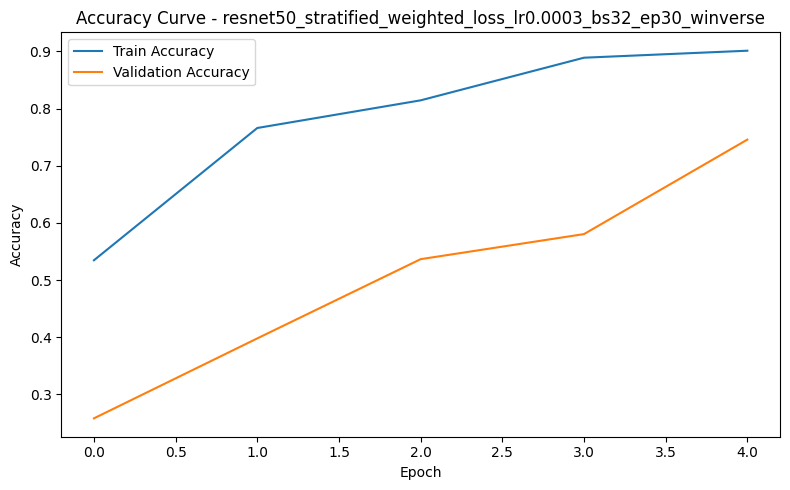

Top 3 methods from screening:
      model         method weight_formula  best_val_balanced_acc  best_val_acc
4  resnet50     focal_loss   sqrt_inverse               0.665328      0.832804
3  resnet50  weighted_loss        inverse               0.651547      0.869040
2  resnet50  weighted_loss   sqrt_inverse               0.644322      0.905912
Configs going to Phase 2:
{'method': 'focal_loss', 'weight_formula': 'sqrt_inverse'}
{'method': 'weighted_loss', 'weight_formula': 'inverse'}
{'method': 'focal_loss', 'weight_formula': 'inverse'}
{'method': 'stratified_weighted_loss', 'weight_formula': 'sqrt_inverse'}


In [17]:
# =============================================
# PHASE 1 — SCREENING (5 epochs, fixed LR)
# =============================================

SCREEN_EPOCHS = 5
SCREEN_LR = 3e-4  # fixed for fair comparison, just for screening

models_list = ["resnet50"]

methods_list = [
    "weighted_sampler",
    "weighted_loss",
    "focal_loss",
    "stratified_weighted_loss",
]

weight_formula_list = ["sqrt_inverse", "inverse"]
batch_size_list = [32]
gamma_list = [1.0] #only for focal loss methods

screen_results = []

for model_name in models_list:
    for method_name in methods_list:
        for batch_size in batch_size_list:

            if method_name in ["focal_loss"]:
                gammas_to_try = gamma_list
            else:
                gammas_to_try = [None]

            formulas_to_try = weight_formula_list

            for gamma in gammas_to_try:
                for formula_name in formulas_to_try:
                    class_weights = get_class_weights(formula_name)
                    class_weights_tensor = torch.tensor(
                        class_weights.values, dtype=torch.float32).to(device)

                    result = run_experiment(
                        model_name=model_name,
                        method_name=method_name,
                        class_weights=class_weights,
                        class_weights_tensor=class_weights_tensor,
                        lr=SCREEN_LR,
                        batch_size=batch_size,
                        gamma=gamma if gamma is not None else 1.0,
                        weight_formula_name=formula_name,
                        num_epochs=SCREEN_EPOCHS   # ← override epochs
                    )

                    result["lr"] = SCREEN_LR
                    result["batch_size"] = batch_size
                    result["gamma"] = gamma if gamma is not None else 1.0
                    result["weight_formula"] = formula_name
                    screen_results.append(result)

# Pick top 3 by validation balanced accuracy
screen_df = pd.DataFrame(screen_results)
top3 = screen_df.sort_values("best_val_balanced_acc", ascending=False).head(3)

print("Top 3 methods from screening:")
print(top3[["model", "method", "weight_formula", "best_val_balanced_acc", "best_val_acc"]])


#focal_loss in screening (epoch = 5) will be weak due to low epoch
#so forcing focal_loss into Phase 2 (epoch = 30) regardless of Phase 1 screening result
top2_configs = top3[["method", "weight_formula"]].to_dict("records")[:2]

forced_configs = [
    {"method": "focal_loss", "weight_formula": "sqrt_inverse"},
    {"method": "focal_loss", "weight_formula": "inverse"},
    {"method": "stratified_weighted_loss", "weight_formula": "sqrt_inverse"},
]

# merge, removing duplicates if focal_loss already in top2
top3_configs = top2_configs + [c for c in forced_configs if c not in top2_configs]

print("Configs going to Phase 2:")
for c in top3_configs:
    print(c)


#save phase 1 results
pd.DataFrame(screen_results).to_csv(output_dir / "phase1_screen_results.csv", index=False)


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0020
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0053
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0010
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0027
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0017
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0015
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0032
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0044
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0014
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0034
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 

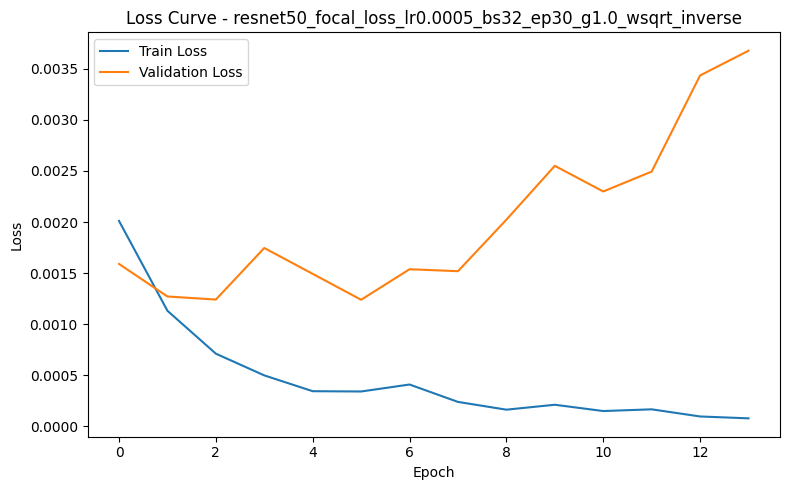

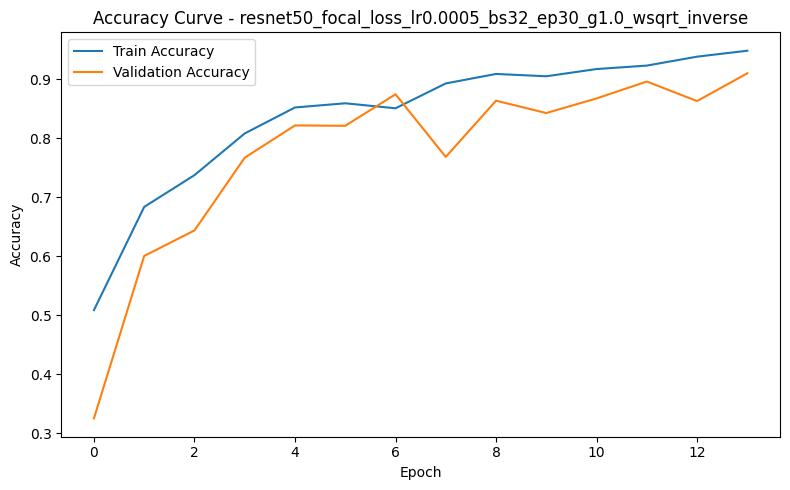


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0020
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0049
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0010
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0022
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0018
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0015
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0027
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0024
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0011
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0032
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 

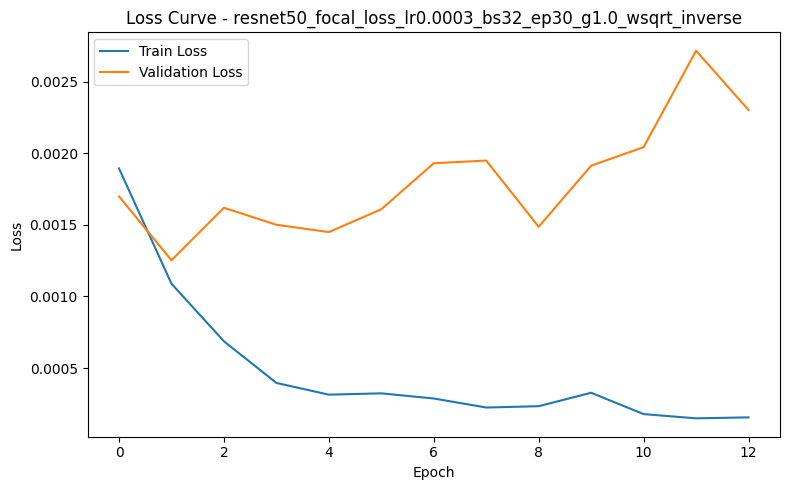

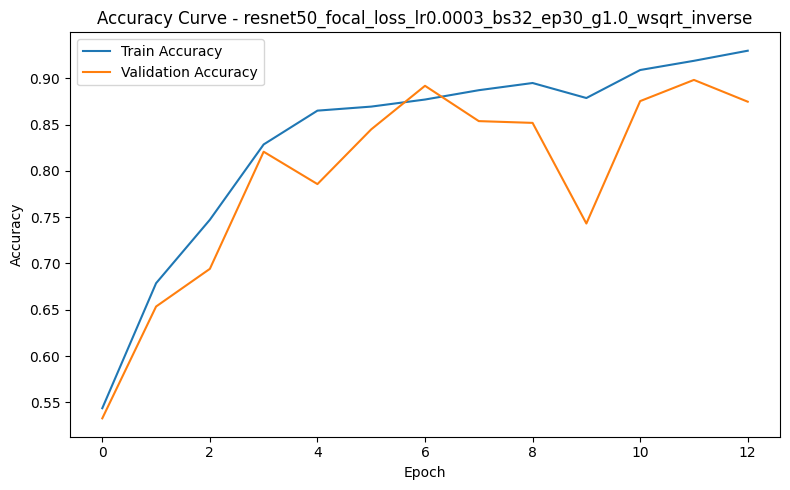


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0020
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0043
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0011
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0027
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0019
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0013
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0039
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0028
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0016
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0035
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 

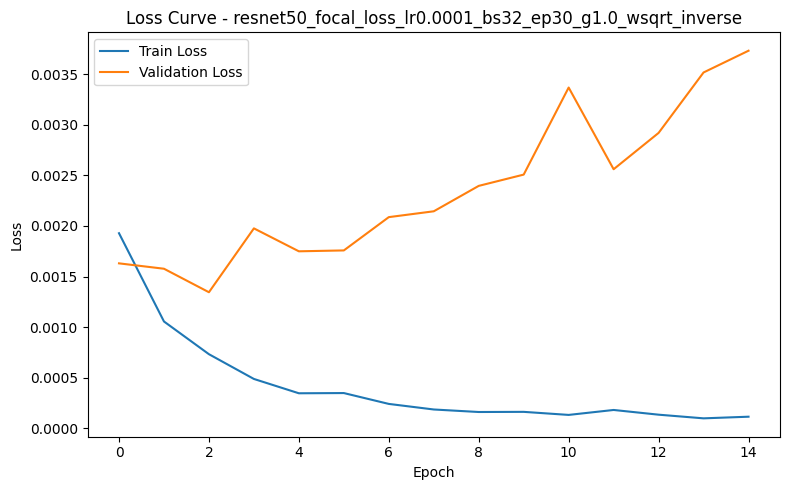

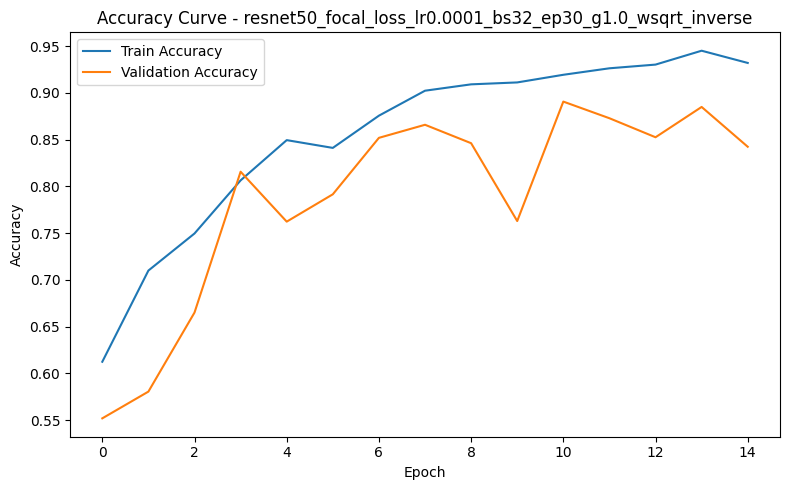


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 2.2180
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.9985
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.2730
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.8905
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.2385
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.8138
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.5240
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 1.0422
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.8615
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5694
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.1312
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.5914
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.9029
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 1.0850
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 1.0439
[Train] resnet50 | Epoch 1 Bat

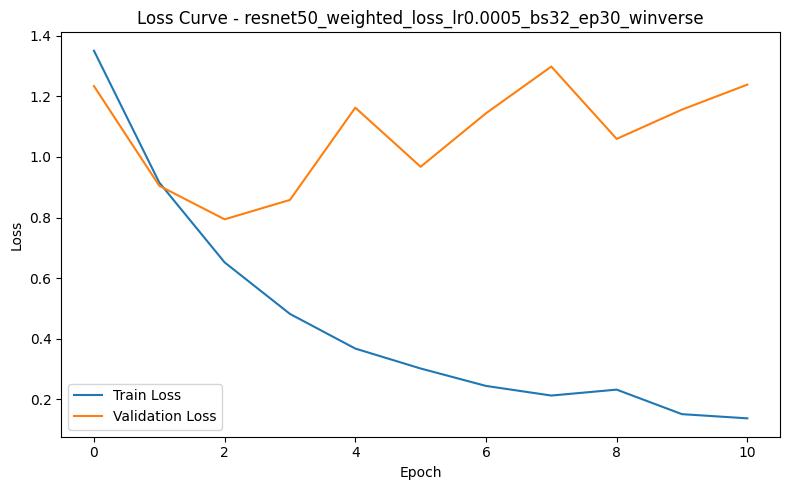

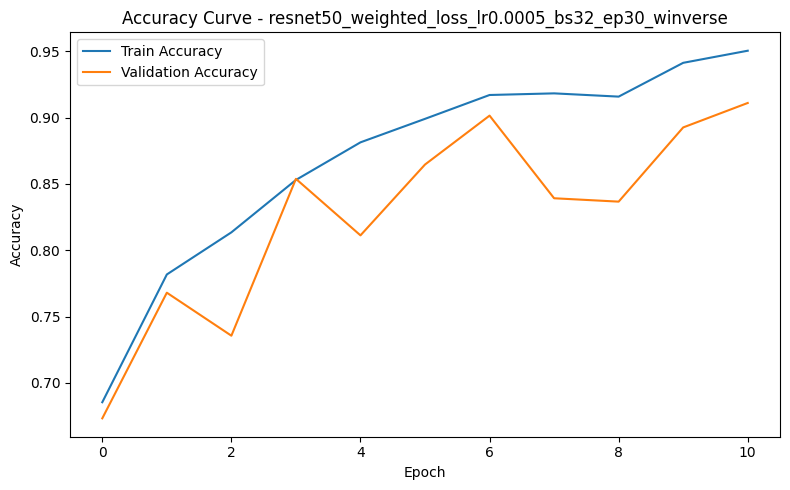


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 2.0983
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.1380
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.1768
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.8422
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.2673
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.3370
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.4831
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 1.1899
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.9685
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5311
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.0610
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.5449
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 1.0338
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.9654
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.9900
[Train] resnet50 | Epoch 1 Bat

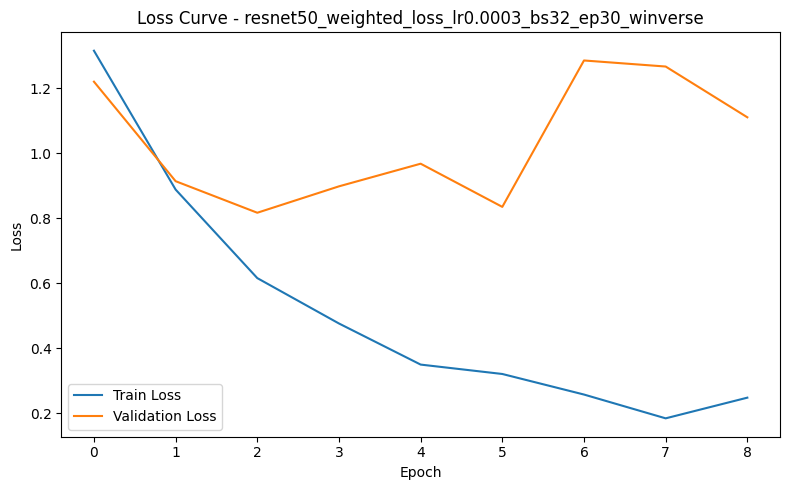

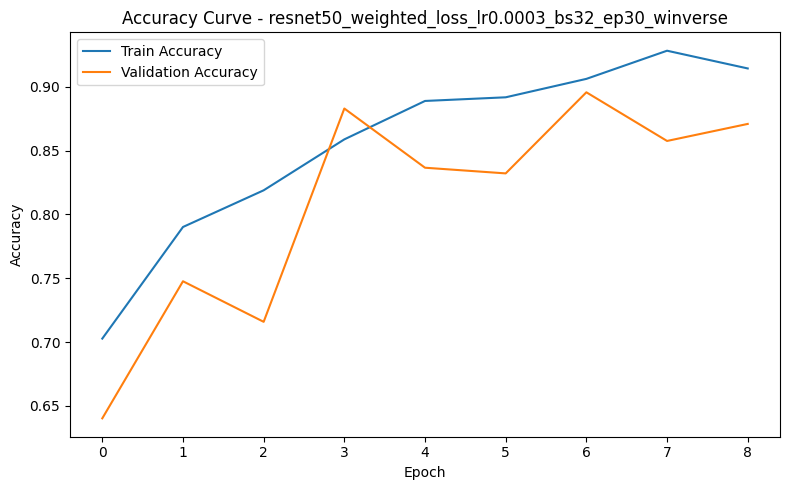


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.9513
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.5146
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.4399
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 1.2700
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.8305
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.4934
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.4486
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 1.7735
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 1.0319
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5914
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.1961
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.6865
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.9508
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.8906
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 1.0583
[Train] resnet50 | Epoch 1 Bat

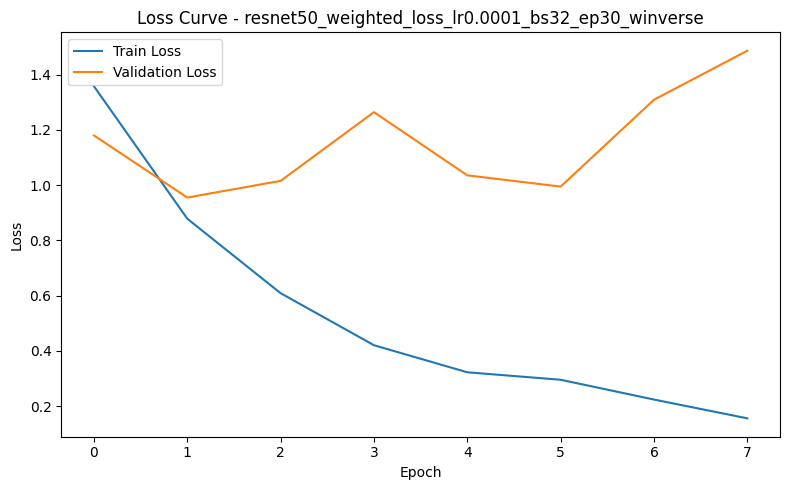

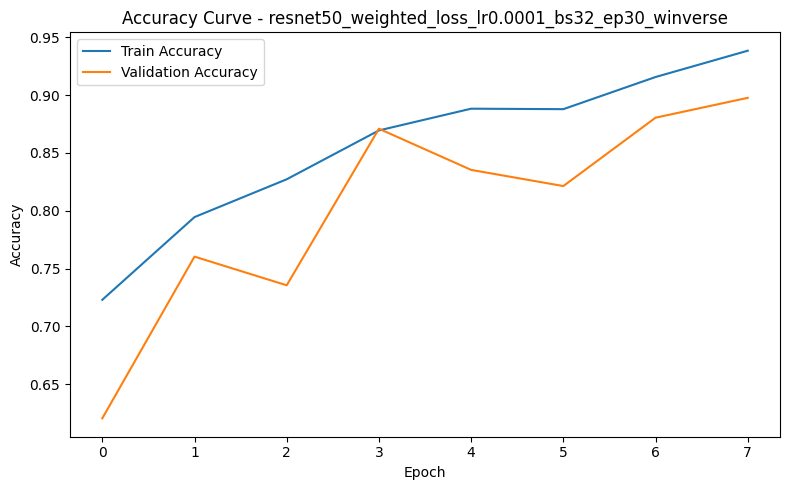


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0001
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 

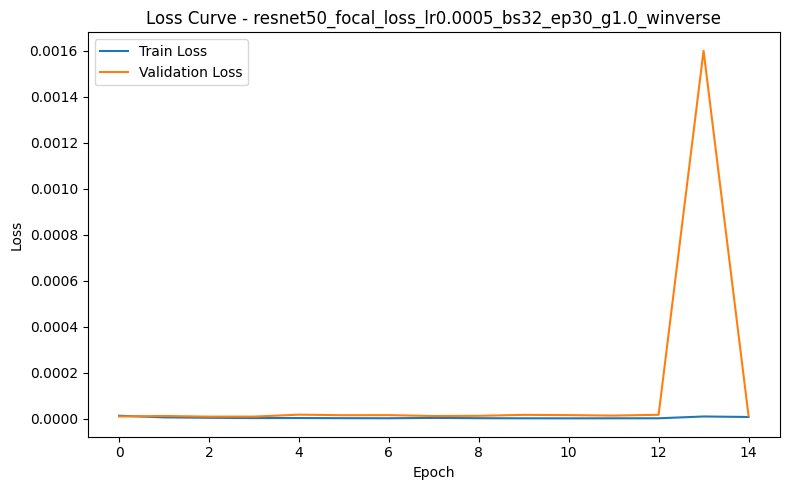

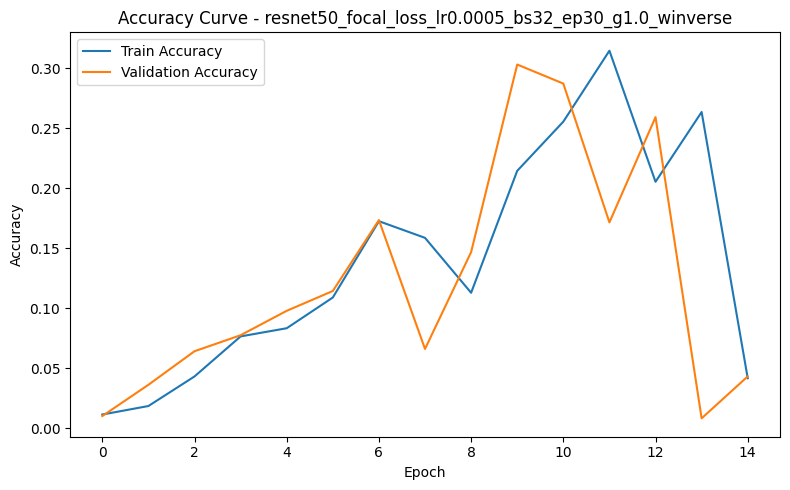


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0001
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 

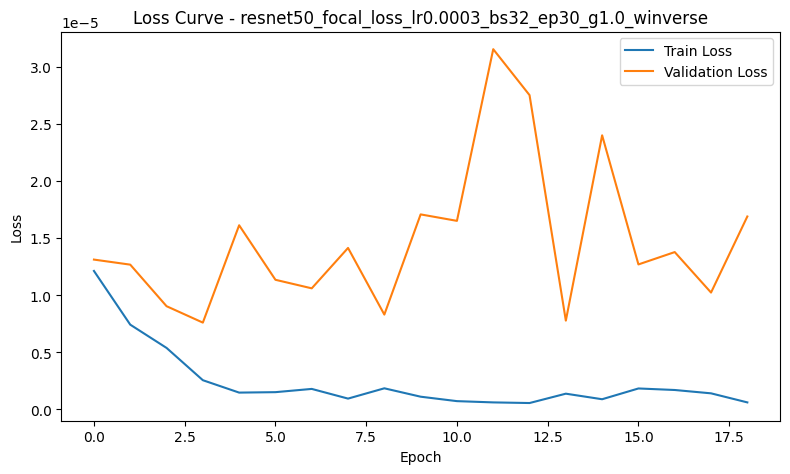

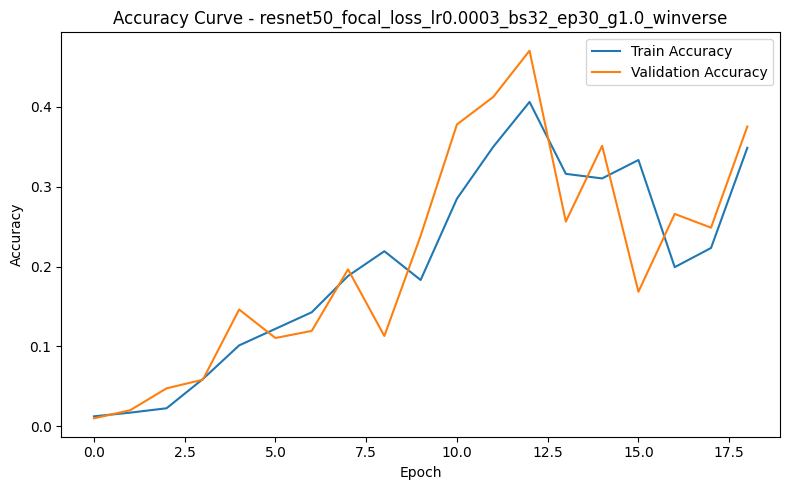


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0001
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0000
[Train] resnet50 | Epoch 1 Batch 

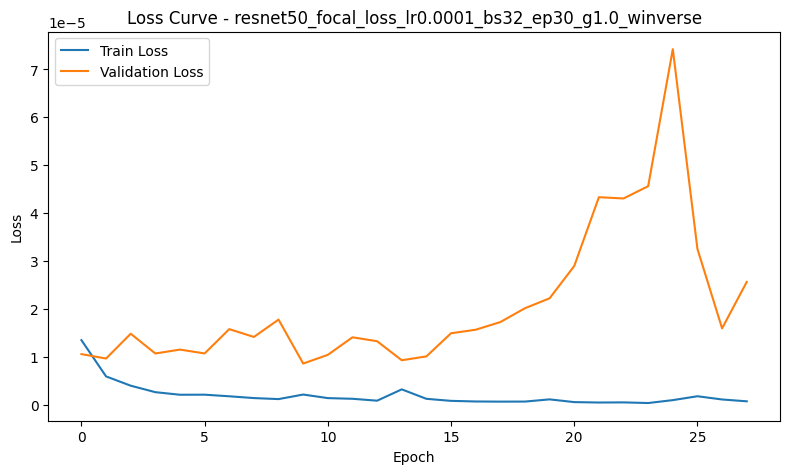

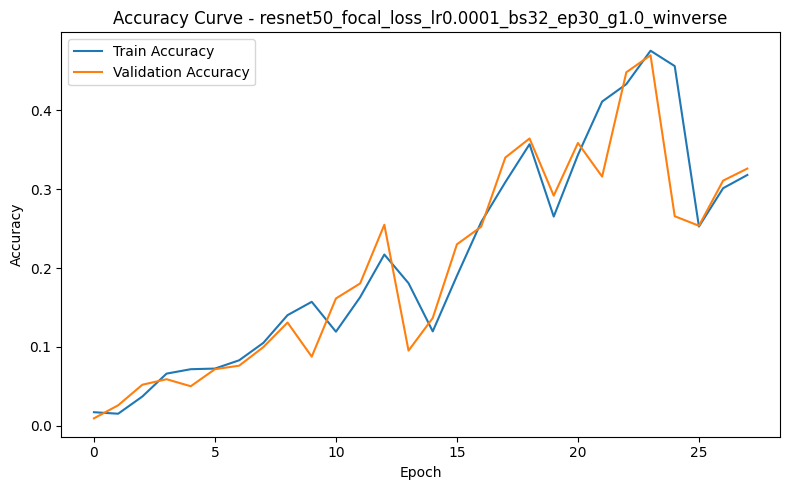


===== Training resnet50 with stratified_weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8122
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.1309
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.7346
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.5456
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.4747
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.3759
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.2546
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.2791
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.3984
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.2905
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.1734
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.1507
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.1914
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.2432
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.3034
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.2645
[Train] resnet50 | 

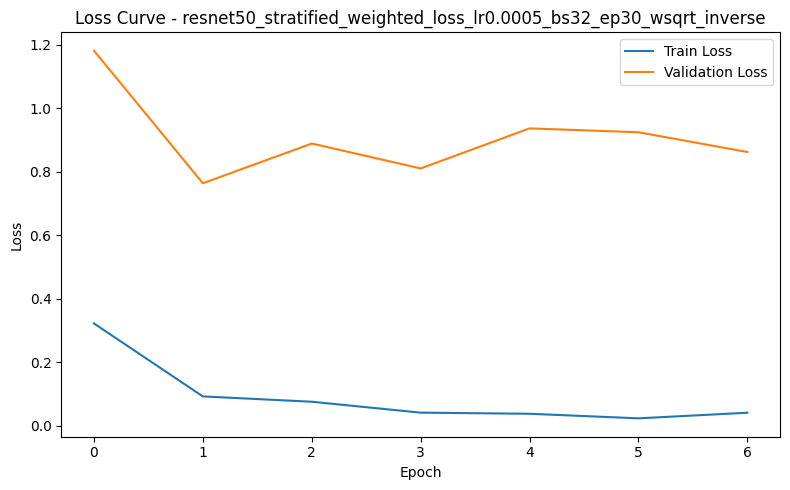

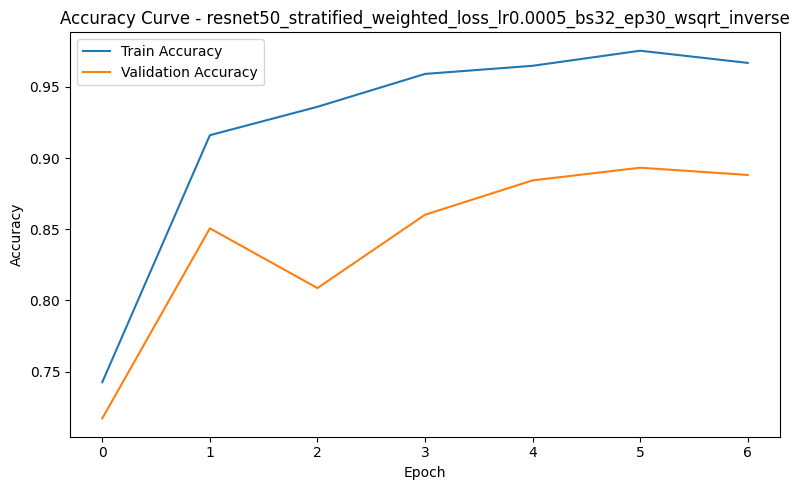


===== Training resnet50 with stratified_weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8122
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.2449
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.8994
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.6412
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.4966
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.4219
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.2410
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.2337
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.2057
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.2030
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.2114
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.1366
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.2070
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.1705
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.2562
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.1993
[Train] resnet50 | 

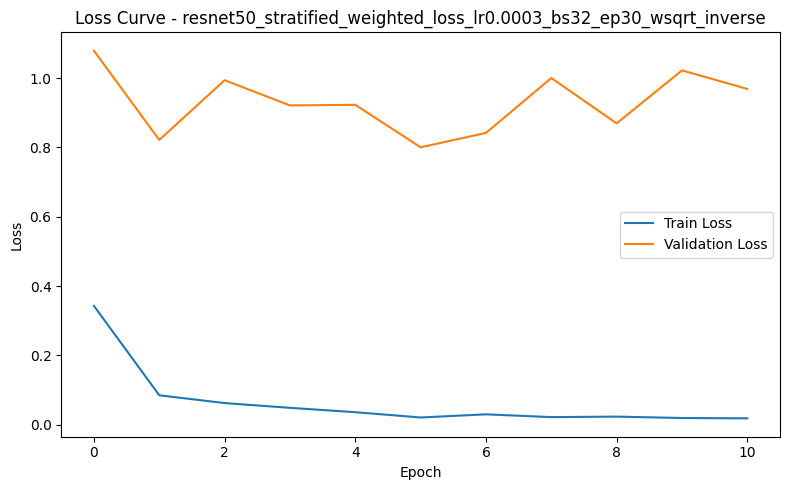

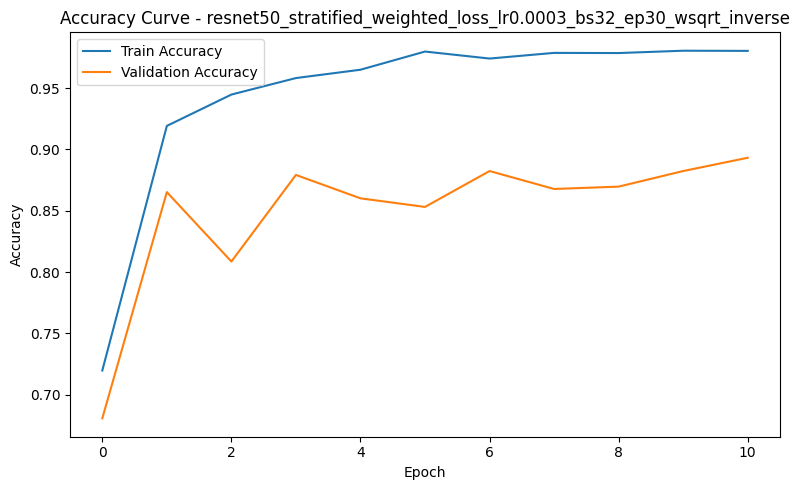


===== Training resnet50 with stratified_weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8122
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.5531
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.2463
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.0053
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.8884
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.7480
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.5609
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.6202
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.5251
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.4668
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.4288
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.3778
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.3540
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.3237
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.3822
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.2670
[Train] resnet50 | 

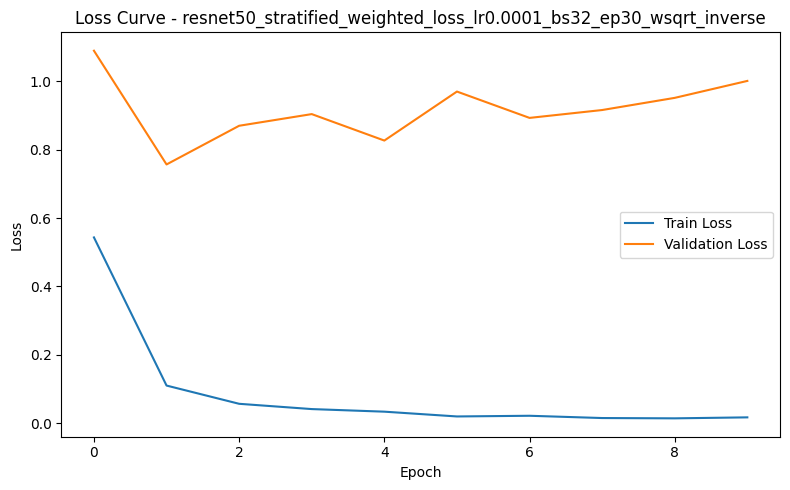

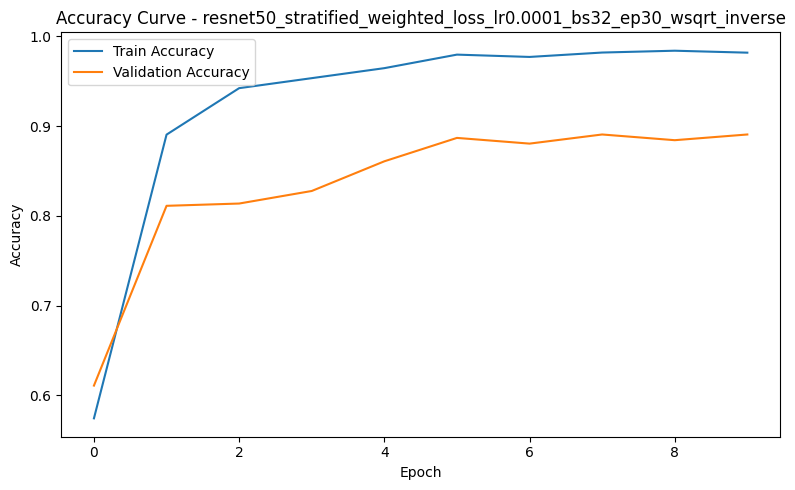

In [18]:
# =============================================
# PHASE 2 — FULL TRAINING (30 epochs, tune LR)
# =============================================

best_overall_acc = 0
best_overall_balanced_acc = 0
best_model_state = None
best_run_name = None

trained_models = {}

lr_list = [5e-4, 3e-4, 1e-4]   # tune LR on best methods only
all_results = []

for config in top3_configs:
    method_name  = config["method"]
    formula_name = config["weight_formula"]

    for lr in lr_list:
        class_weights = get_class_weights(formula_name)
        class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

        gamma = 1.0 if method_name == "focal_loss" else 1.0

        result = run_experiment(
            model_name="resnet50",
            method_name=method_name,
            class_weights=class_weights,
            class_weights_tensor=class_weights_tensor,
            lr=lr,
            batch_size=32,
            gamma=gamma,
            weight_formula_name=formula_name,
            num_epochs=NUM_EPOCHS   # 30
        )

        result["lr"] = lr
        result["batch_size"] = 32
        result["gamma"] = gamma
        result["weight_formula"] = formula_name
        all_results.append(result)

        key = f"resnet50_{method_name}_lr{lr}_bs32_g{gamma}_w{formula_name}"
        trained_models[key] = result["model_obj"]

        if result["best_val_balanced_acc"] > best_overall_balanced_acc:
            best_overall_balanced_acc = result["best_val_balanced_acc"]
            best_overall_acc = result["best_val_acc"]
            best_model_state = copy.deepcopy(result["model_obj"].state_dict())
            best_run_name = f"resnet50_{method_name}_lr{lr}_bs32_ep{NUM_EPOCHS}_g{gamma}_w{formula_name}"

In [19]:
results_df = pd.DataFrame(all_results)

top3_results = results_df.sort_values("best_val_balanced_acc", ascending=False).head(3)

for rank, (_, row) in enumerate(top3_results.iterrows(), start=1):
    model_obj = row["model_obj"]
    
    save_path = output_dir / f"TOP{rank}_{row['method']}_w{row['weight_formula']}_lr{row['lr']}.pth"
    torch.save({
        "model_state_dict": model_obj.state_dict(),
        "model_name": "resnet50",
        "num_classes": num_classes,
        "run_name": f"resnet50_{row['method']}_w{row['weight_formula']}_lr{row['lr']}",
        "rank": rank,
        "best_val_balanced_acc": row["best_val_balanced_acc"],
        "best_val_acc": row["best_val_acc"],
    }, save_path)
    
    print(f"Saved Rank {rank}: {save_path}")

display(results_df[[
    "model",
    "method",
    "lr",
    "batch_size",
    "gamma",
    "weight_formula",
    "best_val_acc",
    "best_val_balanced_acc",
    "final_val_acc"
]])

Saved Rank 1: /kaggle/working/TOP1_weighted_loss_winverse_lr0.0005.pth
Saved Rank 2: /kaggle/working/TOP2_focal_loss_wsqrt_inverse_lr0.0003.pth
Saved Rank 3: /kaggle/working/TOP3_focal_loss_wsqrt_inverse_lr0.0005.pth


,model,method,lr,batch_size,gamma,weight_formula,best_val_acc,best_val_balanced_acc,final_val_acc
0,resnet50,focal_loss,0.0005,32,1.0,sqrt_inverse,0.910362,0.661765,0.910362
1,resnet50,focal_loss,0.0003,32,1.0,sqrt_inverse,0.898284,0.681475,0.874762
2,resnet50,focal_loss,0.0001,32,1.0,sqrt_inverse,0.890655,0.610294,0.842339
3,resnet50,weighted_loss,0.0005,32,1.0,inverse,0.910998,0.685930,0.910998
4,resnet50,weighted_loss,0.0003,32,1.0,inverse,0.895741,0.661377,0.870947
5,resnet50,weighted_loss,0.0001,32,1.0,inverse,0.897648,0.608050,0.897648
6,resnet50,focal_loss,0.0005,32,1.0,inverse,0.303242,0.568394,0.043229
7,resnet50,focal_loss,0.0003,32,1.0,inverse,0.469803,0.594449,0.375079
8,resnet50,focal_loss,0.0001,32,1.0,inverse,0.469803,0.557609,0.326128
9,resnet50,stratified_weighted_loss,0.0005,32,1.0,sqrt_inverse,0.893198,0.631293,0.888112


## validation improvements across all models + methods

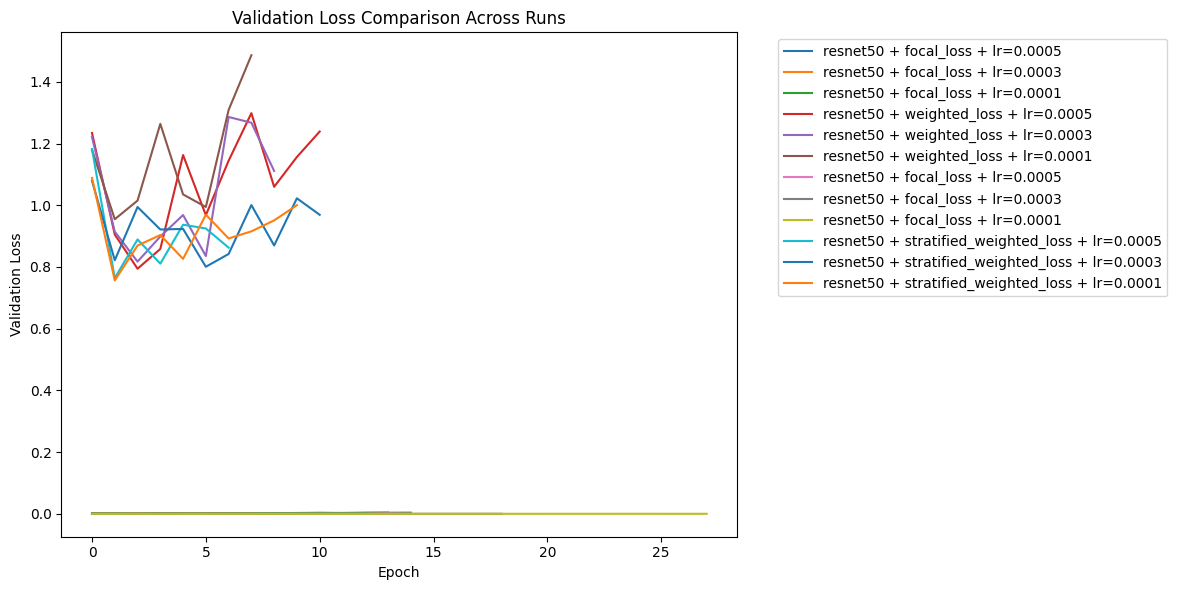

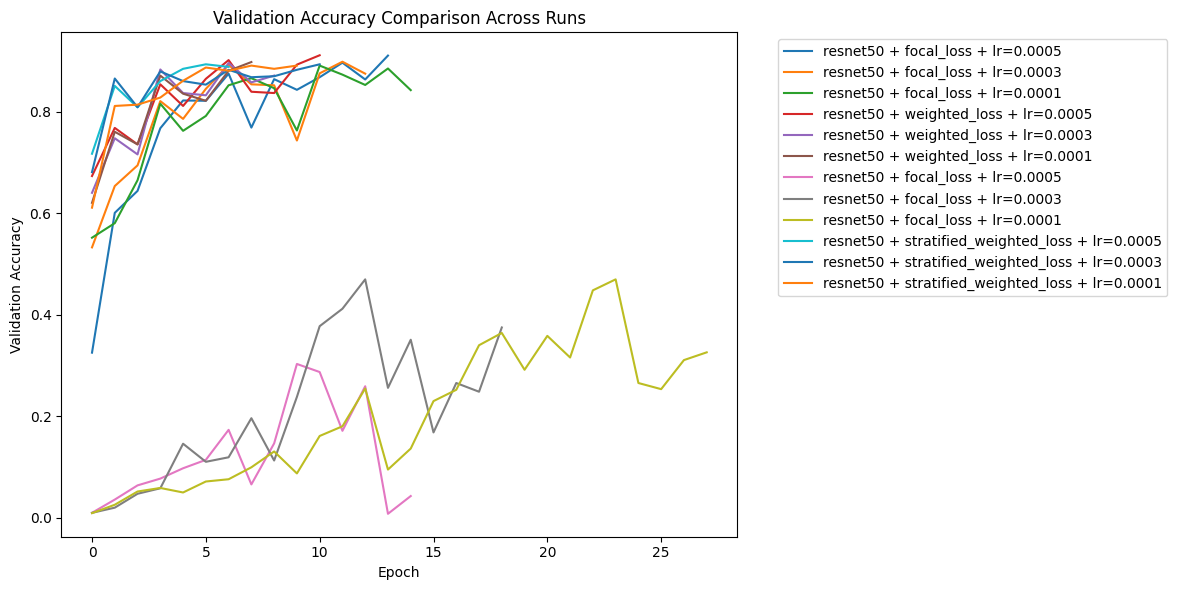

In [20]:
# compare validation loss across all model + method combinations
plt.figure(figsize=(12, 6))

for r in all_results:
    label = f"{r['model']} + {r['method']} + lr={r['lr']}"
    plt.plot(r["val_loss_history"], label=label)

plt.title("Validation Loss Comparison Across Runs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



# compare validation accuracy across all model + method combinations
plt.figure(figsize=(12, 6))

for r in all_results:
    label = f"{r['model']} + {r['method']} + lr={r['lr']}"
    plt.plot(r["val_acc_history"], label=label)

plt.title("Validation Accuracy Comparison Across Runs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## detailed evaluation for train, validation and test

 - confustion matrix
 - per-class metrics
 - ROC-AUC curve

In [21]:
# collect predictions for ALL sets
all_train_results = {}
all_val_results = {}
all_test_results = {}

for name, model in trained_models.items():
    print(f"\nEvaluating {name}...")

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_train_results[name] = evaluate_loader(model, train_loader)
    all_val_results[name]   = evaluate_loader(model, val_loader)
    all_test_results[name]  = evaluate_loader(model, test_loader)


Evaluating resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse...

Evaluating resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse...

Evaluating resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse...

Evaluating resnet50_focal_loss_lr0.0005_bs32_g1.0_winverse...

Evaluating resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse...

Evaluating resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse...

Evaluating resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_stratified_weighted_loss_lr0.0003_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_stratified_weighted_loss_lr0.0001_bs32_g1.0_wsqrt_inverse...



TRAIN Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9789
Balanced Accuracy:  0.9814
Macro Precision:    0.9714
Macro Recall:       0.9814
Macro F1:           0.9763
Weighted F1:        0.9789
ROC-AUC:            0.9996

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.972112,1.000000,0.985859,244
1,albopictus,0.982585,0.984490,0.983537,2579
2,anopheles,0.967359,0.990881,0.978979,329
3,culex,0.994253,0.974256,0.984153,2486
4,culiseta,0.949605,0.985641,0.967287,975
5,japonicus-koreicus,0.962448,0.953168,0.957785,726



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9721    1.0000    0.9859       244
        albopictus     0.9826    0.9845    0.9835      2579
         anopheles     0.9674    0.9909    0.9790       329
             culex     0.9943    0.9743    0.9842      2486
          culiseta     0.9496    0.9856    0.9673       975
japonicus-koreicus     0.9624    0.9532    0.9578       726

          accuracy                         0.9789      7339
         macro avg     0.9714    0.9814    0.9763      7339
      weighted avg     0.9791    0.9789    0.9789      7339



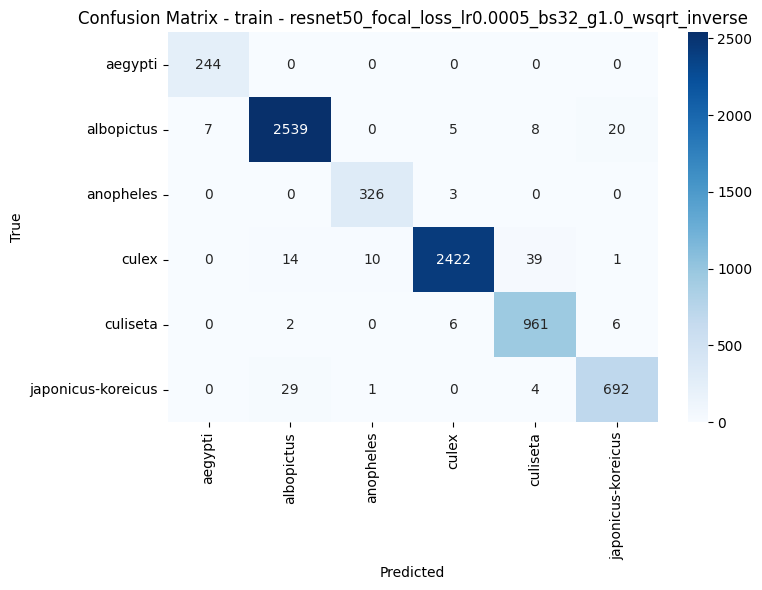


TRAIN Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9308
Balanced Accuracy:  0.9607
Macro Precision:    0.9066
Macro Recall:       0.9607
Macro F1:           0.9274
Weighted F1:        0.9337
ROC-AUC:            0.9983

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.909699,1.000000,0.952715,272
1,albopictus,0.988351,0.868504,0.924560,2540
2,anopheles,0.928571,1.000000,0.962963,312
3,culex,0.986301,0.951923,0.968807,2496
4,culiseta,0.949187,0.949187,0.949187,984
5,japonicus-koreicus,0.677479,0.994558,0.805954,735



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9097    1.0000    0.9527       272
        albopictus     0.9884    0.8685    0.9246      2540
         anopheles     0.9286    1.0000    0.9630       312
             culex     0.9863    0.9519    0.9688      2496
          culiseta     0.9492    0.9492    0.9492       984
japonicus-koreicus     0.6775    0.9946    0.8060       735

          accuracy                         0.9308      7339
         macro avg     0.9066    0.9607    0.9274      7339
      weighted avg     0.9458    0.9308    0.9337      7339



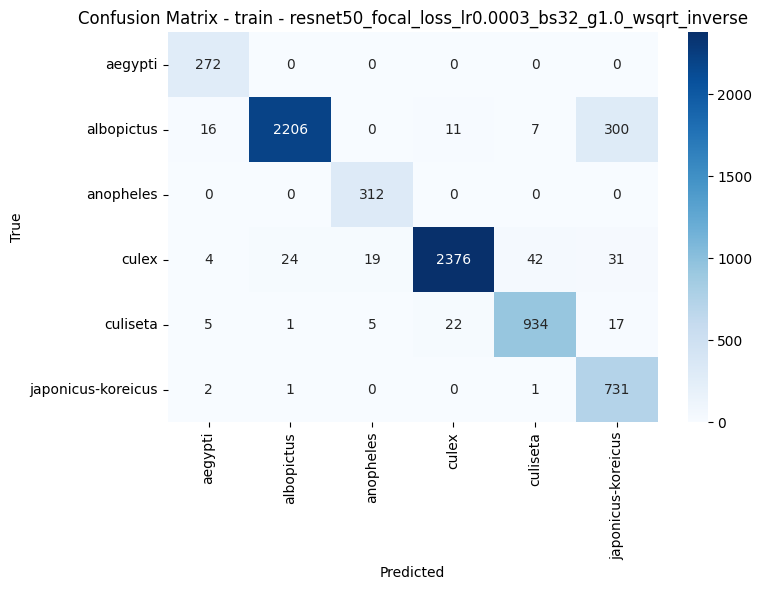


TRAIN Evaluation: resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9497
Balanced Accuracy:  0.9738
Macro Precision:    0.9135
Macro Recall:       0.9738
Macro F1:           0.9399
Weighted F1:        0.9508
ROC-AUC:            0.9991

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.952569,1.000000,0.975709,241
1,albopictus,0.989708,0.930341,0.959106,2584
2,anopheles,0.811881,1.000000,0.896175,328
3,culex,0.992550,0.933437,0.962086,2569
4,culiseta,0.922760,0.983535,0.952179,911
5,japonicus-koreicus,0.811778,0.995751,0.894402,706



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9526    1.0000    0.9757       241
        albopictus     0.9897    0.9303    0.9591      2584
         anopheles     0.8119    1.0000    0.8962       328
             culex     0.9925    0.9334    0.9621      2569
          culiseta     0.9228    0.9835    0.9522       911
japonicus-koreicus     0.8118    0.9958    0.8944       706

          accuracy                         0.9497      7339
         macro avg     0.9135    0.9738    0.9399      7339
      weighted avg     0.9561    0.9497    0.9508      7339



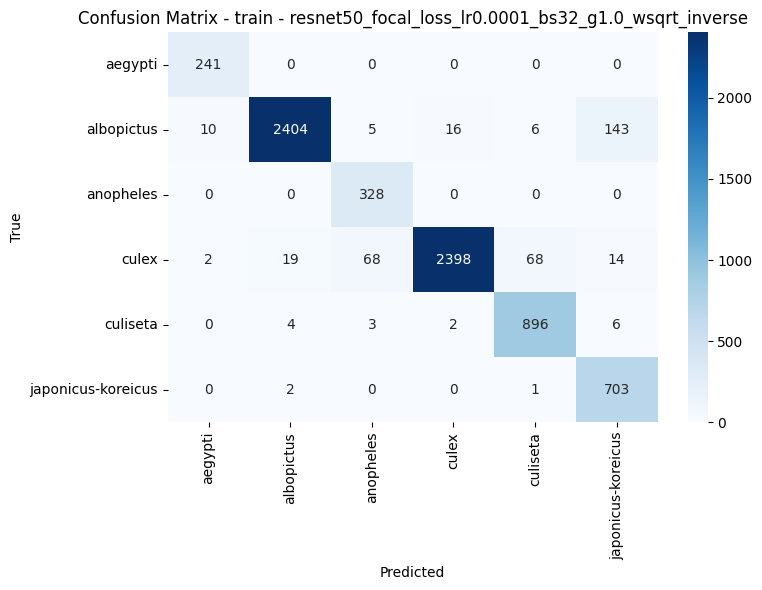


TRAIN Evaluation: resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.9700
Balanced Accuracy:  0.9795
Macro Precision:    0.9570
Macro Recall:       0.9795
Macro F1:           0.9678
Weighted F1:        0.9701
ROC-AUC:            0.9992

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.979839,0.995902,0.987805,244
1,albopictus,0.985075,0.961165,0.972973,2472
2,anopheles,0.918478,1.000000,0.957507,338
3,culex,0.985629,0.967098,0.976275,2553
4,culiseta,0.948980,0.988310,0.968246,941
5,japonicus-koreicus,0.923729,0.964602,0.943723,791



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9798    0.9959    0.9878       244
        albopictus     0.9851    0.9612    0.9730      2472
         anopheles     0.9185    1.0000    0.9575       338
             culex     0.9856    0.9671    0.9763      2553
          culiseta     0.9490    0.9883    0.9682       941
japonicus-koreicus     0.9237    0.9646    0.9437       791

          accuracy                         0.9700      7339
         macro avg     0.9570    0.9795    0.9678      7339
      weighted avg     0.9708    0.9700    0.9701      7339



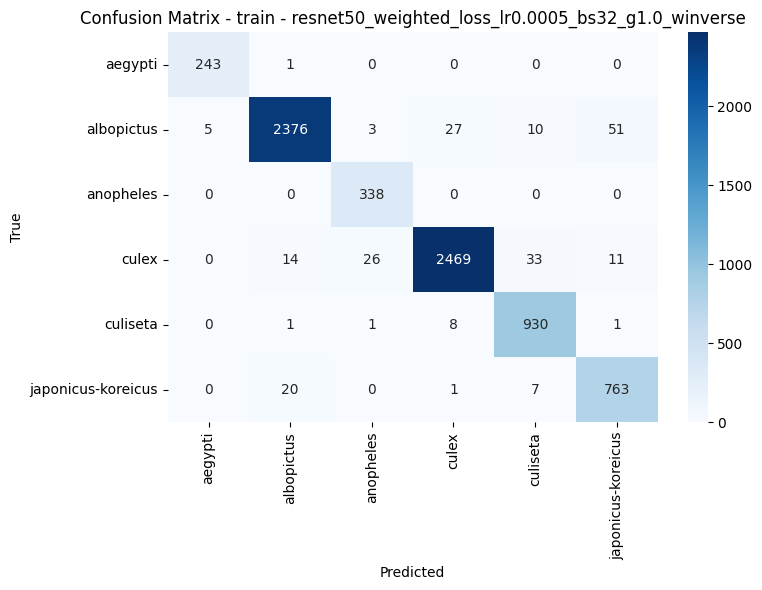


TRAIN Evaluation: resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.9381
Balanced Accuracy:  0.9662
Macro Precision:    0.9075
Macro Recall:       0.9662
Macro F1:           0.9322
Weighted F1:        0.9398
ROC-AUC:            0.9985

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.946429,1.000000,0.972477,265
1,albopictus,0.994170,0.892153,0.940403,2485
2,anopheles,0.860849,0.997268,0.924051,366
3,culex,0.988139,0.938982,0.962933,2573
4,culiseta,0.906027,0.971522,0.937632,913
5,japonicus-koreicus,0.749235,0.997286,0.855646,737



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9464    1.0000    0.9725       265
        albopictus     0.9942    0.8922    0.9404      2485
         anopheles     0.8608    0.9973    0.9241       366
             culex     0.9881    0.9390    0.9629      2573
          culiseta     0.9060    0.9715    0.9376       913
japonicus-koreicus     0.7492    0.9973    0.8556       737

          accuracy                         0.9381      7339
         macro avg     0.9075    0.9662    0.9322      7339
      weighted avg     0.9481    0.9381    0.9398      7339



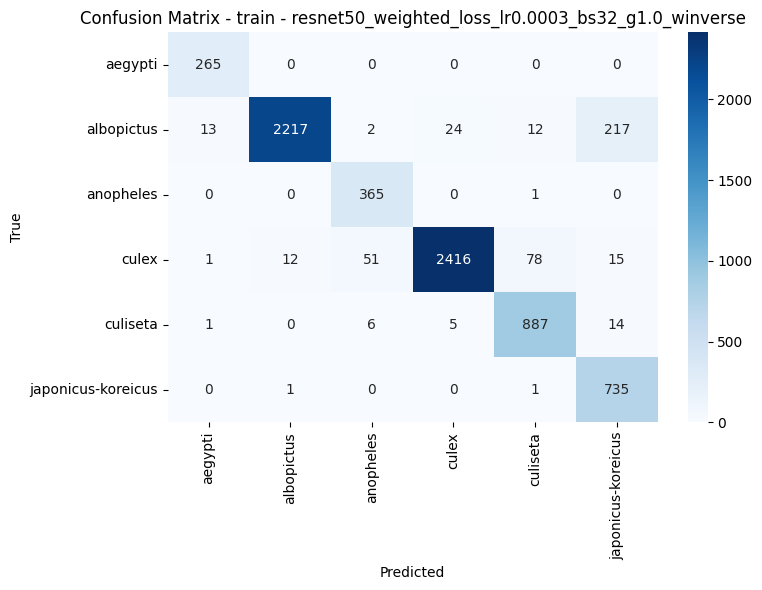


TRAIN Evaluation: resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.9598
Balanced Accuracy:  0.9722
Macro Precision:    0.9481
Macro Recall:       0.9722
Macro F1:           0.9594
Weighted F1:        0.9601
ROC-AUC:            0.9985

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.947761,1.000000,0.973180,254
1,albopictus,0.971308,0.947715,0.959367,2429
2,anopheles,0.979412,0.985207,0.982301,338
3,culex,0.990040,0.955035,0.972222,2602
4,culiseta,0.926368,0.978970,0.951943,951
5,japonicus-koreicus,0.873522,0.966013,0.917443,765



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9478    1.0000    0.9732       254
        albopictus     0.9713    0.9477    0.9594      2429
         anopheles     0.9794    0.9852    0.9823       338
             culex     0.9900    0.9550    0.9722      2602
          culiseta     0.9264    0.9790    0.9519       951
japonicus-koreicus     0.8735    0.9660    0.9174       765

          accuracy                         0.9598      7339
         macro avg     0.9481    0.9722    0.9594      7339
      weighted avg     0.9615    0.9598    0.9601      7339



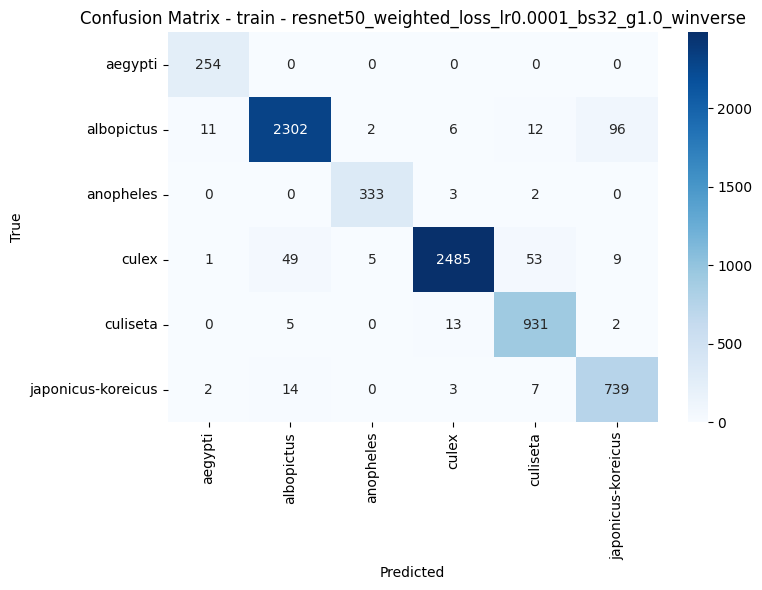


TRAIN Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.1548
Balanced Accuracy:  0.4312
Macro Precision:    0.1879
Macro Recall:       0.4312
Macro F1:           0.2009
Weighted F1:        0.1062
ROC-AUC:            0.8684

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.055382,1.000000,0.104951,248
1,albopictus,0.000000,0.000000,0.000000,2577
2,anopheles,0.203125,0.893983,0.331034,349
3,culex,0.000000,0.000000,0.000000,2514
4,culiseta,0.436767,0.377252,0.404834,888
5,japonicus-koreicus,0.431900,0.315858,0.364875,763



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0554    1.0000    0.1050       248
        albopictus     0.0000    0.0000    0.0000      2577
         anopheles     0.2031    0.8940    0.3310       349
             culex     0.0000    0.0000    0.0000      2514
          culiseta     0.4368    0.3773    0.4048       888
japonicus-koreicus     0.4319    0.3159    0.3649       763

          accuracy                         0.1548      7339
         macro avg     0.1879    0.4312    0.2009      7339
      weighted avg     0.1093    0.1548    0.1062      7339



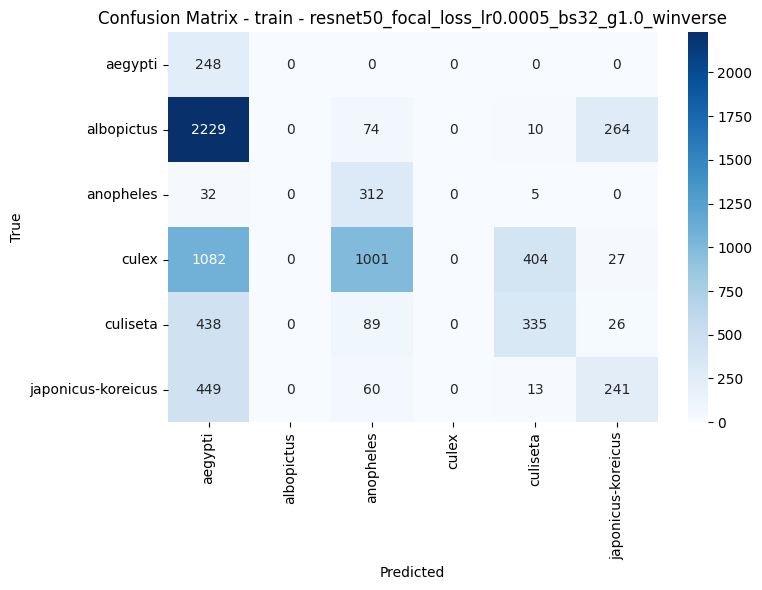


TRAIN Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.5299
Balanced Accuracy:  0.7644
Macro Precision:    0.5930
Macro Recall:       0.7644
Macro F1:           0.5309
Weighted F1:        0.5090
ROC-AUC:            0.9789

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.334601,1.000000,0.501425,264
1,albopictus,0.984979,0.179017,0.302970,2564
2,anopheles,0.388221,1.000000,0.559307,323
3,culex,0.991221,0.494230,0.659586,2513
4,culiseta,0.554977,0.945676,0.699467,902
5,japonicus-koreicus,0.303818,0.967658,0.462442,773



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3346    1.0000    0.5014       264
        albopictus     0.9850    0.1790    0.3030      2564
         anopheles     0.3882    1.0000    0.5593       323
             culex     0.9912    0.4942    0.6596      2513
          culiseta     0.5550    0.9457    0.6995       902
japonicus-koreicus     0.3038    0.9677    0.4624       773

          accuracy                         0.5299      7339
         macro avg     0.5930    0.7644    0.5309      7339
      weighted avg     0.8129    0.5299    0.5090      7339



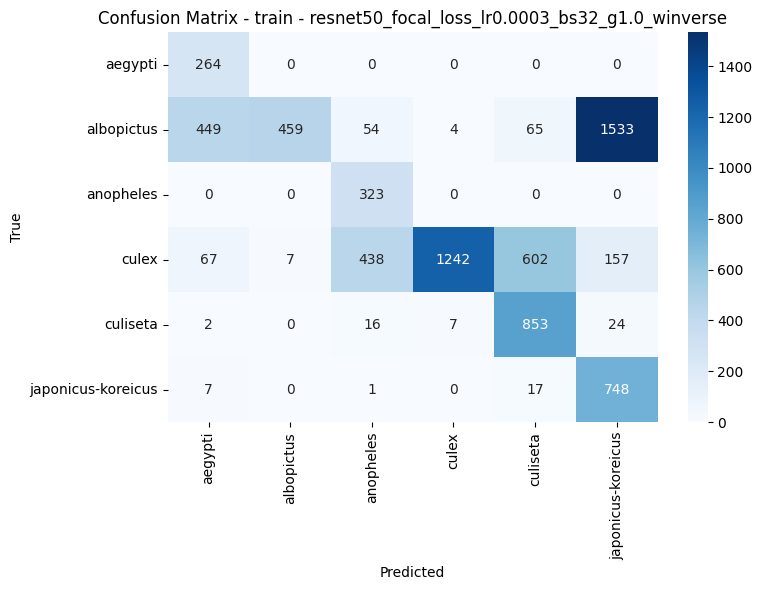


TRAIN Evaluation: resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.4904
Balanced Accuracy:  0.7367
Macro Precision:    0.5737
Macro Recall:       0.7367
Macro F1:           0.4998
Weighted F1:        0.4671
ROC-AUC:            0.9655

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.334221,1.000000,0.500998,251
1,albopictus,0.975926,0.208961,0.344219,2522
2,anopheles,0.379610,1.000000,0.550314,350
3,culex,0.978190,0.356377,0.522423,2517
4,culiseta,0.468254,0.911700,0.618727,906
5,japonicus-koreicus,0.305930,0.943253,0.462014,793



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3342    1.0000    0.5010       251
        albopictus     0.9759    0.2090    0.3442      2522
         anopheles     0.3796    1.0000    0.5503       350
             culex     0.9782    0.3564    0.5224      2517
          culiseta     0.4683    0.9117    0.6187       906
japonicus-koreicus     0.3059    0.9433    0.4620       793

          accuracy                         0.4904      7339
         macro avg     0.5737    0.7367    0.4998      7339
      weighted avg     0.7912    0.4904    0.4671      7339



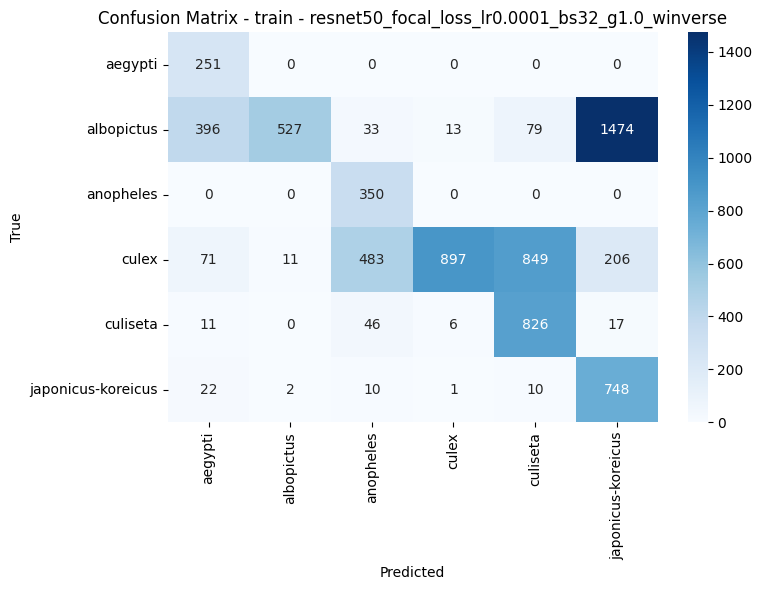


TRAIN Evaluation: resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9486
Balanced Accuracy:  0.9729
Macro Precision:    0.9231
Macro Recall:       0.9729
Macro F1:           0.9453
Weighted F1:        0.9492
ROC-AUC:            0.9983

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.977444,1.000000,0.988593,260
1,albopictus,0.983221,0.935729,0.958887,2505
2,anopheles,0.847938,0.996970,0.916435,330
3,culex,0.990291,0.920722,0.954240,2548
4,culiseta,0.881750,0.994748,0.934847,952
5,japonicus-koreicus,0.857809,0.989247,0.918851,744



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9774    1.0000    0.9886       260
        albopictus     0.9832    0.9357    0.9589      2505
         anopheles     0.8479    0.9970    0.9164       330
             culex     0.9903    0.9207    0.9542      2548
          culiseta     0.8818    0.9947    0.9348       952
japonicus-koreicus     0.8578    0.9892    0.9189       744

          accuracy                         0.9486      7339
         macro avg     0.9231    0.9729    0.9453      7339
      weighted avg     0.9535    0.9486    0.9492      7339



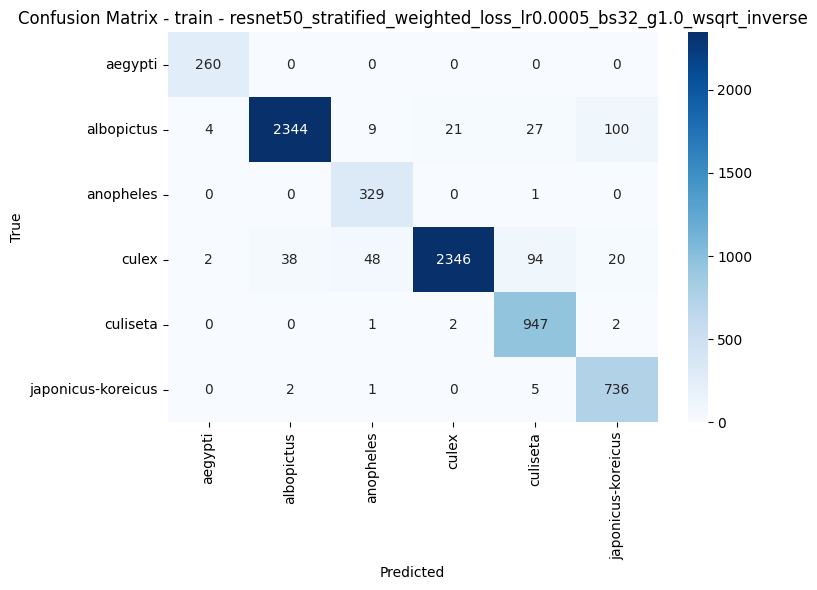


TRAIN Evaluation: resnet50_stratified_weighted_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9698
Balanced Accuracy:  0.9850
Macro Precision:    0.9623
Macro Recall:       0.9850
Macro F1:           0.9728
Weighted F1:        0.9701
ROC-AUC:            0.9993

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,1.000000,1.000000,1.000000,222
1,albopictus,0.994775,0.960792,0.977488,2576
2,anopheles,0.979042,1.000000,0.989410,327
3,culex,0.990535,0.953645,0.971740,2524
4,culiseta,0.899441,0.996904,0.945668,969
5,japonicus-koreicus,0.910240,0.998613,0.952381,721



Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    1.0000    1.0000       222
        albopictus     0.9948    0.9608    0.9775      2576
         anopheles     0.9790    1.0000    0.9894       327
             culex     0.9905    0.9536    0.9717      2524
          culiseta     0.8994    0.9969    0.9457       969
japonicus-koreicus     0.9102    0.9986    0.9524       721

          accuracy                         0.9698      7339
         macro avg     0.9623    0.9850    0.9728      7339
      weighted avg     0.9719    0.9698    0.9701      7339



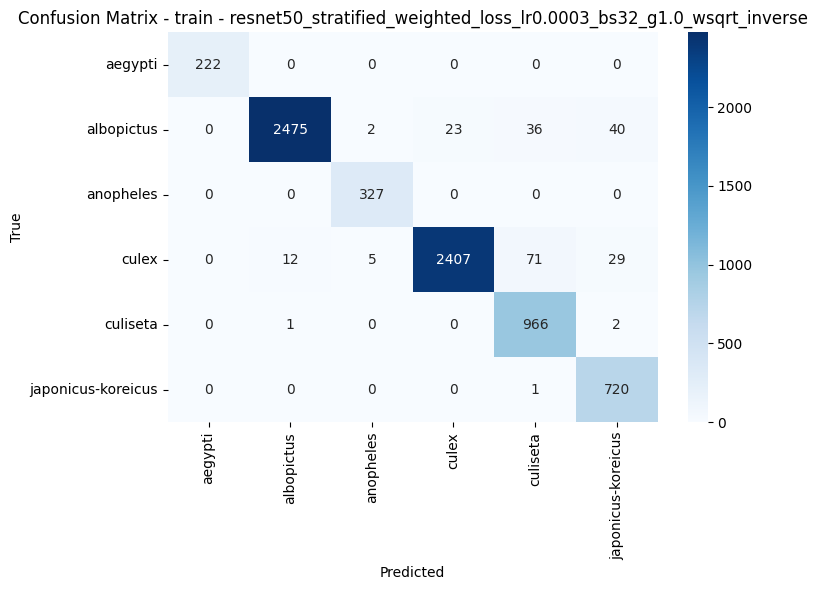


TRAIN Evaluation: resnet50_stratified_weighted_loss_lr0.0001_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9643
Balanced Accuracy:  0.9811
Macro Precision:    0.9543
Macro Recall:       0.9811
Macro F1:           0.9665
Weighted F1:        0.9646
ROC-AUC:            0.9990

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.975265,1.000000,0.987478,276
1,albopictus,0.985197,0.974566,0.979853,2595
2,anopheles,0.964497,1.000000,0.981928,326
3,culex,0.991925,0.926558,0.958128,2519
4,culiseta,0.858095,0.996681,0.922211,904
5,japonicus-koreicus,0.950535,0.988873,0.969325,719



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9753    1.0000    0.9875       276
        albopictus     0.9852    0.9746    0.9799      2595
         anopheles     0.9645    1.0000    0.9819       326
             culex     0.9919    0.9266    0.9581      2519
          culiseta     0.8581    0.9967    0.9222       904
japonicus-koreicus     0.9505    0.9889    0.9693       719

          accuracy                         0.9643      7339
         macro avg     0.9543    0.9811    0.9665      7339
      weighted avg     0.9672    0.9643    0.9646      7339



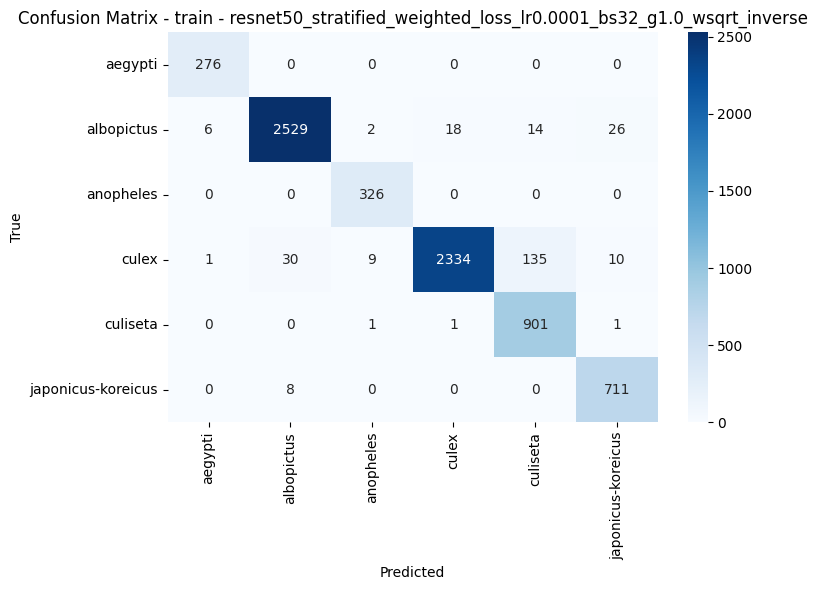


VALIDATION Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9104
Balanced Accuracy:  0.5787
Macro Precision:    0.6055
Macro Recall:       0.5787
Macro F1:           0.5847
Weighted F1:        0.9094
ROC-AUC:            0.9411

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.333333,0.142857,0.200000,7
1,albopictus,0.948424,0.948424,0.948424,698
2,anopheles,0.200000,0.153846,0.173913,13
3,culex,0.957971,0.951079,0.954513,695
4,culiseta,0.669725,0.768421,0.715686,95
5,japonicus-koreicus,0.523810,0.507692,0.515625,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3333    0.1429    0.2000         7
        albopictus     0.9484    0.9484    0.9484       698
         anopheles     0.2000    0.1538    0.1739        13
             culex     0.9580    0.9511    0.9545       695
          culiseta     0.6697    0.7684    0.7157        95
japonicus-koreicus     0.5238    0.5077    0.5156        65

          accuracy                         0.9104      1573
         macro avg     0.6055    0.5787    0.5847      1573
      weighted avg     0.9093    0.9104    0.9094      1573



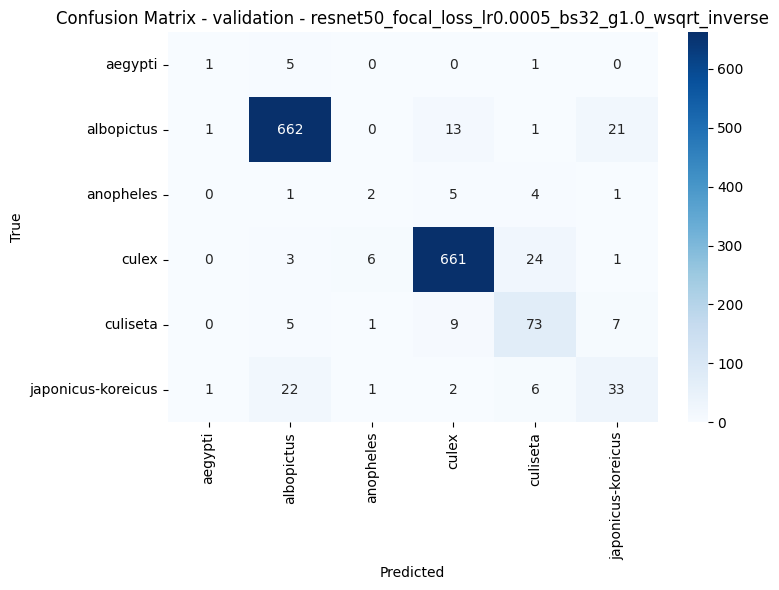


VALIDATION Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8748
Balanced Accuracy:  0.6413
Macro Precision:    0.5877
Macro Recall:       0.6413
Macro F1:           0.5986
Weighted F1:        0.8891
ROC-AUC:            0.9460

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.333333,0.285714,0.307692,7
1,albopictus,0.957929,0.848138,0.899696,698
2,anopheles,0.210526,0.307692,0.250000,13
3,culex,0.966374,0.951079,0.958666,695
4,culiseta,0.755319,0.747368,0.751323,95
5,japonicus-koreicus,0.302632,0.707692,0.423963,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3333    0.2857    0.3077         7
        albopictus     0.9579    0.8481    0.8997       698
         anopheles     0.2105    0.3077    0.2500        13
             culex     0.9664    0.9511    0.9587       695
          culiseta     0.7553    0.7474    0.7513        95
japonicus-koreicus     0.3026    0.7077    0.4240        65

          accuracy                         0.8748      1573
         macro avg     0.5877    0.6413    0.5986      1573
      weighted avg     0.9134    0.8748    0.8891      1573



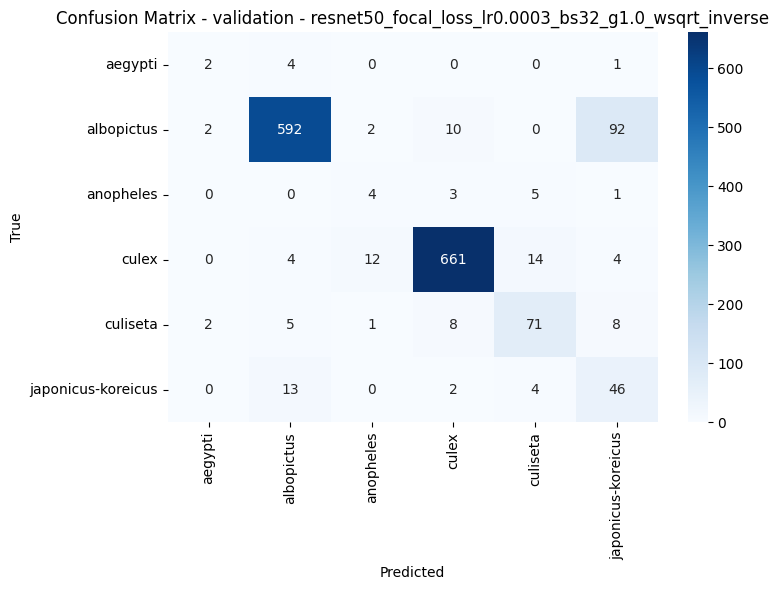


VALIDATION Evaluation: resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8423
Balanced Accuracy:  0.5456
Macro Precision:    0.4974
Macro Recall:       0.5456
Macro F1:           0.5044
Weighted F1:        0.8630
ROC-AUC:            0.9069

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.100000,0.142857,0.117647,7
1,albopictus,0.946166,0.830946,0.884821,698
2,anopheles,0.037037,0.076923,0.050000,13
3,culex,0.955157,0.919424,0.936950,695
4,culiseta,0.685393,0.642105,0.663043,95
5,japonicus-koreicus,0.260606,0.661538,0.373913,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.1000    0.1429    0.1176         7
        albopictus     0.9462    0.8309    0.8848       698
         anopheles     0.0370    0.0769    0.0500        13
             culex     0.9552    0.9194    0.9370       695
          culiseta     0.6854    0.6421    0.6630        95
japonicus-koreicus     0.2606    0.6615    0.3739        65

          accuracy                         0.8423      1573
         macro avg     0.4974    0.5456    0.5044      1573
      weighted avg     0.8948    0.8423    0.8630      1573



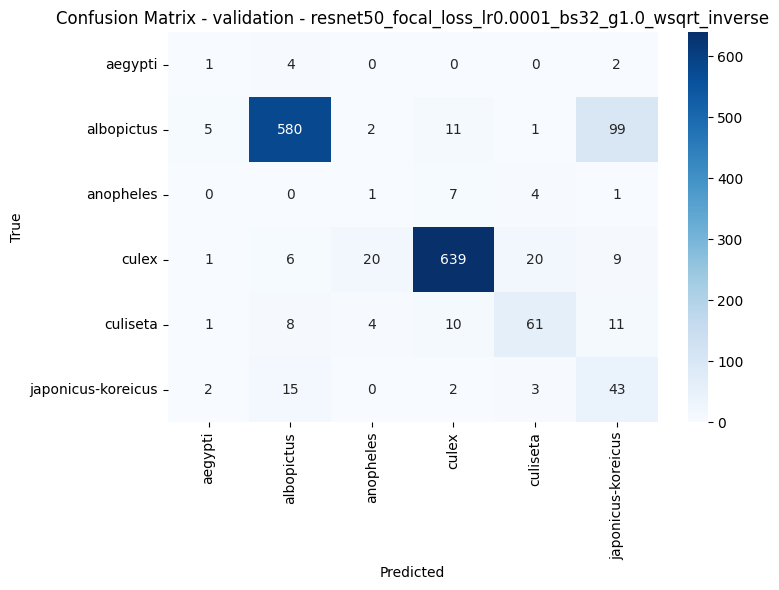


VALIDATION Evaluation: resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.9110
Balanced Accuracy:  0.6257
Macro Precision:    0.5893
Macro Recall:       0.6257
Macro F1:           0.6033
Weighted F1:        0.9115
ROC-AUC:            0.9532

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.961136,0.921203,0.940746,698
2,anopheles,0.272727,0.461538,0.342857,13
3,culex,0.934266,0.961151,0.947518,695
4,culiseta,0.785714,0.810526,0.797927,95
5,japonicus-koreicus,0.582090,0.600000,0.590909,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9611    0.9212    0.9407       698
         anopheles     0.2727    0.4615    0.3429        13
             culex     0.9343    0.9612    0.9475       695
          culiseta     0.7857    0.8105    0.7979        95
japonicus-koreicus     0.5821    0.6000    0.5909        65

          accuracy                         0.9110      1573
         macro avg     0.5893    0.6257    0.6033      1573
      weighted avg     0.9130    0.9110    0.9115      1573



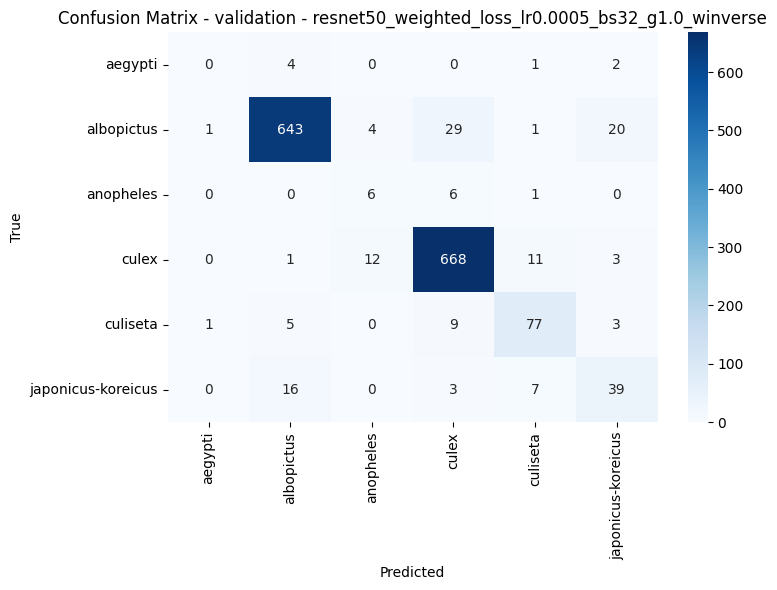


VALIDATION Evaluation: resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.8709
Balanced Accuracy:  0.6438
Macro Precision:    0.5510
Macro Recall:       0.6438
Macro F1:           0.5799
Weighted F1:        0.8831
ROC-AUC:            0.9407

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.153846,0.285714,0.200000,7
1,albopictus,0.969355,0.861032,0.911988,698
2,anopheles,0.166667,0.307692,0.216216,13
3,culex,0.936139,0.928058,0.932081,695
4,culiseta,0.696970,0.726316,0.711340,95
5,japonicus-koreicus,0.382812,0.753846,0.507772,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.1538    0.2857    0.2000         7
        albopictus     0.9694    0.8610    0.9120       698
         anopheles     0.1667    0.3077    0.2162        13
             culex     0.9361    0.9281    0.9321       695
          culiseta     0.6970    0.7263    0.7113        95
japonicus-koreicus     0.3828    0.7538    0.5078        65

          accuracy                         0.8709      1573
         macro avg     0.5510    0.6438    0.5799      1573
      weighted avg     0.9037    0.8709    0.8831      1573



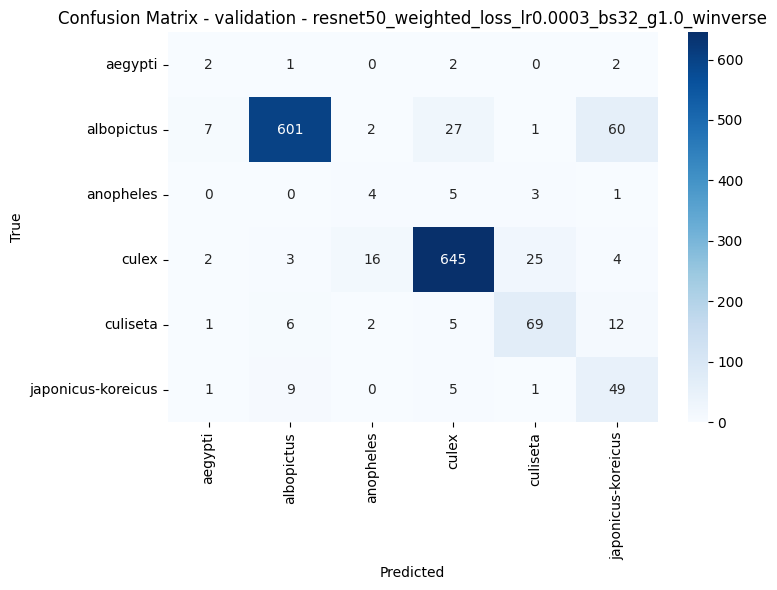


VALIDATION Evaluation: resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.8976
Balanced Accuracy:  0.5371
Macro Precision:    0.5376
Macro Recall:       0.5371
Macro F1:           0.5343
Weighted F1:        0.8957
ROC-AUC:            0.9231

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.166667,0.142857,0.153846,7
1,albopictus,0.935120,0.949857,0.942431,698
2,anopheles,0.000000,0.000000,0.000000,13
3,culex,0.950073,0.930935,0.940407,695
4,culiseta,0.613445,0.768421,0.682243,95
5,japonicus-koreicus,0.560000,0.430769,0.486957,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.1667    0.1429    0.1538         7
        albopictus     0.9351    0.9499    0.9424       698
         anopheles     0.0000    0.0000    0.0000        13
             culex     0.9501    0.9309    0.9404       695
          culiseta     0.6134    0.7684    0.6822        95
japonicus-koreicus     0.5600    0.4308    0.4870        65

          accuracy                         0.8976      1573
         macro avg     0.5376    0.5371    0.5343      1573
      weighted avg     0.8957    0.8976    0.8957      1573



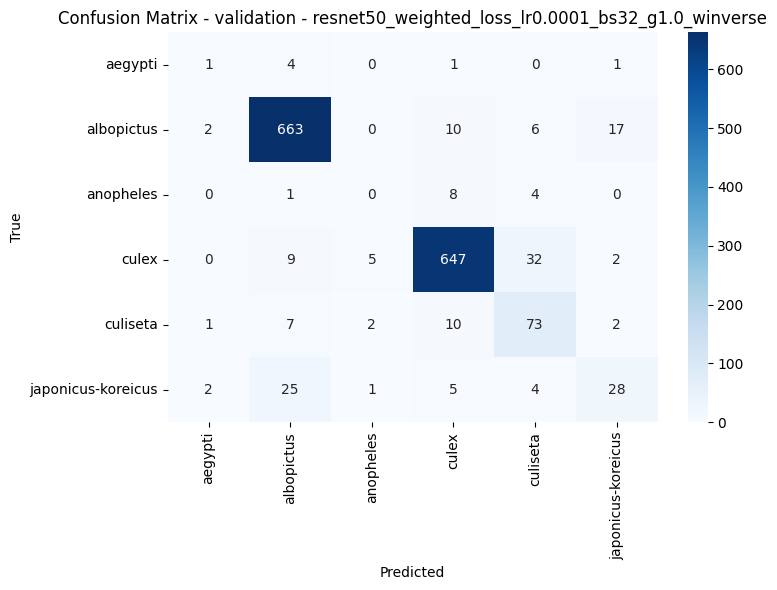


VALIDATION Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.0432
Balanced Accuracy:  0.3147
Macro Precision:    0.0616
Macro Recall:       0.3147
Macro F1:           0.0816
Weighted F1:        0.0242
ROC-AUC:            0.7720

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.005533,0.571429,0.010959,7
1,albopictus,0.000000,0.000000,0.000000,698
2,anopheles,0.016260,0.615385,0.031683,13
3,culex,0.000000,0.000000,0.000000,695
4,culiseta,0.244444,0.347368,0.286957,95
5,japonicus-koreicus,0.103139,0.353846,0.159722,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0055    0.5714    0.0110         7
        albopictus     0.0000    0.0000    0.0000       698
         anopheles     0.0163    0.6154    0.0317        13
             culex     0.0000    0.0000    0.0000       695
          culiseta     0.2444    0.3474    0.2870        95
japonicus-koreicus     0.1031    0.3538    0.1597        65

          accuracy                         0.0432      1573
         macro avg     0.0616    0.3147    0.0816      1573
      weighted avg     0.0192    0.0432    0.0242      1573



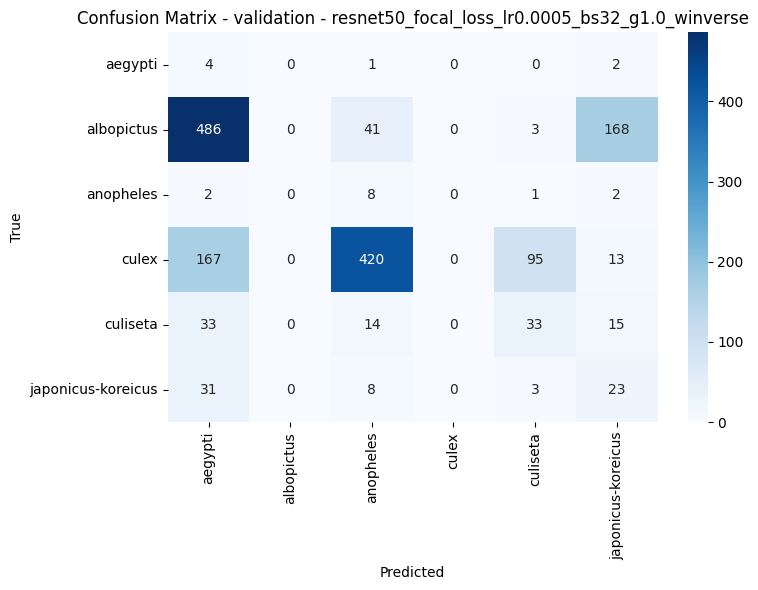


VALIDATION Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.3751
Balanced Accuracy:  0.5598
Macro Precision:    0.4090
Macro Recall:       0.5598
Macro F1:           0.2771
Weighted F1:        0.4442
ROC-AUC:            0.9029

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.020833,0.428571,0.039735,7
1,albopictus,1.000000,0.154728,0.267990,698
2,anopheles,0.046632,0.692308,0.087379,13
3,culex,0.988473,0.493525,0.658349,695
4,culiseta,0.300000,0.789474,0.434783,95
5,japonicus-koreicus,0.097928,0.800000,0.174497,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0208    0.4286    0.0397         7
        albopictus     1.0000    0.1547    0.2680       698
         anopheles     0.0466    0.6923    0.0874        13
             culex     0.9885    0.4935    0.6583       695
          culiseta     0.3000    0.7895    0.4348        95
japonicus-koreicus     0.0979    0.8000    0.1745        65

          accuracy                         0.3751      1573
         macro avg     0.4090    0.5598    0.2771      1573
      weighted avg     0.9031    0.3751    0.4442      1573



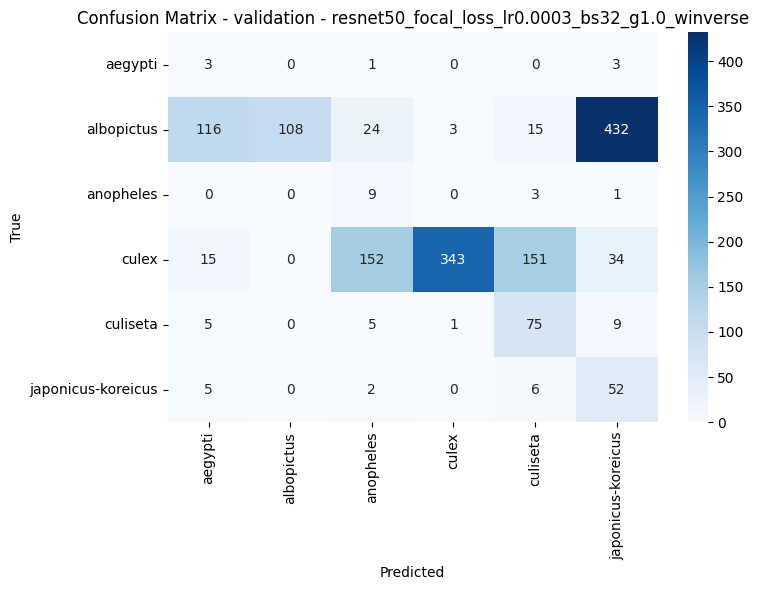


VALIDATION Evaluation: resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.3261
Balanced Accuracy:  0.5223
Macro Precision:    0.3892
Macro Recall:       0.5223
Macro F1:           0.2477
Weighted F1:        0.4042
ROC-AUC:            0.8711

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.036145,0.428571,0.066667,7
1,albopictus,0.978723,0.197708,0.328963,698
2,anopheles,0.039648,0.692308,0.075000,13
3,culex,0.968750,0.356835,0.521556,695
4,culiseta,0.223776,0.673684,0.335958,95
5,japonicus-koreicus,0.087931,0.784615,0.158140,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0361    0.4286    0.0667         7
        albopictus     0.9787    0.1977    0.3290       698
         anopheles     0.0396    0.6923    0.0750        13
             culex     0.9688    0.3568    0.5216       695
          culiseta     0.2238    0.6737    0.3360        95
japonicus-koreicus     0.0879    0.7846    0.1581        65

          accuracy                         0.3261      1573
         macro avg     0.3892    0.5223    0.2477      1573
      weighted avg     0.8800    0.3261    0.4042      1573



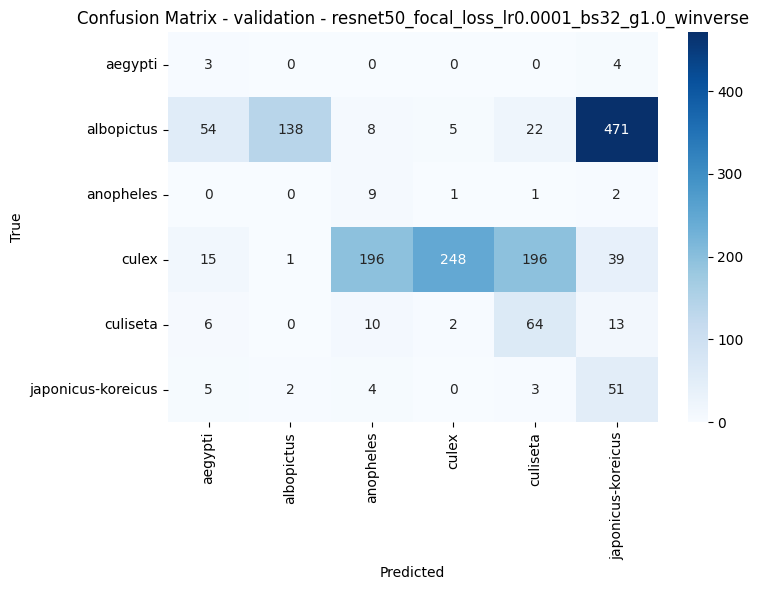


VALIDATION Evaluation: resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8881
Balanced Accuracy:  0.5711
Macro Precision:    0.5102
Macro Recall:       0.5711
Macro F1:           0.5310
Weighted F1:        0.8926
ROC-AUC:            0.9309

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.947683,0.908309,0.927579,698
2,anopheles,0.125000,0.076923,0.095238,13
3,culex,0.971037,0.916547,0.943005,695
4,culiseta,0.569444,0.863158,0.686192,95
5,japonicus-koreicus,0.447917,0.661538,0.534161,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9477    0.9083    0.9276       698
         anopheles     0.1250    0.0769    0.0952        13
             culex     0.9710    0.9165    0.9430       695
          culiseta     0.5694    0.8632    0.6862        95
japonicus-koreicus     0.4479    0.6615    0.5342        65

          accuracy                         0.8881      1573
         macro avg     0.5102    0.5711    0.5310      1573
      weighted avg     0.9035    0.8881    0.8926      1573



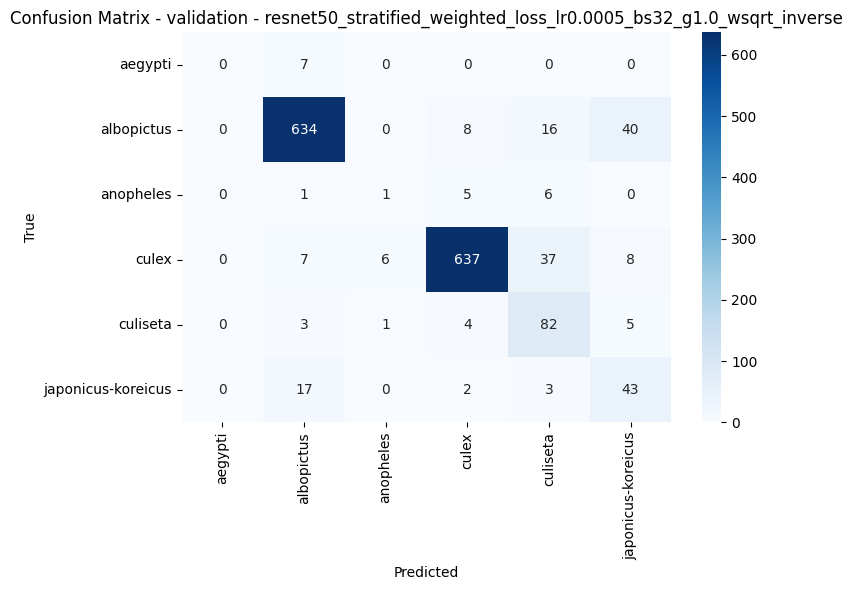


VALIDATION Evaluation: resnet50_stratified_weighted_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8932
Balanced Accuracy:  0.5444
Macro Precision:    0.4960
Macro Recall:       0.5444
Macro F1:           0.5164
Weighted F1:        0.8927
ROC-AUC:            0.9511

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.959276,0.911175,0.934607,698
2,anopheles,0.000000,0.000000,0.000000,13
3,culex,0.934192,0.939568,0.936872,695
4,culiseta,0.622951,0.800000,0.700461,95
5,japonicus-koreicus,0.459770,0.615385,0.526316,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9593    0.9112    0.9346       698
         anopheles     0.0000    0.0000    0.0000        13
             culex     0.9342    0.9396    0.9369       695
          culiseta     0.6230    0.8000    0.7005        95
japonicus-koreicus     0.4598    0.6154    0.5263        65

          accuracy                         0.8932      1573
         macro avg     0.4960    0.5444    0.5164      1573
      weighted avg     0.8950    0.8932    0.8927      1573



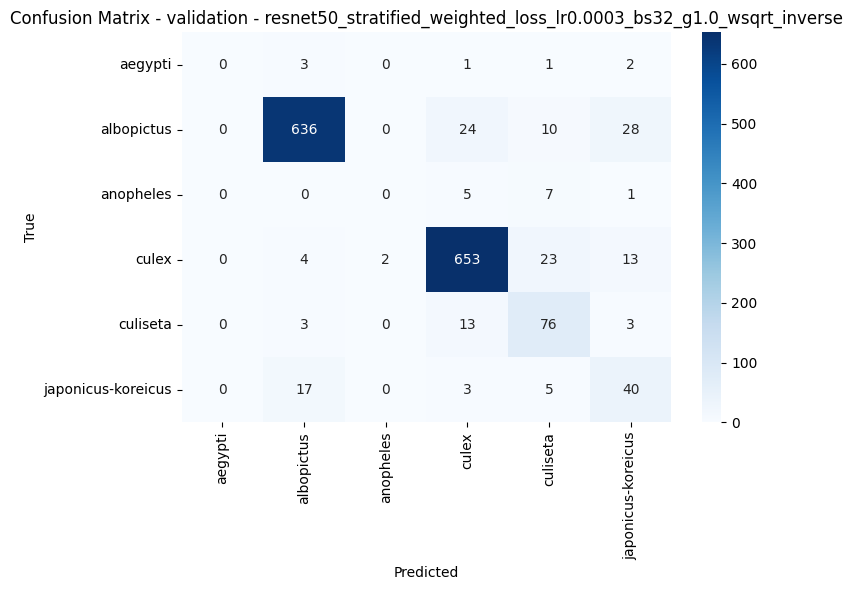


VALIDATION Evaluation: resnet50_stratified_weighted_loss_lr0.0001_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8907
Balanced Accuracy:  0.5290
Macro Precision:    0.5257
Macro Recall:       0.5290
Macro F1:           0.5201
Weighted F1:        0.8902
ROC-AUC:            0.9257

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.945559,0.945559,0.945559,698
2,anopheles,0.200000,0.076923,0.111111,13
3,culex,0.942308,0.916547,0.929249,695
4,culiseta,0.558140,0.757895,0.642857,95
5,japonicus-koreicus,0.508197,0.476923,0.492063,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9456    0.9456    0.9456       698
         anopheles     0.2000    0.0769    0.1111        13
             culex     0.9423    0.9165    0.9292       695
          culiseta     0.5581    0.7579    0.6429        95
japonicus-koreicus     0.5082    0.4769    0.4921        65

          accuracy                         0.8907      1573
         macro avg     0.5257    0.5290    0.5201      1573
      weighted avg     0.8923    0.8907    0.8902      1573



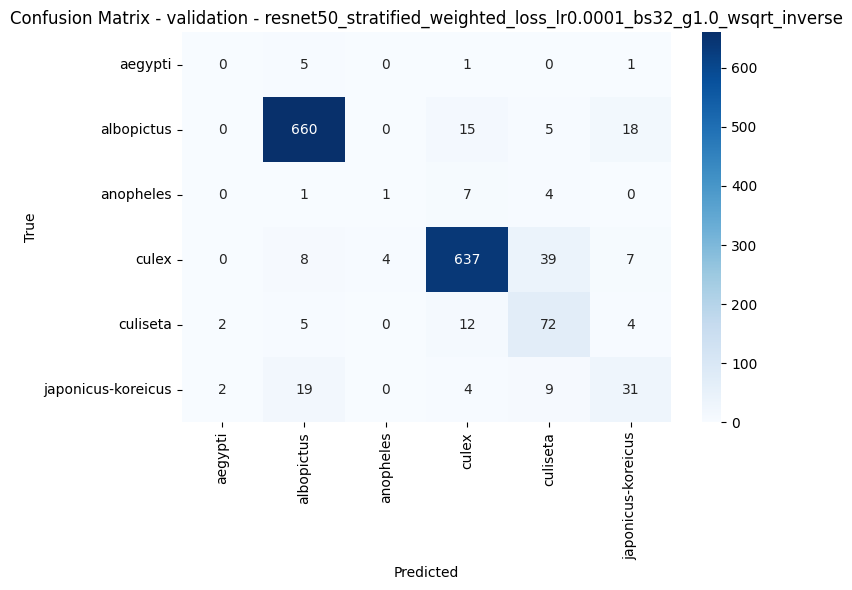


TEST Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9231
Balanced Accuracy:  0.6109
Macro Precision:    0.6611
Macro Recall:       0.6109
Macro F1:           0.6165
Weighted F1:        0.9217
ROC-AUC:            0.9476

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.500000,0.142857,0.222222,7
1,albopictus,0.946554,0.962804,0.954610,699
2,anopheles,0.222222,0.166667,0.190476,12
3,culex,0.973254,0.941092,0.956903,696
4,culiseta,0.710744,0.905263,0.796296,95
5,japonicus-koreicus,0.614035,0.546875,0.578512,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.5000    0.1429    0.2222         7
        albopictus     0.9466    0.9628    0.9546       699
         anopheles     0.2222    0.1667    0.1905        12
             culex     0.9733    0.9411    0.9569       696
          culiseta     0.7107    0.9053    0.7963        95
japonicus-koreicus     0.6140    0.5469    0.5785        64

          accuracy                         0.9231      1573
         macro avg     0.6611    0.6109    0.6165      1573
      weighted avg     0.9231    0.9231    0.9217      1573



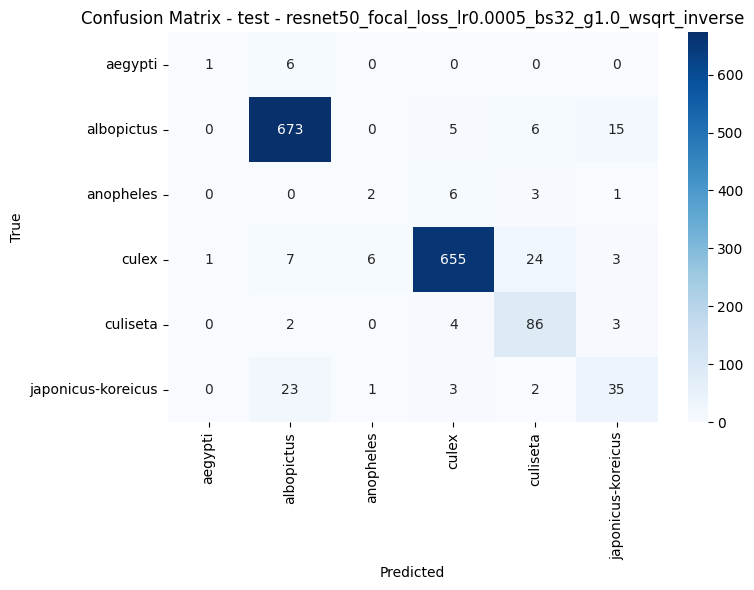


TEST Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8671
Balanced Accuracy:  0.6382
Macro Precision:    0.5677
Macro Recall:       0.6382
Macro F1:           0.5848
Weighted F1:        0.8832
ROC-AUC:            0.9524

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.250000,0.285714,0.266667,7
1,albopictus,0.962171,0.836910,0.895180,699
2,anopheles,0.187500,0.250000,0.214286,12
3,culex,0.957478,0.938218,0.947750,696
4,culiseta,0.752577,0.768421,0.760417,95
5,japonicus-koreicus,0.296296,0.750000,0.424779,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.2857    0.2667         7
        albopictus     0.9622    0.8369    0.8952       699
         anopheles     0.1875    0.2500    0.2143        12
             culex     0.9575    0.9382    0.9478       696
          culiseta     0.7526    0.7684    0.7604        95
japonicus-koreicus     0.2963    0.7500    0.4248        64

          accuracy                         0.8671      1573
         macro avg     0.5677    0.6382    0.5848      1573
      weighted avg     0.9113    0.8671    0.8832      1573



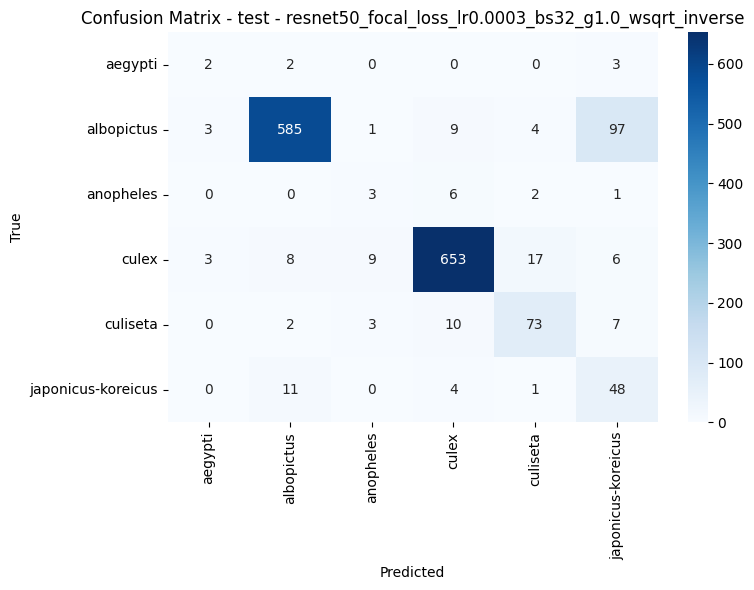


TEST Evaluation: resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8665
Balanced Accuracy:  0.6192
Macro Precision:    0.5395
Macro Recall:       0.6192
Macro F1:           0.5595
Weighted F1:        0.8830
ROC-AUC:            0.9186

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.166667,0.142857,0.153846,7
1,albopictus,0.963259,0.862661,0.910189,699
2,anopheles,0.125000,0.333333,0.181818,12
3,culex,0.956456,0.915230,0.935389,696
4,culiseta,0.714286,0.789474,0.750000,95
5,japonicus-koreicus,0.311594,0.671875,0.425743,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.1667    0.1429    0.1538         7
        albopictus     0.9633    0.8627    0.9102       699
         anopheles     0.1250    0.3333    0.1818        12
             culex     0.9565    0.9152    0.9354       696
          culiseta     0.7143    0.7895    0.7500        95
japonicus-koreicus     0.3116    0.6719    0.4257        64

          accuracy                         0.8665      1573
         macro avg     0.5395    0.6192    0.5595      1573
      weighted avg     0.9088    0.8665    0.8830      1573



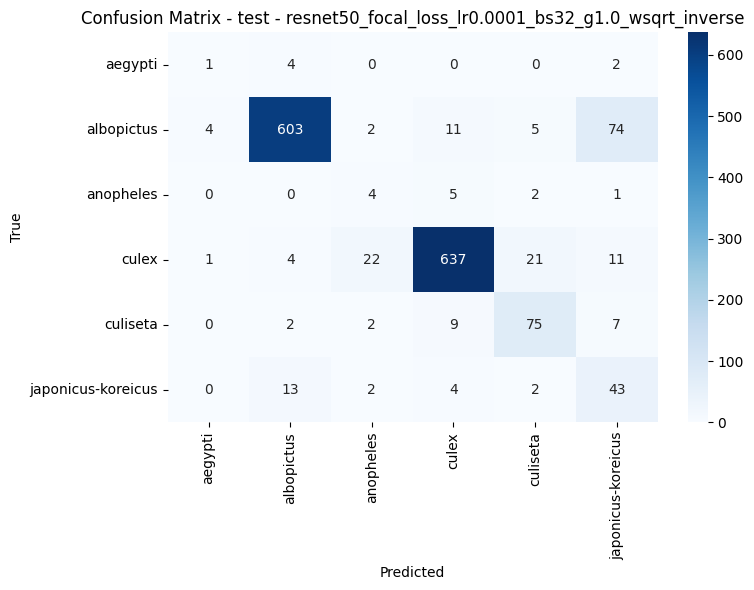


TEST Evaluation: resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.9040
Balanced Accuracy:  0.6548
Macro Precision:    0.6197
Macro Recall:       0.6548
Macro F1:           0.6283
Weighted F1:        0.9086
ROC-AUC:            0.9548

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.400000,0.285714,0.333333,7
1,albopictus,0.964018,0.919886,0.941435,699
2,anopheles,0.148148,0.333333,0.205128,12
3,culex,0.946377,0.938218,0.942280,696
4,culiseta,0.715517,0.873684,0.786730,95
5,japonicus-koreicus,0.544118,0.578125,0.560606,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.4000    0.2857    0.3333         7
        albopictus     0.9640    0.9199    0.9414       699
         anopheles     0.1481    0.3333    0.2051        12
             culex     0.9464    0.9382    0.9423       696
          culiseta     0.7155    0.8737    0.7867        95
japonicus-koreicus     0.5441    0.5781    0.5606        64

          accuracy                         0.9040      1573
         macro avg     0.6197    0.6548    0.6283      1573
      weighted avg     0.9154    0.9040    0.9086      1573



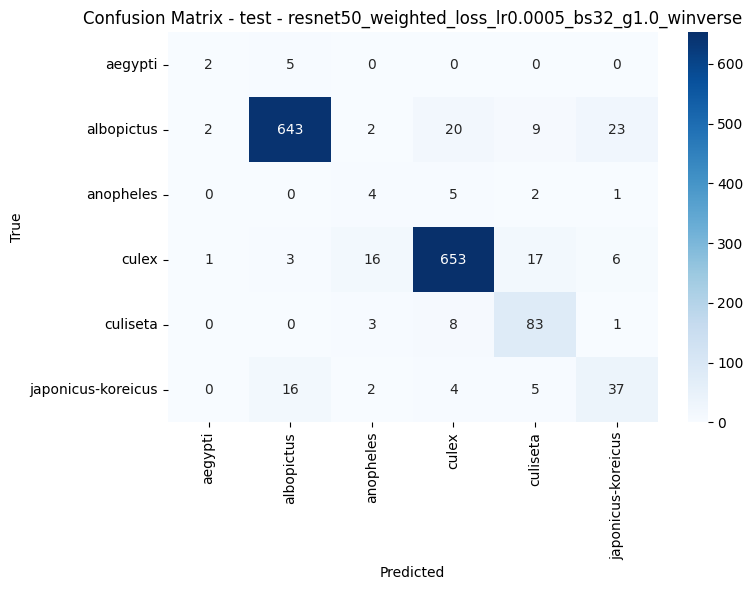


TEST Evaluation: resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.8652
Balanced Accuracy:  0.6643
Macro Precision:    0.5469
Macro Recall:       0.6643
Macro F1:           0.5830
Weighted F1:        0.8804
ROC-AUC:            0.9408

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.181818,0.285714,0.222222,7
1,albopictus,0.972039,0.845494,0.904361,699
2,anopheles,0.166667,0.333333,0.222222,12
3,culex,0.949254,0.913793,0.931186,696
4,culiseta,0.652542,0.810526,0.723005,95
5,japonicus-koreicus,0.359155,0.796875,0.495146,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.1818    0.2857    0.2222         7
        albopictus     0.9720    0.8455    0.9044       699
         anopheles     0.1667    0.3333    0.2222        12
             culex     0.9493    0.9138    0.9312       696
          culiseta     0.6525    0.8105    0.7230        95
japonicus-koreicus     0.3592    0.7969    0.4951        64

          accuracy                         0.8652      1573
         macro avg     0.5469    0.6643    0.5830      1573
      weighted avg     0.9081    0.8652    0.8804      1573



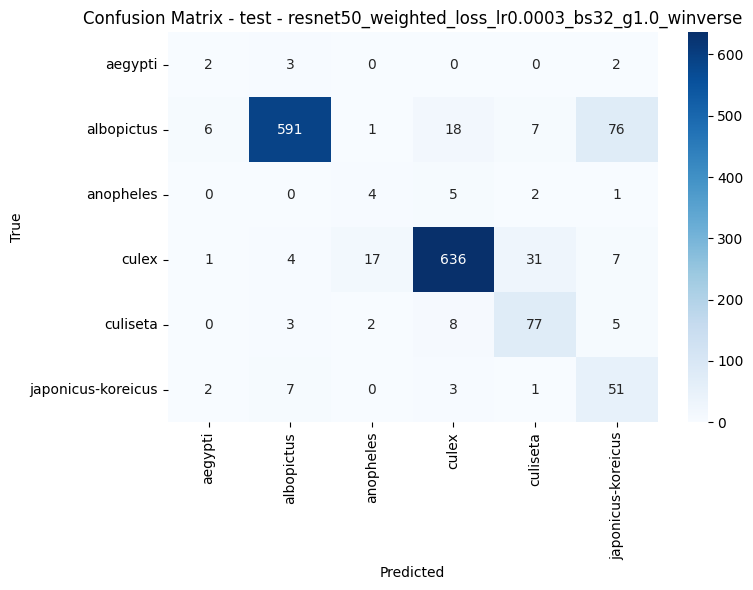


TEST Evaluation: resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.9034
Balanced Accuracy:  0.6338
Macro Precision:    0.6274
Macro Recall:       0.6338
Macro F1:           0.6239
Weighted F1:        0.9023
ROC-AUC:            0.9402

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.285714,0.285714,0.285714,7
1,albopictus,0.936530,0.949928,0.943182,699
2,anopheles,0.333333,0.416667,0.370370,12
3,culex,0.951399,0.928161,0.939636,696
4,culiseta,0.647541,0.831579,0.728111,95
5,japonicus-koreicus,0.609756,0.390625,0.476190,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2857    0.2857    0.2857         7
        albopictus     0.9365    0.9499    0.9432       699
         anopheles     0.3333    0.4167    0.3704        12
             culex     0.9514    0.9282    0.9396       696
          culiseta     0.6475    0.8316    0.7281        95
japonicus-koreicus     0.6098    0.3906    0.4762        64

          accuracy                         0.9034      1573
         macro avg     0.6274    0.6338    0.6239      1573
      weighted avg     0.9049    0.9034    0.9023      1573



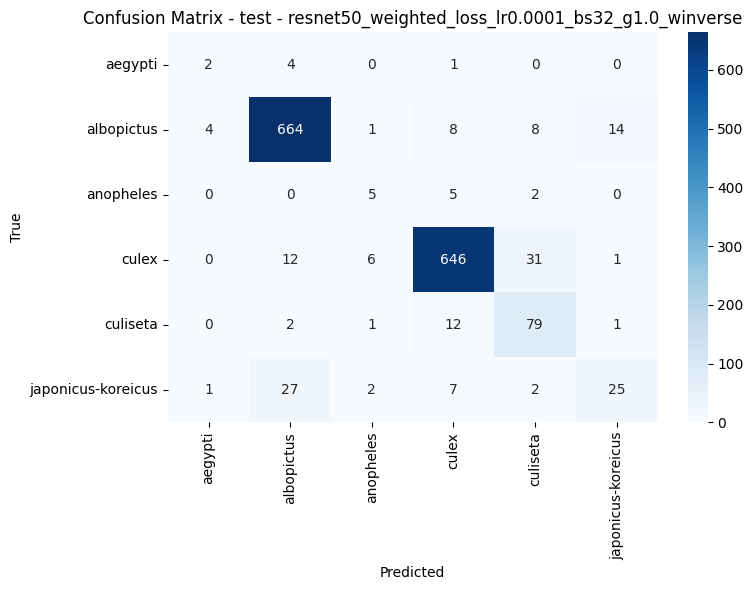


TEST Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.0540
Balanced Accuracy:  0.4227
Macro Precision:    0.0811
Macro Recall:       0.4227
Macro F1:           0.1053
Weighted F1:        0.0317
ROC-AUC:            0.8321

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.009669,1.000000,0.019152,7
1,albopictus,0.000000,0.000000,0.000000,699
2,anopheles,0.015564,0.666667,0.030418,12
3,culex,0.000000,0.000000,0.000000,696
4,culiseta,0.333333,0.463158,0.387665,95
5,japonicus-koreicus,0.128079,0.406250,0.194757,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0097    1.0000    0.0192         7
        albopictus     0.0000    0.0000    0.0000       699
         anopheles     0.0156    0.6667    0.0304        12
             culex     0.0000    0.0000    0.0000       696
          culiseta     0.3333    0.4632    0.3877        95
japonicus-koreicus     0.1281    0.4062    0.1948        64

          accuracy                         0.0540      1573
         macro avg     0.0811    0.4227    0.1053      1573
      weighted avg     0.0255    0.0540    0.0317      1573



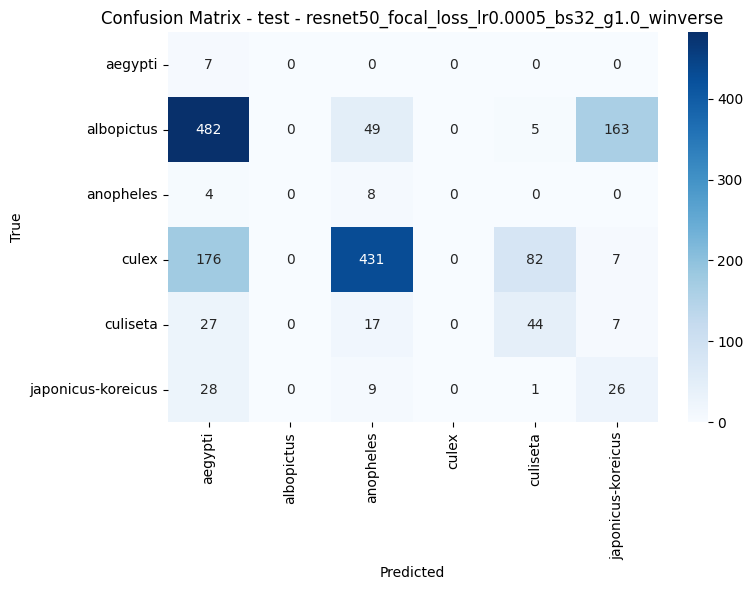


TEST Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.3770
Balanced Accuracy:  0.5306
Macro Precision:    0.4121
Macro Recall:       0.5306
Macro F1:           0.2790
Weighted F1:        0.4474
ROC-AUC:            0.9015

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.006369,0.142857,0.012195,7
1,albopictus,0.990099,0.143062,0.250000,699
2,anopheles,0.048544,0.833333,0.091743,12
3,culex,0.994444,0.514368,0.678030,696
4,culiseta,0.342342,0.800000,0.479495,95
5,japonicus-koreicus,0.091082,0.750000,0.162437,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0064    0.1429    0.0122         7
        albopictus     0.9901    0.1431    0.2500       699
         anopheles     0.0485    0.8333    0.0917        12
             culex     0.9944    0.5144    0.6780       696
          culiseta     0.3423    0.8000    0.4795        95
japonicus-koreicus     0.0911    0.7500    0.1624        64

          accuracy                         0.3770      1573
         macro avg     0.4121    0.5306    0.2790      1573
      weighted avg     0.9048    0.3770    0.4474      1573



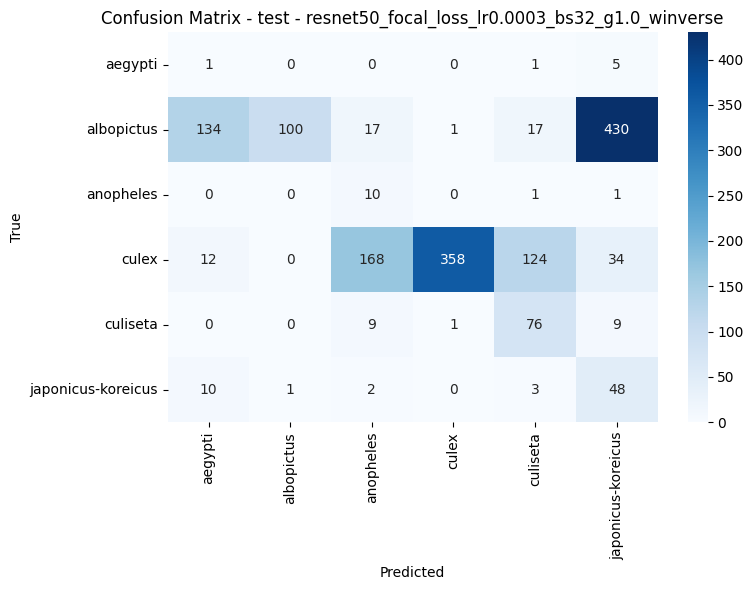


TEST Evaluation: resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.3210
Balanced Accuracy:  0.5267
Macro Precision:    0.3935
Macro Recall:       0.5267
Macro F1:           0.2455
Weighted F1:        0.3947
ROC-AUC:            0.8786

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.022222,0.285714,0.041237,7
1,albopictus,0.978723,0.197425,0.328571,699
2,anopheles,0.040724,0.750000,0.077253,12
3,culex,0.987124,0.330460,0.495156,696
4,culiseta,0.241722,0.768421,0.367758,95
5,japonicus-koreicus,0.090444,0.828125,0.163077,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0222    0.2857    0.0412         7
        albopictus     0.9787    0.1974    0.3286       699
         anopheles     0.0407    0.7500    0.0773        12
             culex     0.9871    0.3305    0.4952       696
          culiseta     0.2417    0.7684    0.3678        95
japonicus-koreicus     0.0904    0.8281    0.1631        64

          accuracy                         0.3210      1573
         macro avg     0.3935    0.5267    0.2455      1573
      weighted avg     0.8904    0.3210    0.3947      1573



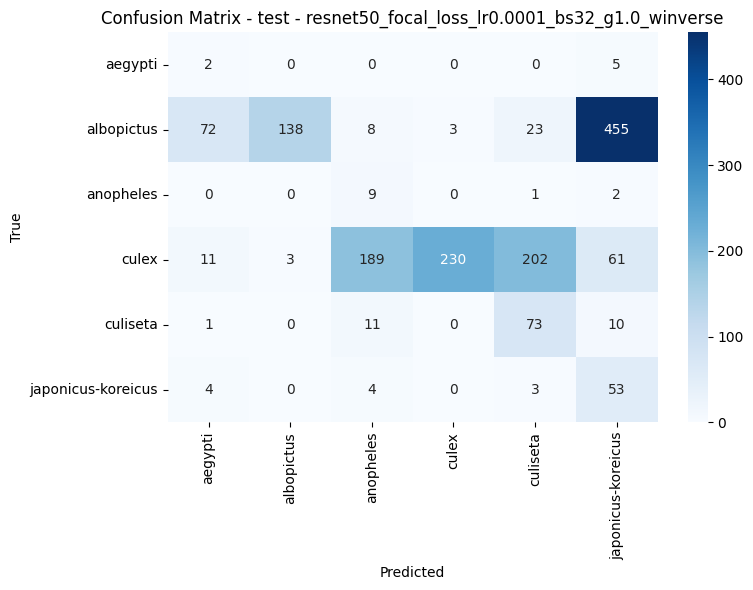


TEST Evaluation: resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8798
Balanced Accuracy:  0.6030
Macro Precision:    0.5526
Macro Recall:       0.6030
Macro F1:           0.5616
Weighted F1:        0.8869
ROC-AUC:            0.9394

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.946349,0.908441,0.927007,699
2,anopheles,0.428571,0.250000,0.315789,12
3,culex,0.971698,0.887931,0.927928,696
4,culiseta,0.541935,0.884211,0.672000,95
5,japonicus-koreicus,0.427184,0.687500,0.526946,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9463    0.9084    0.9270       699
         anopheles     0.4286    0.2500    0.3158        12
             culex     0.9717    0.8879    0.9279       696
          culiseta     0.5419    0.8842    0.6720        95
japonicus-koreicus     0.4272    0.6875    0.5269        64

          accuracy                         0.8798      1573
         macro avg     0.5526    0.6030    0.5616      1573
      weighted avg     0.9039    0.8798    0.8869      1573



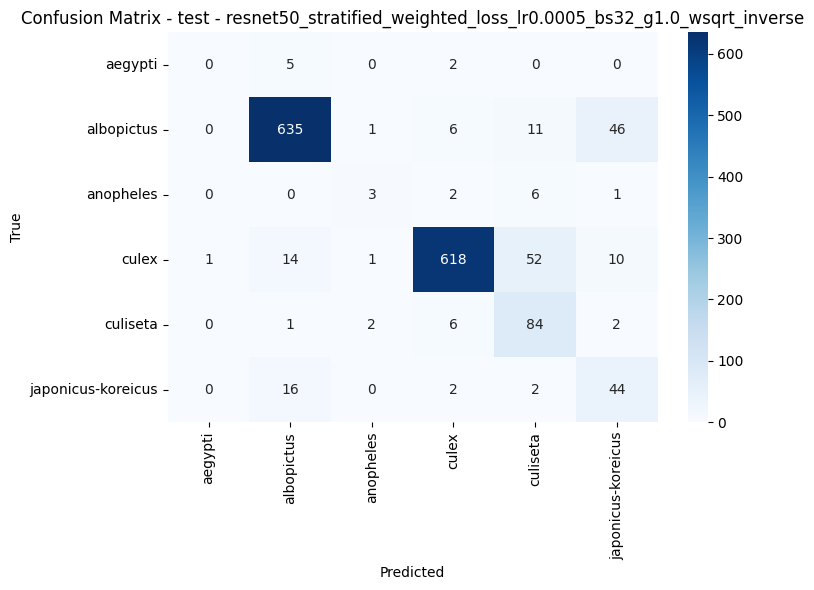


TEST Evaluation: resnet50_stratified_weighted_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8938
Balanced Accuracy:  0.5929
Macro Precision:    0.6098
Macro Recall:       0.5929
Macro F1:           0.5690
Weighted F1:        0.8960
ROC-AUC:            0.9150

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.963134,0.896996,0.928889,699
2,anopheles,0.666667,0.166667,0.266667,12
3,culex,0.941945,0.932471,0.937184,696
4,culiseta,0.609929,0.905263,0.728814,95
5,japonicus-koreicus,0.477273,0.656250,0.552632,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9631    0.8970    0.9289       699
         anopheles     0.6667    0.1667    0.2667        12
             culex     0.9419    0.9325    0.9372       696
          culiseta     0.6099    0.9053    0.7288        95
japonicus-koreicus     0.4773    0.6562    0.5526        64

          accuracy                         0.8938      1573
         macro avg     0.6098    0.5929    0.5690      1573
      weighted avg     0.9061    0.8938    0.8960      1573



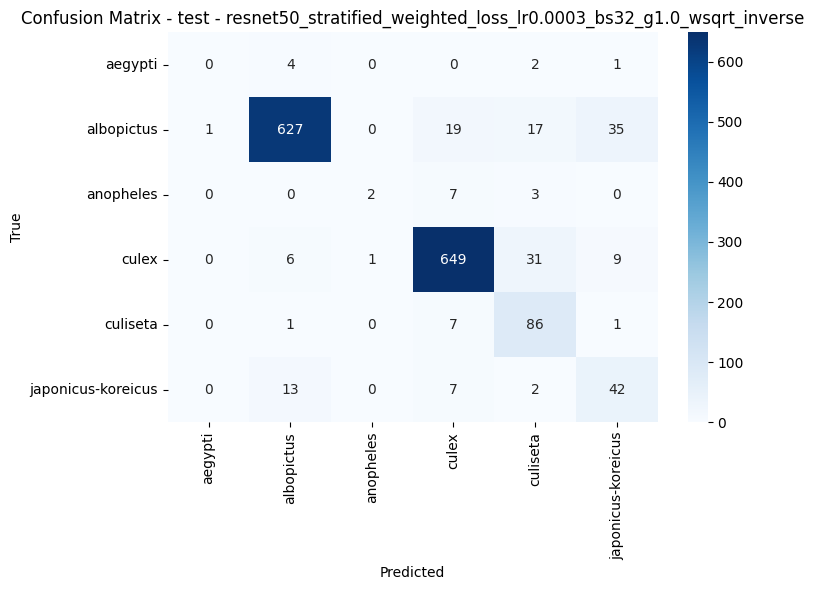


TEST Evaluation: resnet50_stratified_weighted_loss_lr0.0001_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8932
Balanced Accuracy:  0.5925
Macro Precision:    0.5906
Macro Recall:       0.5925
Macro F1:           0.5823
Weighted F1:        0.8959
ROC-AUC:            0.9073

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.250000,0.142857,0.181818,7
1,albopictus,0.947143,0.948498,0.947820,699
2,anopheles,0.285714,0.166667,0.210526,12
3,culex,0.955657,0.897989,0.925926,696
4,culiseta,0.539568,0.789474,0.641026,95
5,japonicus-koreicus,0.565217,0.609375,0.586466,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9471    0.9485    0.9478       699
         anopheles     0.2857    0.1667    0.2105        12
             culex     0.9557    0.8980    0.9259       696
          culiseta     0.5396    0.7895    0.6410        95
japonicus-koreicus     0.5652    0.6094    0.5865        64

          accuracy                         0.8932      1573
         macro avg     0.5906    0.5925    0.5823      1573
      weighted avg     0.9026    0.8932    0.8959      1573



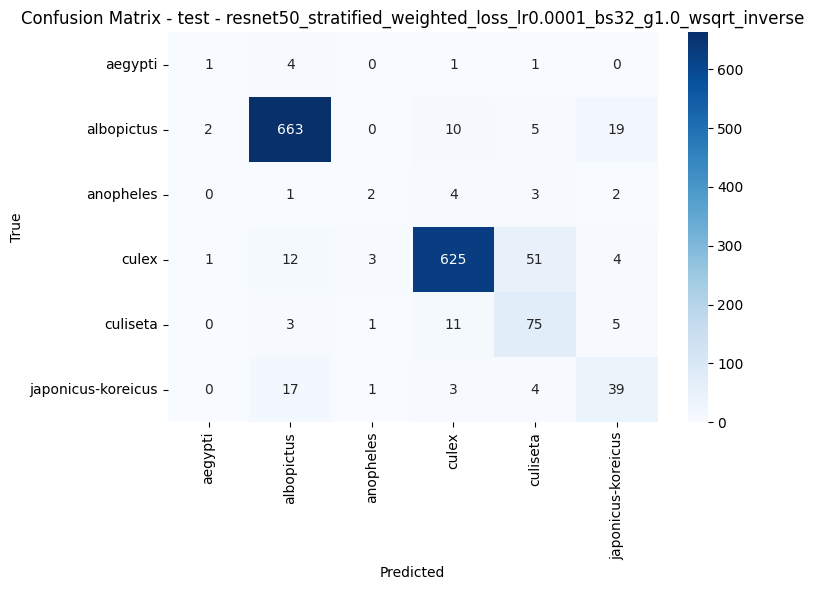


===== Detailed Evaluation Summary =====


,split,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr
32,test,resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse,0.321043,0.526691,0.393493,0.526691,0.245509,0.890377,0.321043,0.394717,0.878556
8,train,resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse,0.490394,0.736715,0.573688,0.736715,0.499782,0.791250,0.490394,0.467143,0.965540
20,validation,resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse,0.326128,0.522287,0.389162,0.522287,0.247714,0.879957,0.326128,0.404154,0.871105
26,test,resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_i...,0.866497,0.619238,0.539544,0.619238,0.559497,0.908759,0.866497,0.883032,0.918557
2,train,resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_i...,0.949721,0.973844,0.913541,0.973844,0.939943,0.956109,0.949721,0.950798,0.999067
14,validation,resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_i...,0.842339,0.545632,0.497393,0.545632,0.504396,0.894782,0.842339,0.863034,0.906871
31,test,resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse,0.376987,0.530603,0.412147,0.530603,0.278983,0.904762,0.376987,0.447421,0.901504
7,train,resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse,0.529909,0.764430,0.592969,0.764430,0.530866,0.812862,0.529909,0.509030,0.978925
19,validation,resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse,0.375079,0.559768,0.408978,0.559768,0.277122,0.903119,0.375079,0.444164,0.902907
25,test,resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_i...,0.867133,0.638211,0.567670,0.638211,0.584846,0.911265,0.867133,0.883171,0.952396


In [22]:
# detailed evaluation for train / validation / test

detailed_eval_list = []

all_split_results = {
    "train": all_train_results,
    "validation": all_val_results,
    "test": all_test_results
}

for split_name, split_results in all_split_results.items():
    for model_name, data in split_results.items():

        print(f"\n==============================")
        print(f"{split_name.upper()} Evaluation: {model_name}")
        print(f"==============================")

        all_preds = data["preds"]
        all_labels = data["labels"]
        all_probs = data["probs"]

        acc = accuracy_score(all_labels, all_preds)
        bal_acc = balanced_accuracy_score(all_labels, all_preds)

        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average=None,
            zero_division=0
        )

        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0
        )

        precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="weighted",
            zero_division=0
        )

        try:
            roc_auc = roc_auc_score(
                all_labels,
                all_probs,
                multi_class="ovr",
                average="macro"
            )
        except:
            roc_auc = np.nan

        cm = confusion_matrix(all_labels, all_preds)

        print(f"Accuracy:           {acc:.4f}")
        print(f"Balanced Accuracy:  {bal_acc:.4f}")
        print(f"Macro Precision:    {precision_macro:.4f}")
        print(f"Macro Recall:       {recall_macro:.4f}")
        print(f"Macro F1:           {f1_macro:.4f}")
        print(f"Weighted F1:        {f1_weighted:.4f}")
        print(f"ROC-AUC:            {roc_auc:.4f}")

        per_class_df = pd.DataFrame({
            "class_name": class_names,
            "precision": precision_per_class,
            "recall": recall_per_class,
            "f1": f1_per_class,
            "support": support
        })

        print("\nPer-class metrics:")
        display(per_class_df)

        print("\nClassification report:")
        print(classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4,
            zero_division=0
        ))

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix - {split_name} - {model_name}")
        plt.tight_layout()
        plt.show()

        detailed_eval_list.append({
            "split": split_name,
            "model": model_name,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "macro_precision": precision_macro,
            "macro_recall": recall_macro,
            "macro_f1": f1_macro,
            "weighted_precision": precision_weighted,
            "weighted_recall": recall_weighted,
            "weighted_f1": f1_weighted,
            "roc_auc_ovr": roc_auc
        })

detailed_eval_df = pd.DataFrame(detailed_eval_list)

print("\n===== Detailed Evaluation Summary =====")
display(detailed_eval_df.sort_values(by=["model", "split"]))

detailed_eval_df.to_csv("/kaggle/working/detailed_eval_results.csv", index=False)

Best method by macro F1: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse


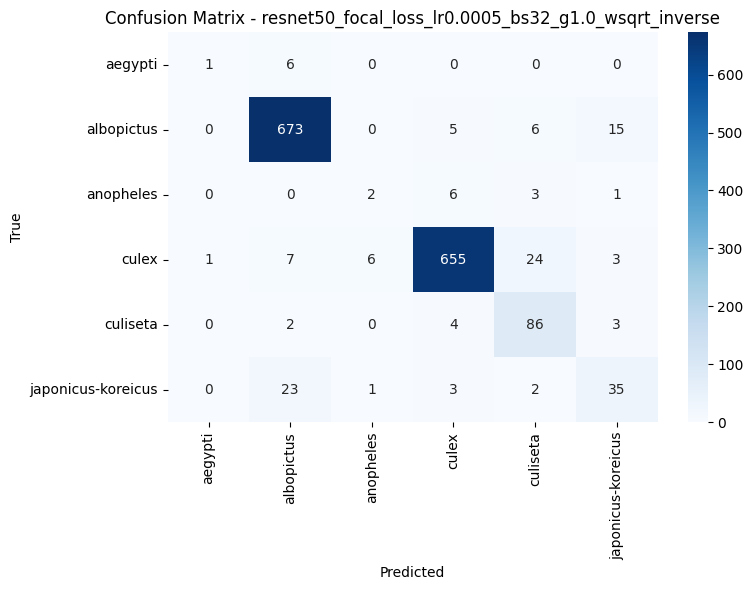

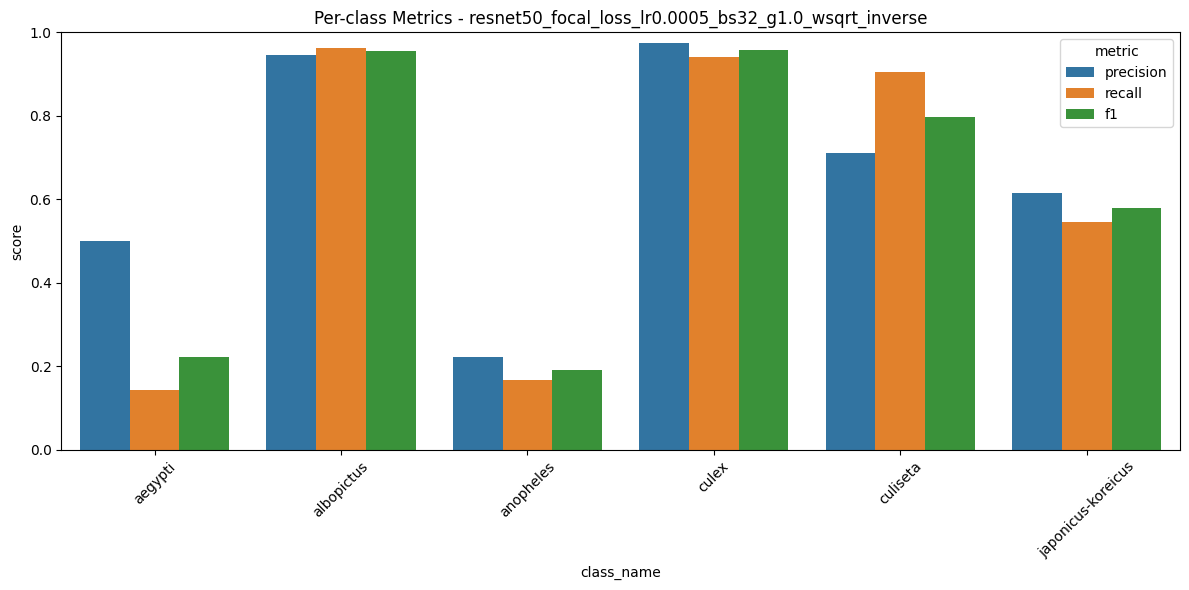

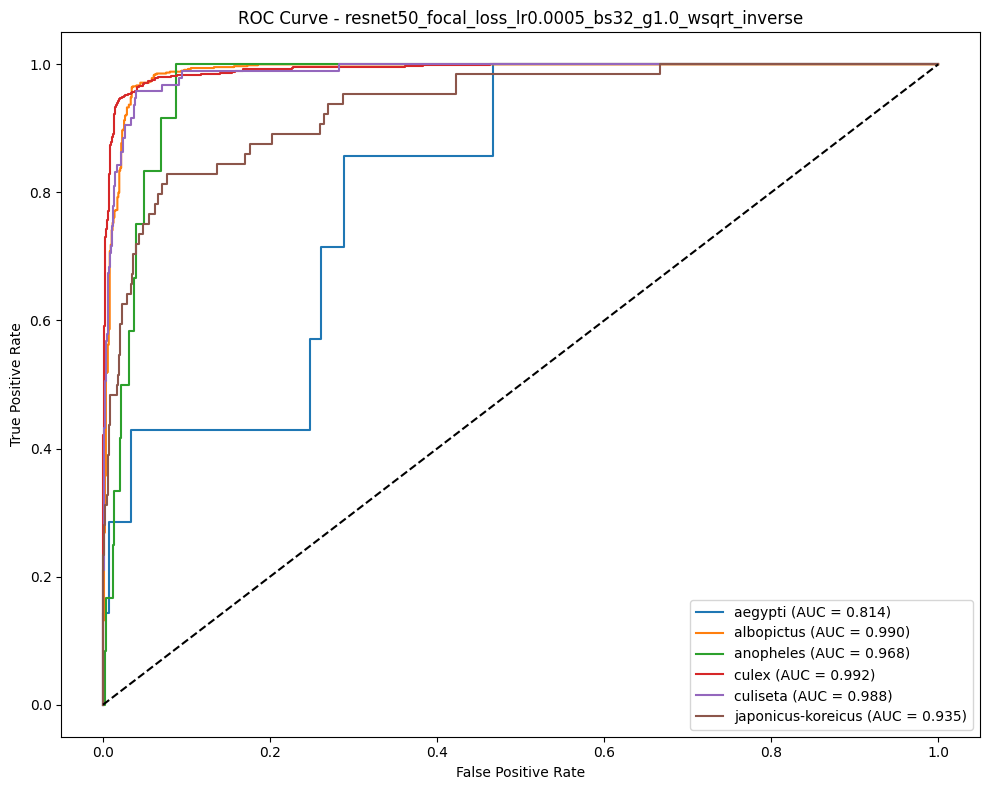

Saved best method plots to: /kaggle/working/best_method_plots


In [23]:
detailed_eval_df = pd.DataFrame(detailed_eval_list)

# =========================
# SAVE BEST METHOD PLOTS
# =========================

plot_dir = Path("/kaggle/working/best_method_plots")
plot_dir.mkdir(parents=True, exist_ok=True)

# best method by macro F1 = best for imbalance/fairness
best_row = detailed_eval_df.sort_values(by="macro_f1", ascending=False).iloc[0]
best_name = best_row["model"]

print("Best method by macro F1:", best_name)

data = all_test_results[best_name]
all_preds = data["preds"]
all_labels = data["labels"]
all_probs = data["probs"]

# 1. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
#plt.savefig(plot_dir / f"{best_name}_confusion_matrix.png", dpi=300)
plt.show()

# 2. Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None,
    zero_division=0
)

per_class_df = pd.DataFrame({
    "class_name": class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

plot_df = per_class_df.melt(
    id_vars=["class_name", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title(f"Per-class Metrics - {best_name}")
plt.tight_layout()
#plt.savefig(plot_dir / f"{best_name}_per_class_metrics.png", dpi=300)
plt.show()

# 3. ROC curve
n_classes = len(class_names)
all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_name}")
plt.legend()
plt.tight_layout()
#plt.savefig(plot_dir / f"{best_name}_roc_curve.png", dpi=300)
plt.show()

print("Saved best method plots to:", plot_dir)

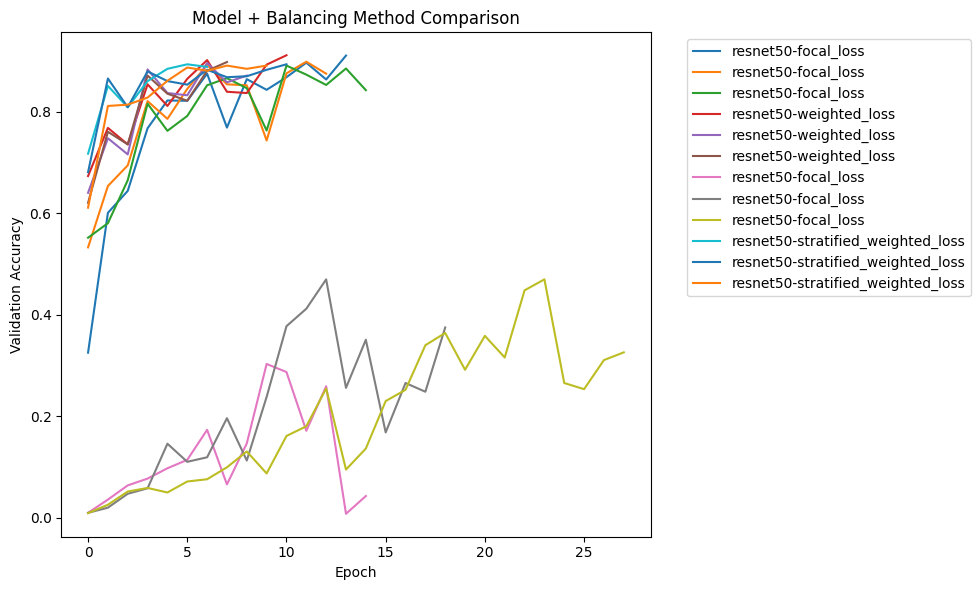

resnet50 + focal_loss → Best: 0.9104
resnet50 + focal_loss → Best: 0.8983
resnet50 + focal_loss → Best: 0.8907
resnet50 + weighted_loss → Best: 0.9110
resnet50 + weighted_loss → Best: 0.8957
resnet50 + weighted_loss → Best: 0.8976
resnet50 + focal_loss → Best: 0.3032
resnet50 + focal_loss → Best: 0.4698
resnet50 + focal_loss → Best: 0.4698
resnet50 + stratified_weighted_loss → Best: 0.8932
resnet50 + stratified_weighted_loss → Best: 0.8932
resnet50 + stratified_weighted_loss → Best: 0.8907


In [24]:
# validation accuracy plot
plt.figure(figsize=(10,6))

for r in all_results:
    label = f"{r['model']}-{r['method']}"
    plt.plot(r["val_acc_history"], label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Model + Balancing Method Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

for r in all_results:
    print(f"{r['model']} + {r['method']} → Best: {r['best_val_acc']:.4f}")


===== Results for resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.9231
           class_name  precision    recall        f1  support
0             aegypti   0.500000  0.142857  0.222222        7
1          albopictus   0.946554  0.962804  0.954610      699
2           anopheles   0.222222  0.166667  0.190476       12
3               culex   0.973254  0.941092  0.956903      696
4            culiseta   0.710744  0.905263  0.796296       95
5  japonicus-koreicus   0.614035  0.546875  0.578512       64


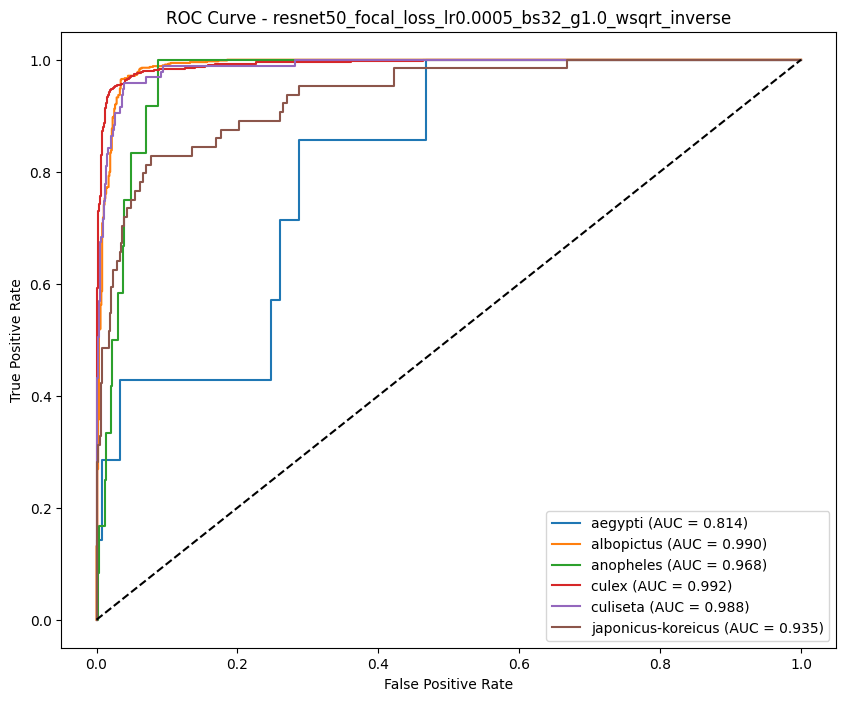

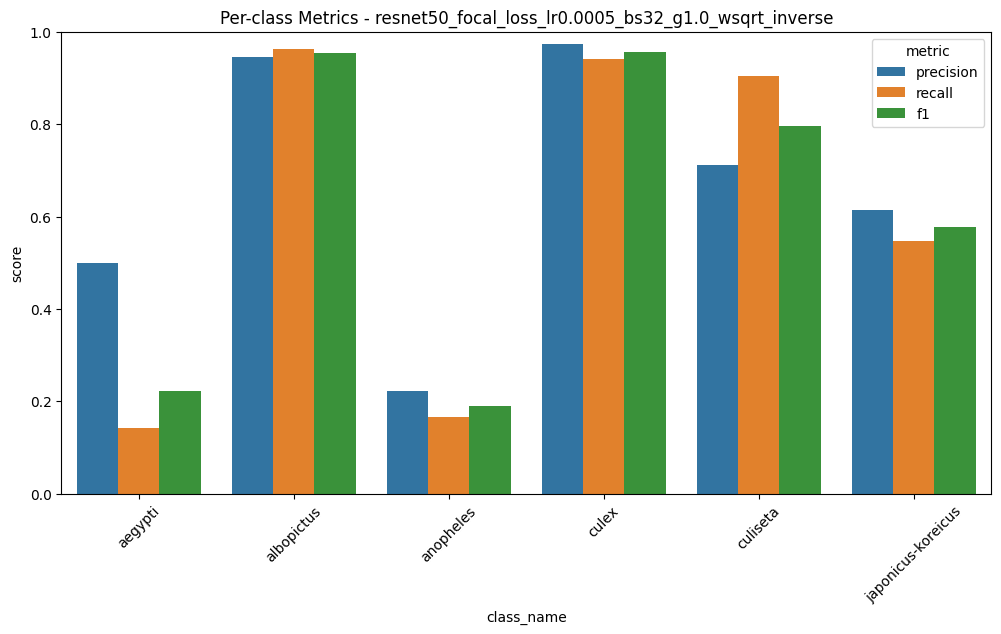


===== Results for resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.8671
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.285714  0.266667        7
1          albopictus   0.962171  0.836910  0.895180      699
2           anopheles   0.187500  0.250000  0.214286       12
3               culex   0.957478  0.938218  0.947750      696
4            culiseta   0.752577  0.768421  0.760417       95
5  japonicus-koreicus   0.296296  0.750000  0.424779       64


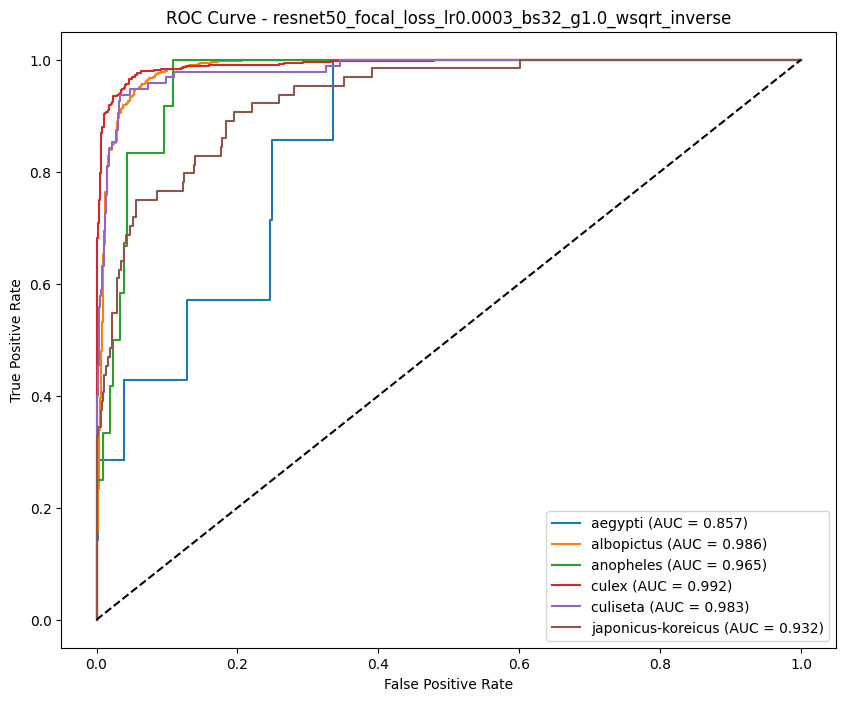

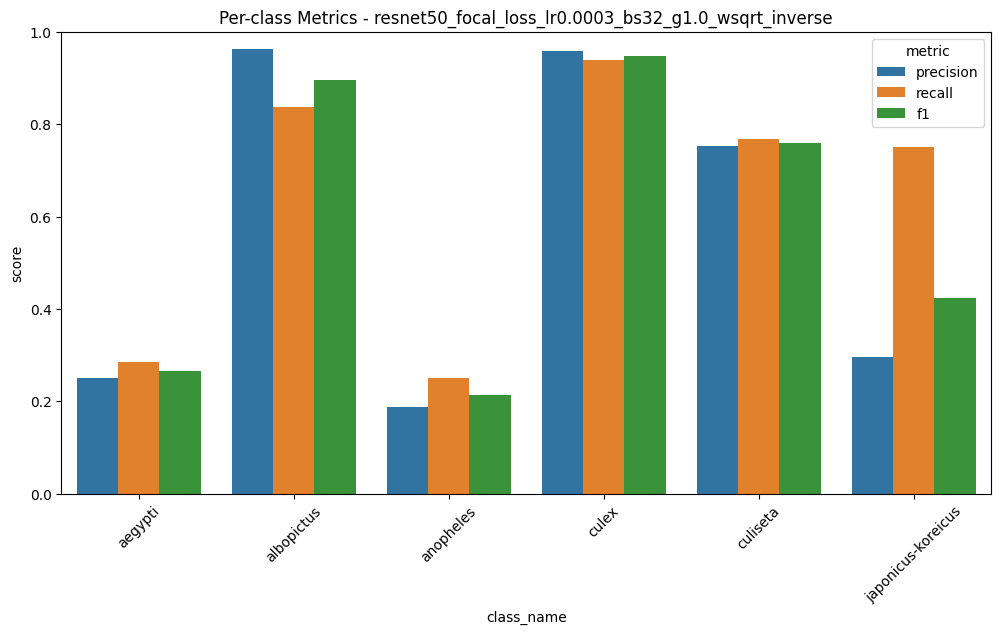


===== Results for resnet50_focal_loss_lr0.0001_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.8665
           class_name  precision    recall        f1  support
0             aegypti   0.166667  0.142857  0.153846        7
1          albopictus   0.963259  0.862661  0.910189      699
2           anopheles   0.125000  0.333333  0.181818       12
3               culex   0.956456  0.915230  0.935389      696
4            culiseta   0.714286  0.789474  0.750000       95
5  japonicus-koreicus   0.311594  0.671875  0.425743       64


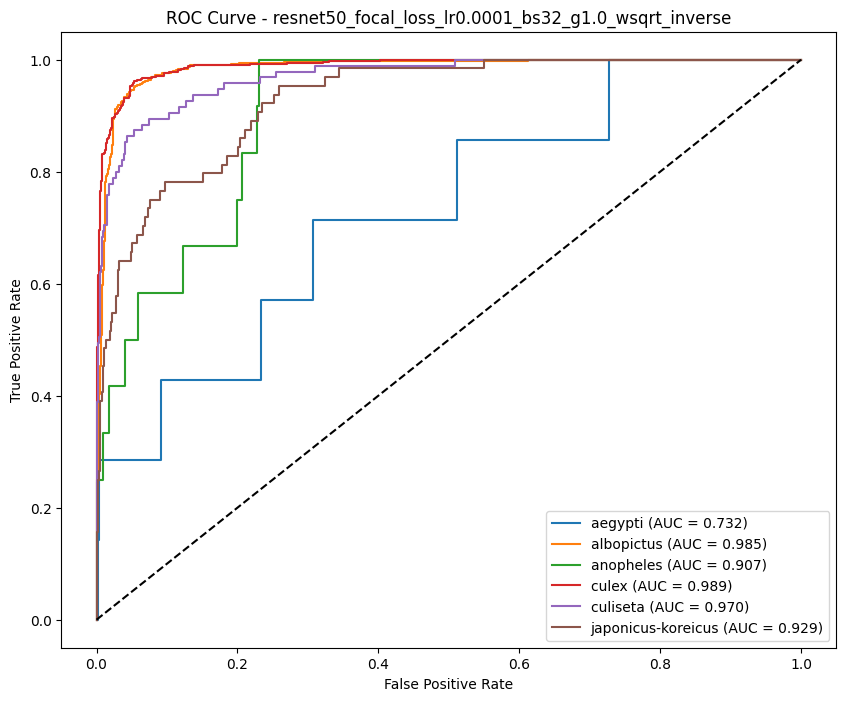

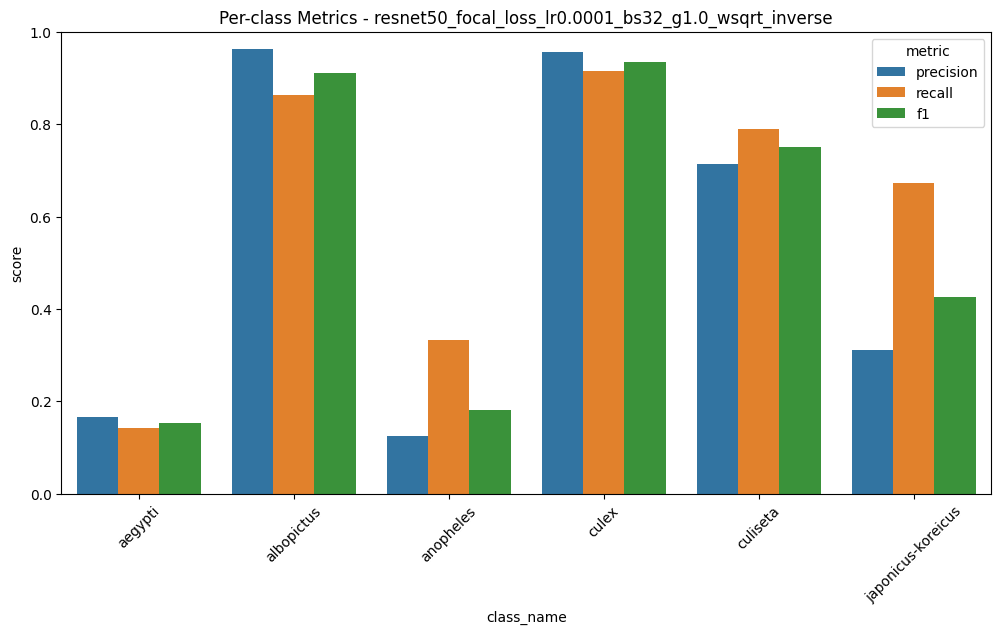


===== Results for resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse =====
Test Accuracy: 0.904
           class_name  precision    recall        f1  support
0             aegypti   0.400000  0.285714  0.333333        7
1          albopictus   0.964018  0.919886  0.941435      699
2           anopheles   0.148148  0.333333  0.205128       12
3               culex   0.946377  0.938218  0.942280      696
4            culiseta   0.715517  0.873684  0.786730       95
5  japonicus-koreicus   0.544118  0.578125  0.560606       64


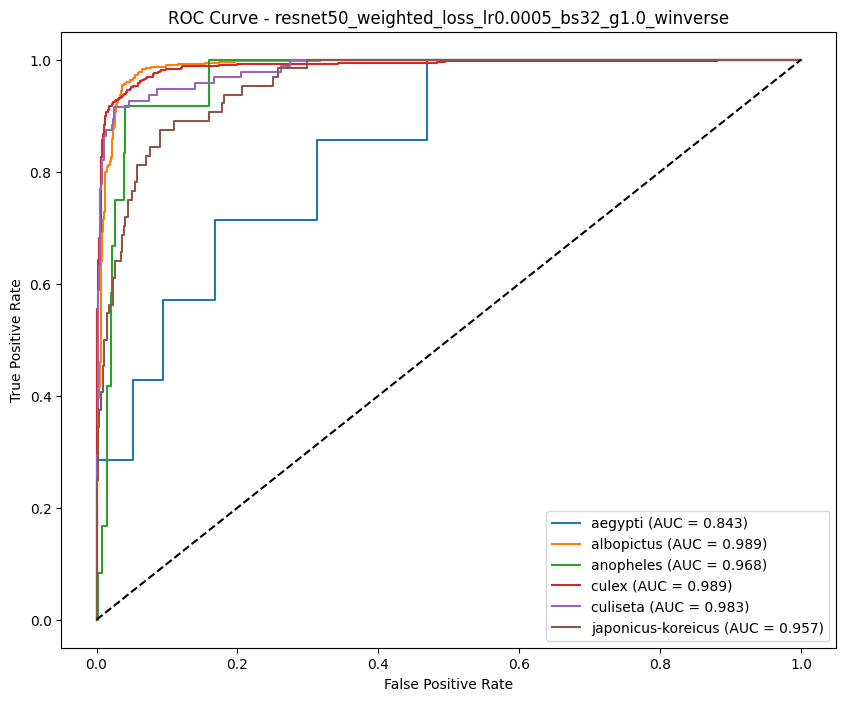

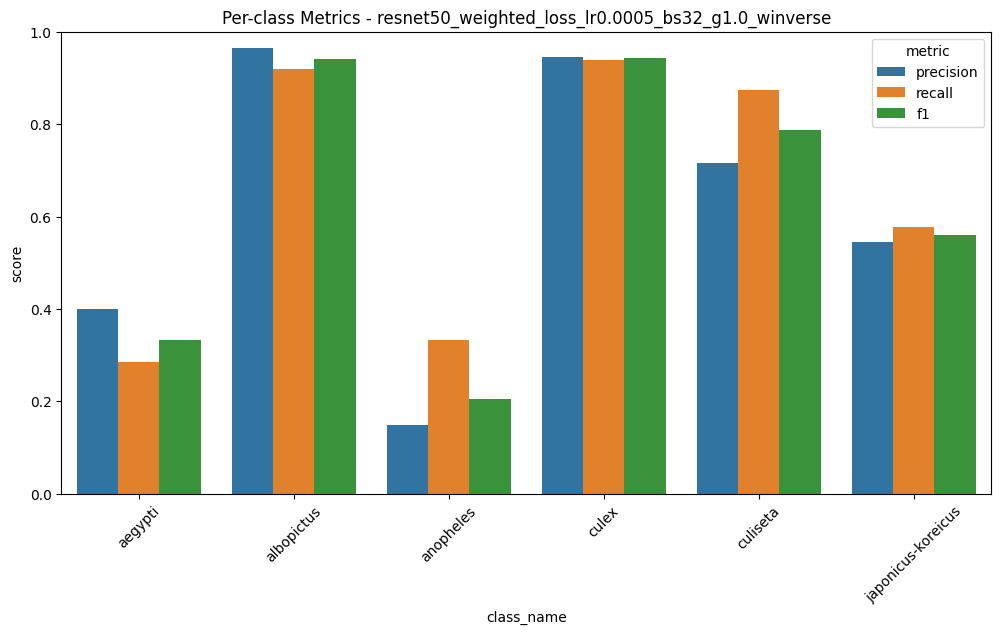


===== Results for resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse =====
Test Accuracy: 0.8652
           class_name  precision    recall        f1  support
0             aegypti   0.181818  0.285714  0.222222        7
1          albopictus   0.972039  0.845494  0.904361      699
2           anopheles   0.166667  0.333333  0.222222       12
3               culex   0.949254  0.913793  0.931186      696
4            culiseta   0.652542  0.810526  0.723005       95
5  japonicus-koreicus   0.359155  0.796875  0.495146       64


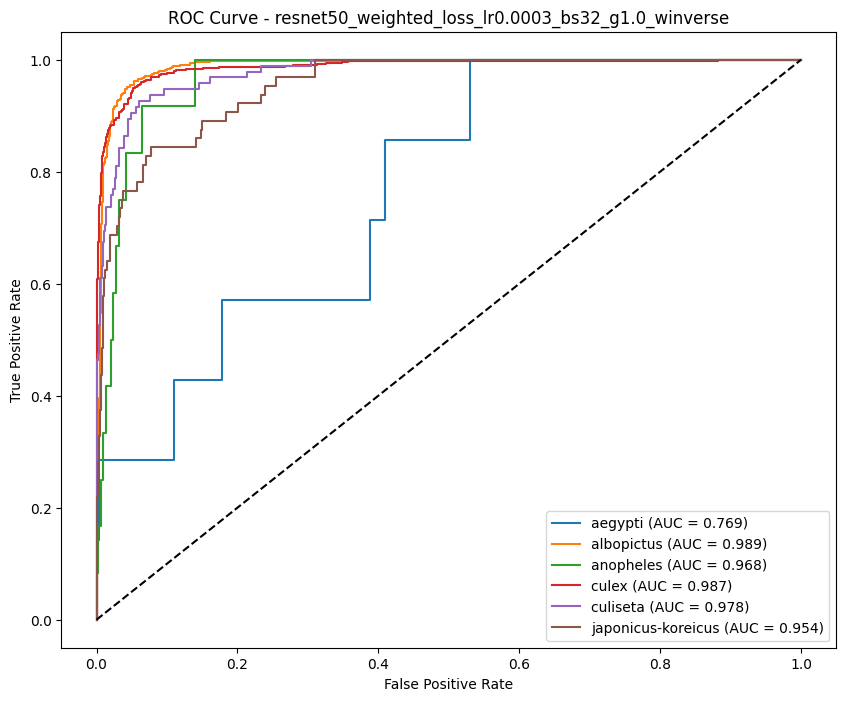

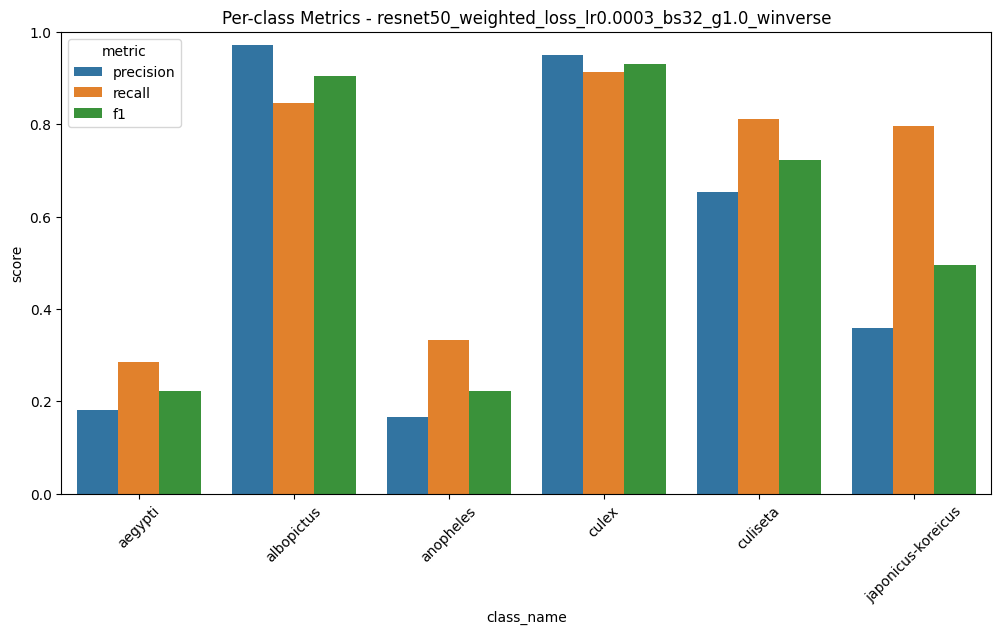


===== Results for resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse =====
Test Accuracy: 0.9034
           class_name  precision    recall        f1  support
0             aegypti   0.285714  0.285714  0.285714        7
1          albopictus   0.936530  0.949928  0.943182      699
2           anopheles   0.333333  0.416667  0.370370       12
3               culex   0.951399  0.928161  0.939636      696
4            culiseta   0.647541  0.831579  0.728111       95
5  japonicus-koreicus   0.609756  0.390625  0.476190       64


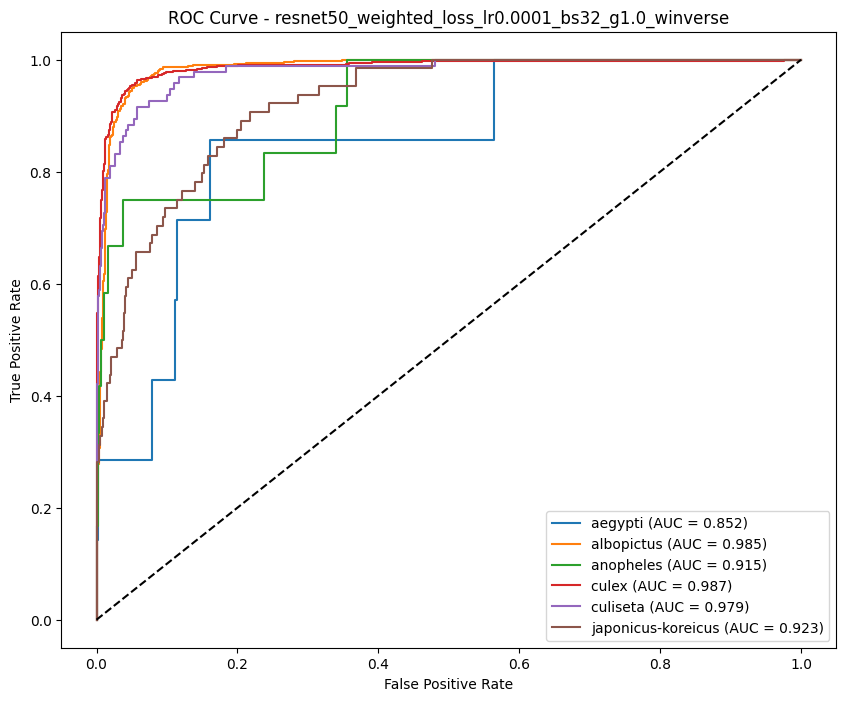

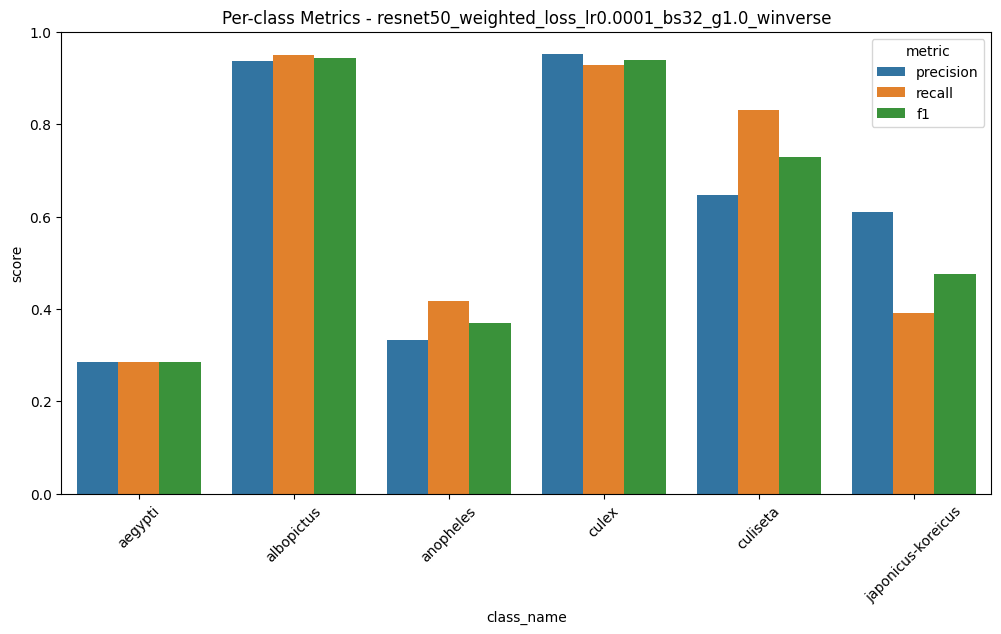


===== Results for resnet50_focal_loss_lr0.0005_bs32_g1.0_winverse =====
Test Accuracy: 0.054
           class_name  precision    recall        f1  support
0             aegypti   0.009669  1.000000  0.019152        7
1          albopictus   0.000000  0.000000  0.000000      699
2           anopheles   0.015564  0.666667  0.030418       12
3               culex   0.000000  0.000000  0.000000      696
4            culiseta   0.333333  0.463158  0.387665       95
5  japonicus-koreicus   0.128079  0.406250  0.194757       64


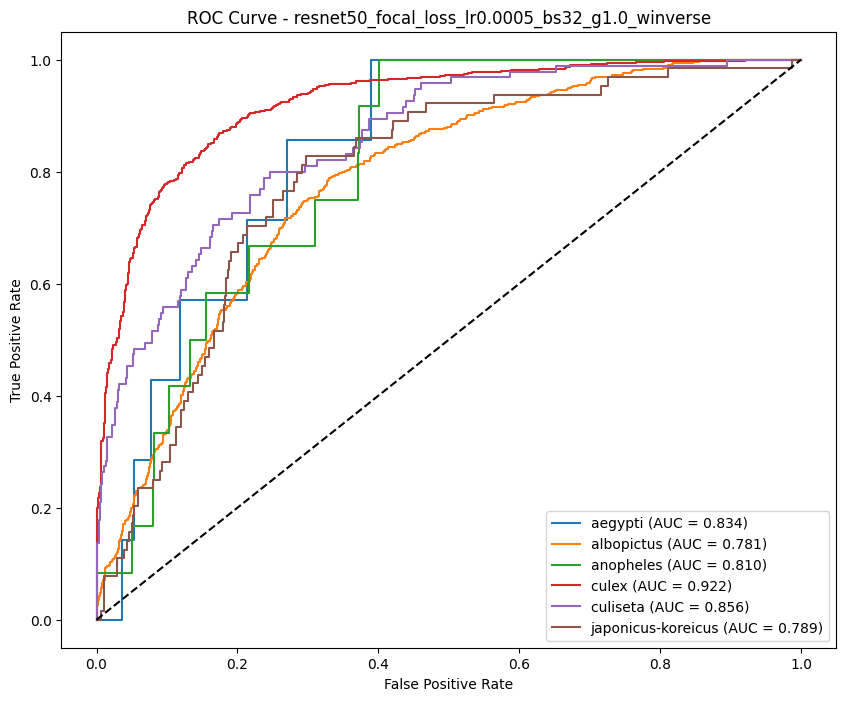

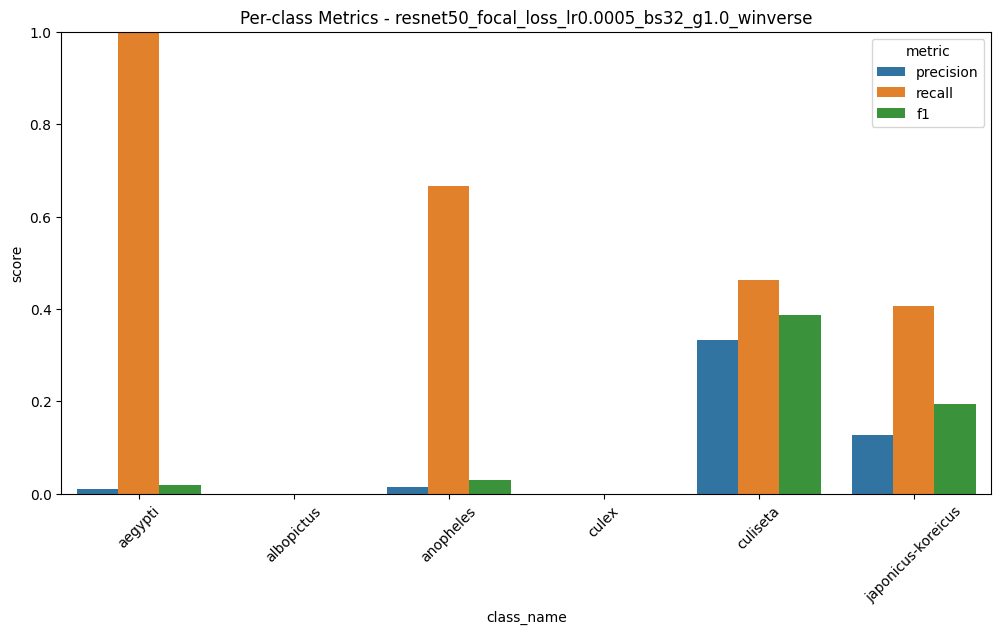


===== Results for resnet50_focal_loss_lr0.0003_bs32_g1.0_winverse =====
Test Accuracy: 0.377
           class_name  precision    recall        f1  support
0             aegypti   0.006369  0.142857  0.012195        7
1          albopictus   0.990099  0.143062  0.250000      699
2           anopheles   0.048544  0.833333  0.091743       12
3               culex   0.994444  0.514368  0.678030      696
4            culiseta   0.342342  0.800000  0.479495       95
5  japonicus-koreicus   0.091082  0.750000  0.162437       64


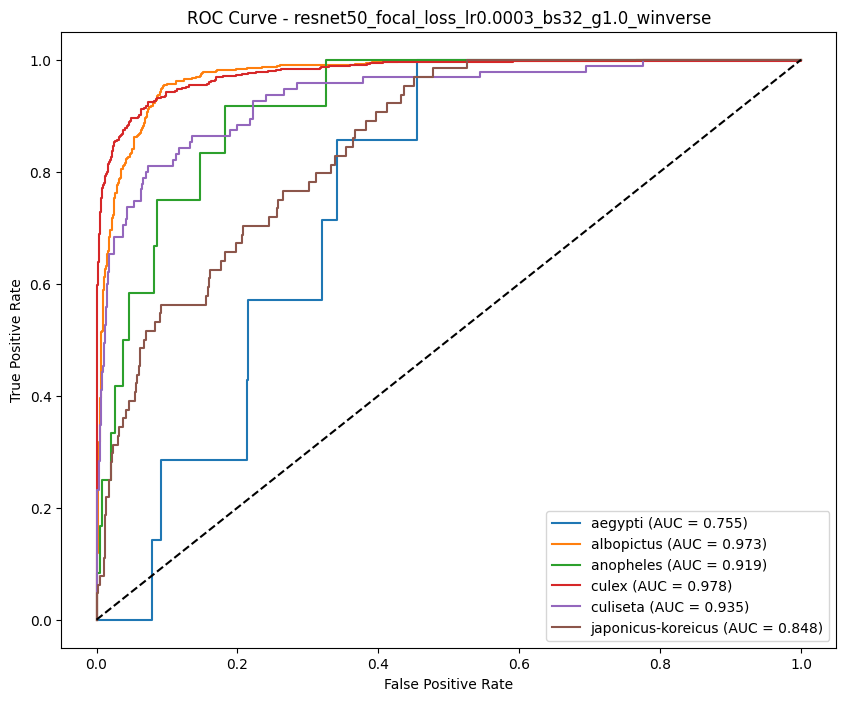

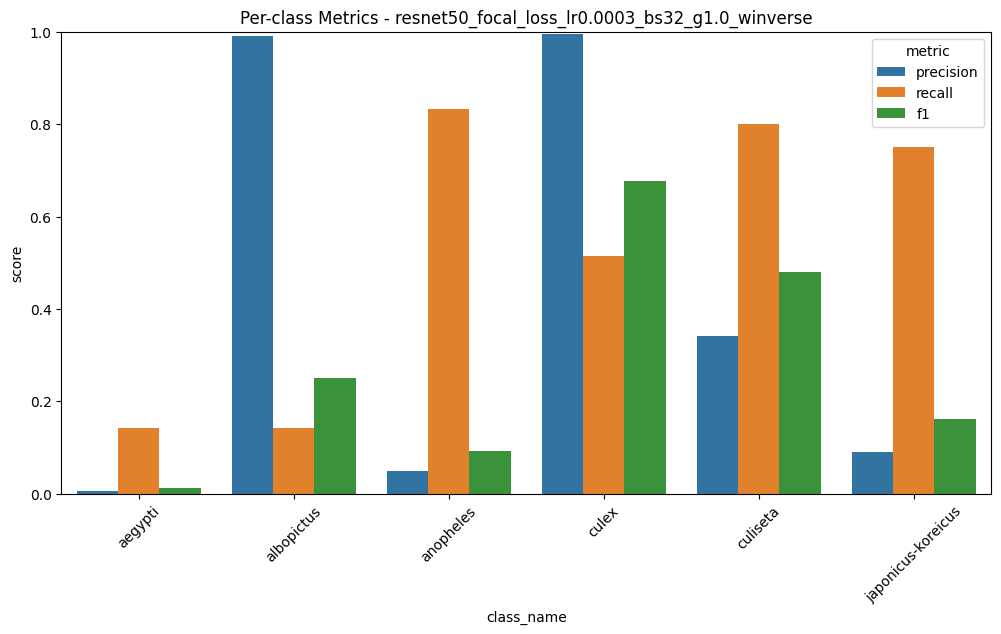


===== Results for resnet50_focal_loss_lr0.0001_bs32_g1.0_winverse =====
Test Accuracy: 0.321
           class_name  precision    recall        f1  support
0             aegypti   0.022222  0.285714  0.041237        7
1          albopictus   0.978723  0.197425  0.328571      699
2           anopheles   0.040724  0.750000  0.077253       12
3               culex   0.987124  0.330460  0.495156      696
4            culiseta   0.241722  0.768421  0.367758       95
5  japonicus-koreicus   0.090444  0.828125  0.163077       64


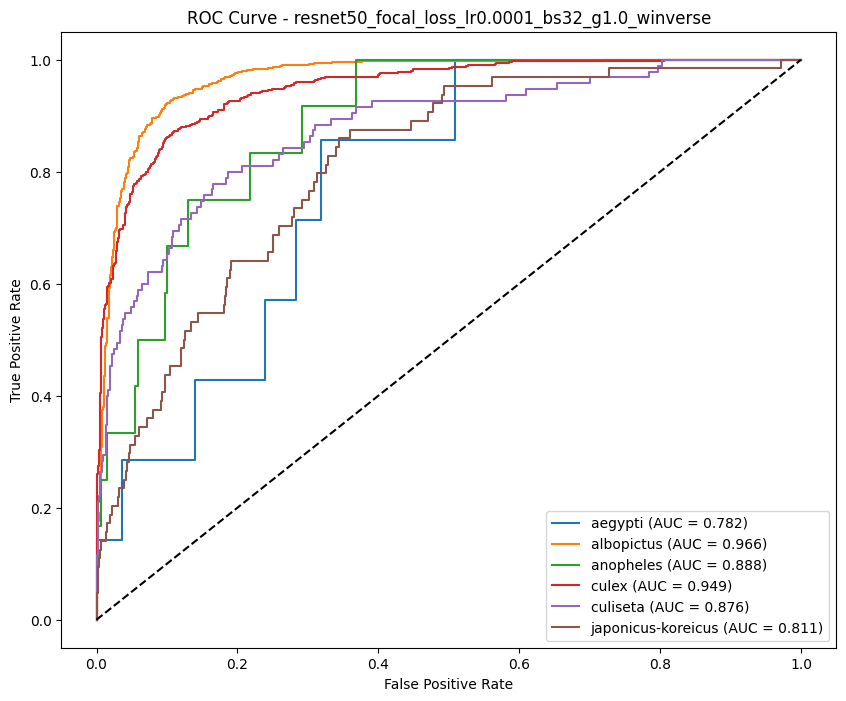

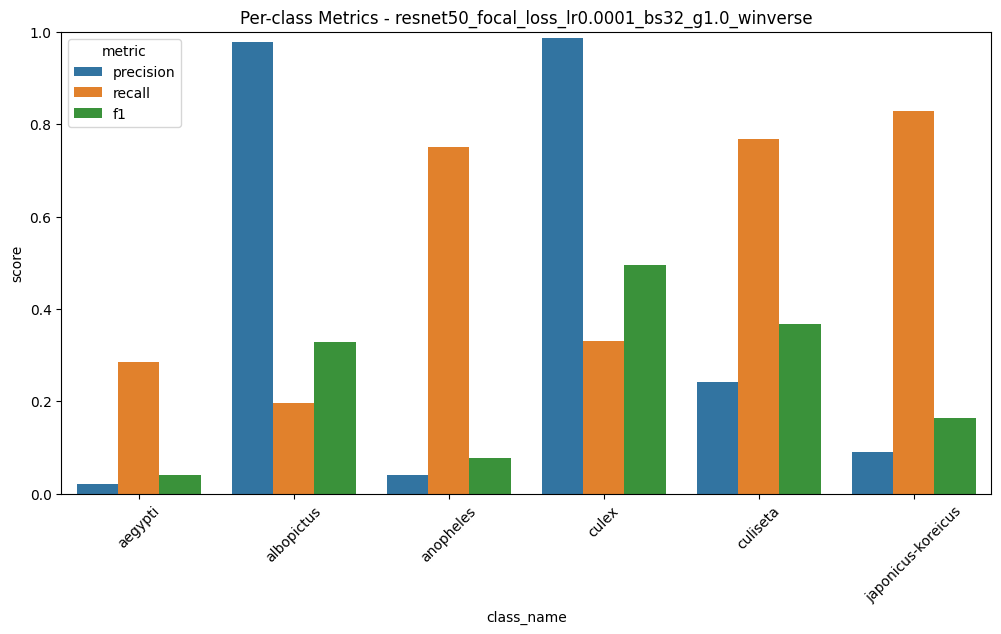


===== Results for resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.8798
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.946349  0.908441  0.927007      699
2           anopheles   0.428571  0.250000  0.315789       12
3               culex   0.971698  0.887931  0.927928      696
4            culiseta   0.541935  0.884211  0.672000       95
5  japonicus-koreicus   0.427184  0.687500  0.526946       64


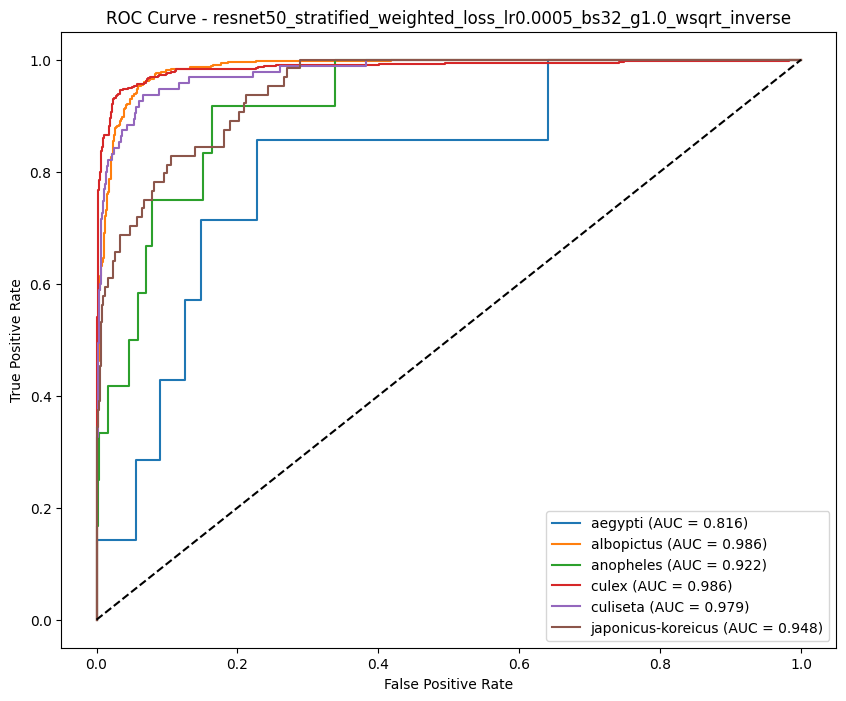

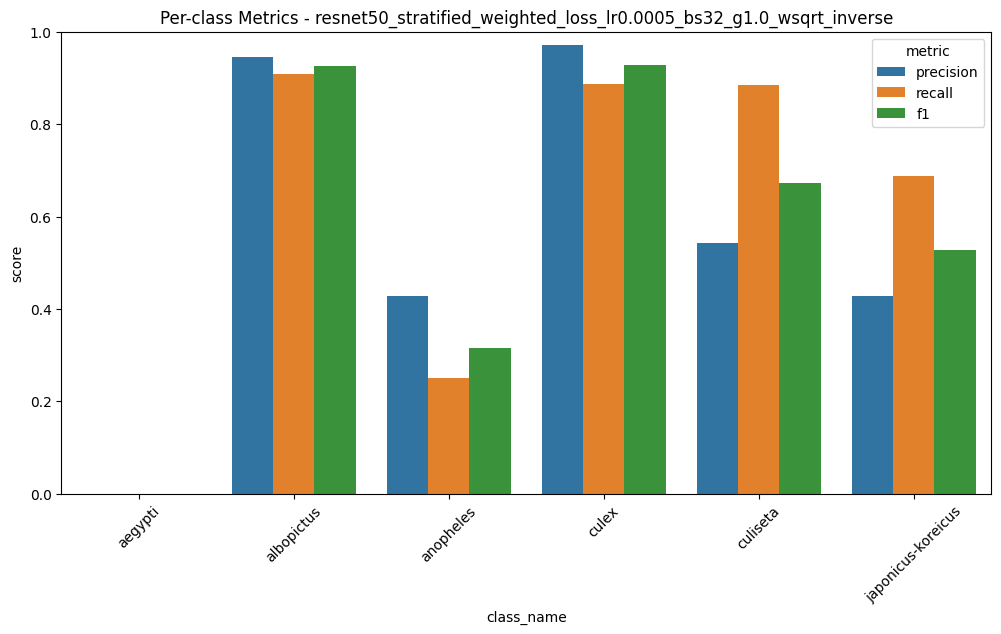


===== Results for resnet50_stratified_weighted_loss_lr0.0003_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.8938
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.963134  0.896996  0.928889      699
2           anopheles   0.666667  0.166667  0.266667       12
3               culex   0.941945  0.932471  0.937184      696
4            culiseta   0.609929  0.905263  0.728814       95
5  japonicus-koreicus   0.477273  0.656250  0.552632       64


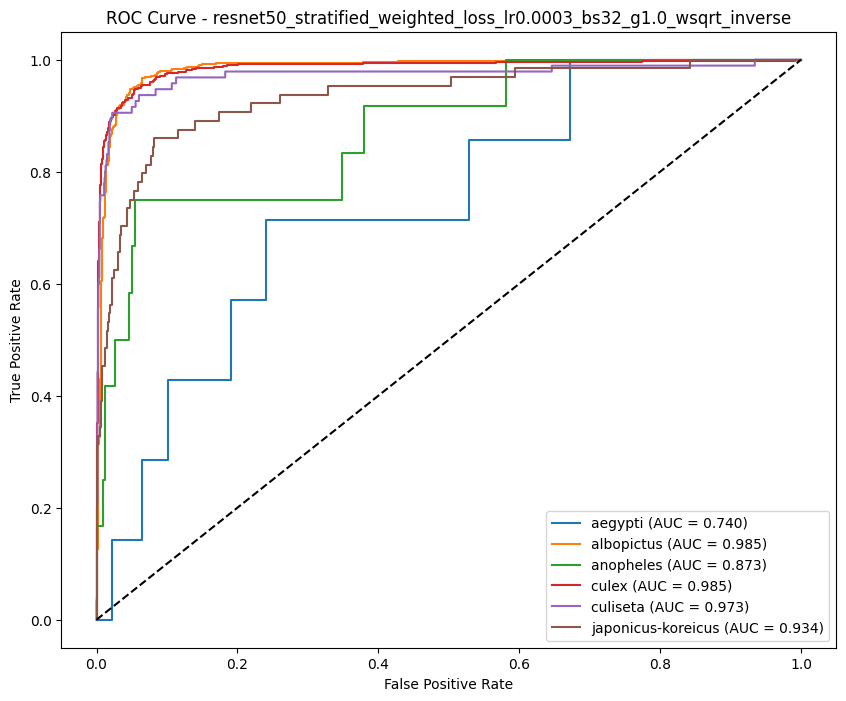

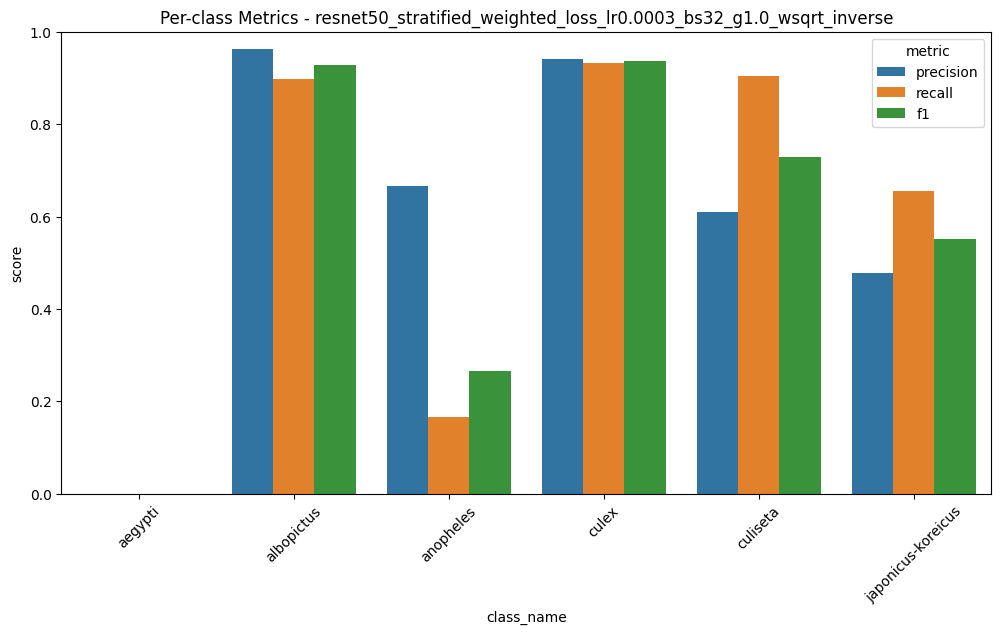


===== Results for resnet50_stratified_weighted_loss_lr0.0001_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.8932
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.947143  0.948498  0.947820      699
2           anopheles   0.285714  0.166667  0.210526       12
3               culex   0.955657  0.897989  0.925926      696
4            culiseta   0.539568  0.789474  0.641026       95
5  japonicus-koreicus   0.565217  0.609375  0.586466       64


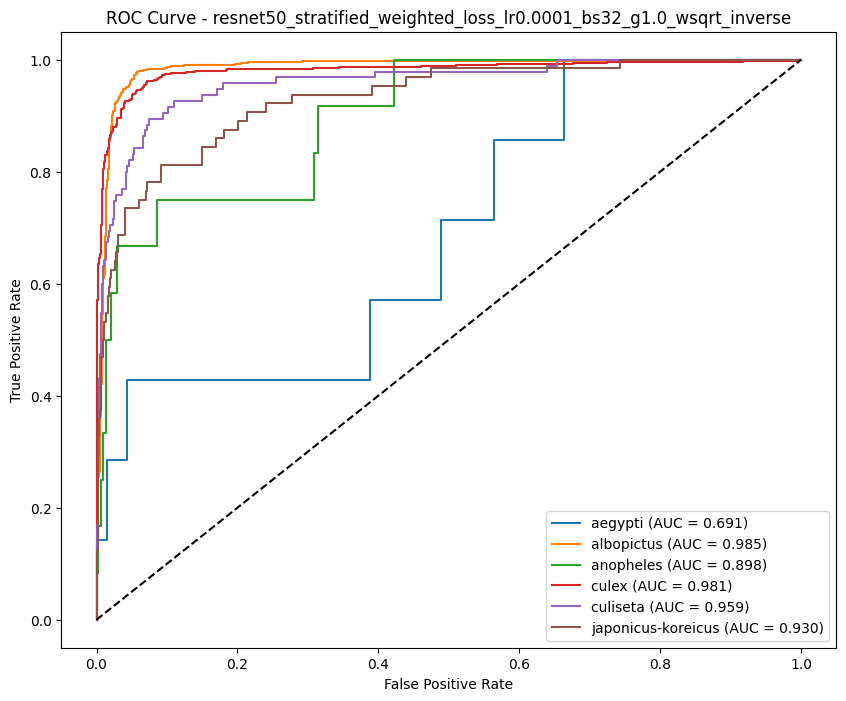

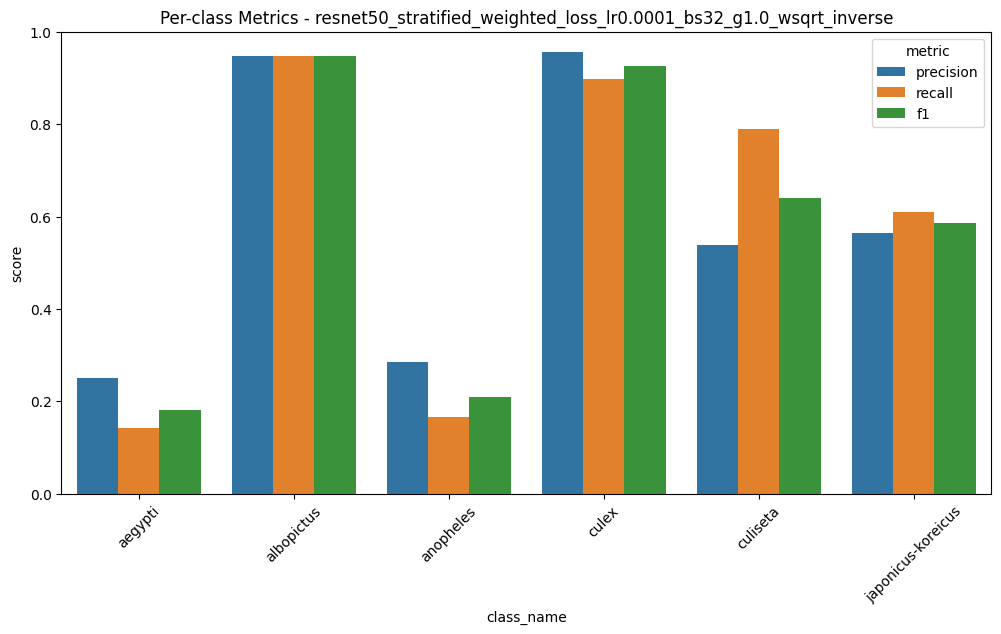

       model                    method  \
3   resnet50             weighted_loss   
0   resnet50                focal_loss   
1   resnet50                focal_loss   
5   resnet50             weighted_loss   
4   resnet50             weighted_loss   
10  resnet50  stratified_weighted_loss   
9   resnet50  stratified_weighted_loss   
2   resnet50                focal_loss   
11  resnet50  stratified_weighted_loss   
7   resnet50                focal_loss   
8   resnet50                focal_loss   
6   resnet50                focal_loss   

                                      val_acc_history  best_val_acc  \
3   [0.6732358550540368, 0.7679593134138589, 0.735...      0.910998   
0   [0.32549268912905277, 0.6007628734901462, 0.64...      0.910362   
1   [0.5327399872854418, 0.6535282898919262, 0.694...      0.898284   
5   [0.6204704386522568, 0.7603305785123967, 0.735...      0.897648   
4   [0.6401780038143674, 0.7476160203432931, 0.715...      0.895741   
10  [0.680864589955499, 0.8

In [25]:
#only for test set plots

summary_list = []

for model_name, data in all_test_results.items():
    print(f"\n===== Results for {model_name} =====")

    all_preds = data["preds"]
    all_labels = data["labels"]
    all_probs = data["probs"]
    
    # ===== Accuracy =====
    acc = accuracy_score(all_labels, all_preds)
    print("Test Accuracy:", round(acc, 4))
    
    # ===== Precision / Recall / F1 per class =====
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    per_class_df = pd.DataFrame({
        "class_name": class_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    })
    print(per_class_df)

    # ===== ROC Curve =====
    n_classes = len(class_names)
    all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    # ===== Bar chart =====
    plot_df = per_class_df.melt(
        id_vars=["class_name", "support"],
        value_vars=["precision", "recall", "f1"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.title(f"Per-class Metrics - {model_name}")
    plt.show()

    
    # ===== Macro metrics =====
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    # ===== Store summary =====
    summary_list.append({
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_ovr": roc_auc
    })

df = pd.DataFrame(all_results)
print(df.sort_values(by="best_val_acc", ascending=False))

df = pd.DataFrame(summary_list)
print(df.sort_values(by="f1_macro", ascending=False))

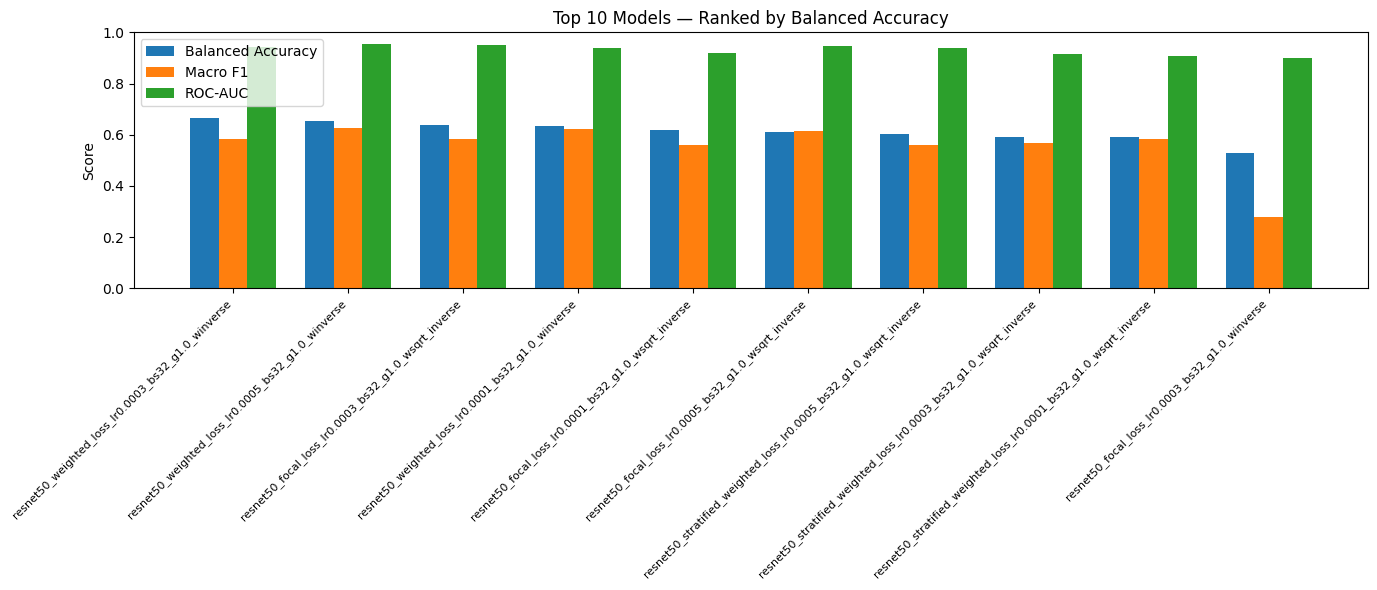

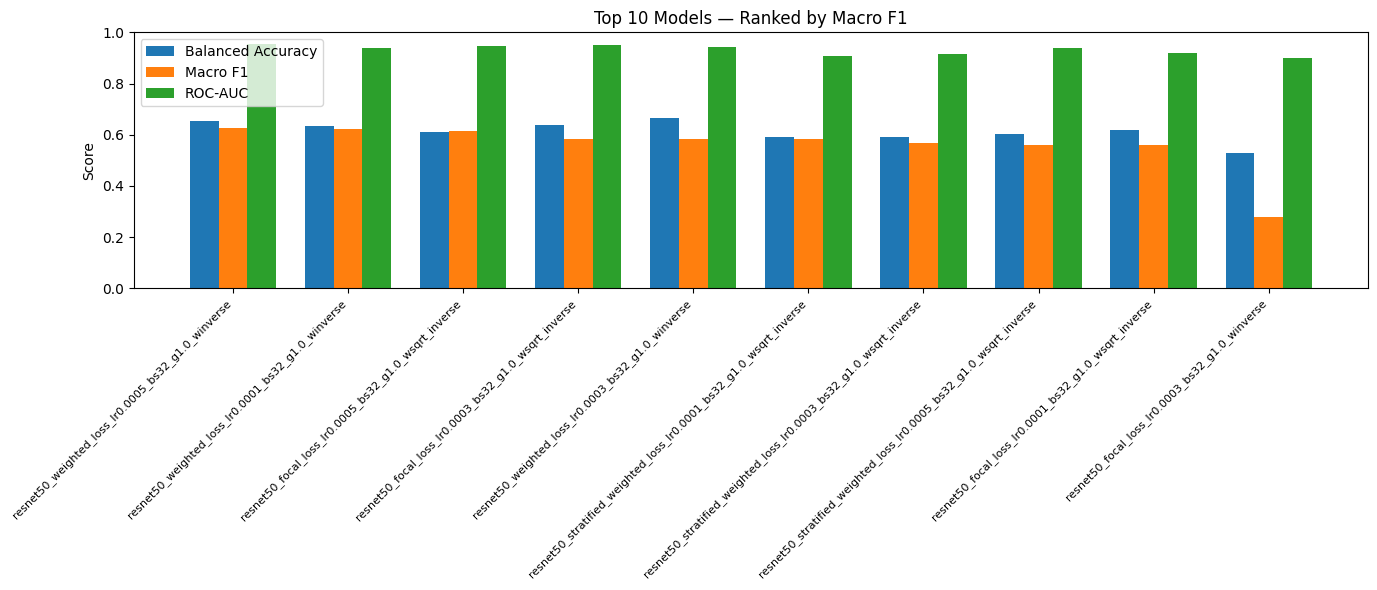

In [26]:
# Pull test-split rows from detailed_eval_df which has balanced_accuracy
test_eval_df = detailed_eval_df[detailed_eval_df["split"] == "test"].copy()

metrics = ["balanced_accuracy", "macro_f1", "roc_auc_ovr"]

def plot_top10(df, rank_by, title):
    top10 = df.sort_values(by=rank_by, ascending=False).head(10)
    x = range(len(top10))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar([i - width for i in x], top10["balanced_accuracy"], width, label="Balanced Accuracy")
    ax.bar([i         for i in x], top10["macro_f1"],          width, label="Macro F1")
    ax.bar([i + width for i in x], top10["roc_auc_ovr"],       width, label="ROC-AUC")

    ax.set_xticks(list(x))
    ax.set_xticklabels(top10["model"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_top10(test_eval_df, rank_by="balanced_accuracy", title="Top 10 Models — Ranked by Balanced Accuracy")
plot_top10(test_eval_df, rank_by="macro_f1",          title="Top 10 Models — Ranked by Macro F1")

In [27]:
#best = max(all_results, key=lambda x: x["best_val_acc"])
best = max(all_results, key=lambda x: x["best_val_balanced_acc"])

print("Best Model:", best["model"])
print("Best Method:", best["method"])
print("Best Accuracy:", best["best_val_acc"])
print("Best Balanced Acc:", best["best_val_balanced_acc"])

Best Model: resnet50
Best Method: weighted_loss
Best Accuracy: 0.9109980928162746
Best Balanced Acc: 0.6859296022160332


# Save Outputs
- training_results.csv
- detailed_eval_results.csv
- BEST_MODEL_FULL.pth
- BEST_MODEL_NAME.txt
- each run folder with pth + loss curve

In [28]:
torch.save(
    best_model_state,
    output_dir / f"BEST_MODEL_{best_run_name}.pth"
)

print("Saved best model:", best_run_name)
print("Best val acc:", best_overall_acc)


torch.save({
    "model_state_dict": best_model_state,
    "run_name": best_run_name,
    "best_val_acc": best_overall_acc,
    "best_val_balanced_acc": best_overall_balanced_acc
}, output_dir / "BEST_MODEL_FULL.pth")



with open(output_dir / "BEST_MODEL_NAME.txt", "w") as f:
    f.write(best_run_name)

results_df.to_csv(output_dir / "training_results.csv", index=False)
detailed_eval_df.to_csv(output_dir / "detailed_eval_results.csv", index=False)
summary_df = pd.DataFrame(summary_list)
summary_df.to_csv(output_dir / "test_summary.csv", index=False)

Saved best model: resnet50_weighted_loss_lr0.0005_bs32_ep30_g1.0_winverse
Best val acc: 0.9109980928162746


Model files:

 - BEST_MODEL_{best_run_name}.pth - just the state dict of the best model
 - BEST_MODEL_FULL.pth - a dict containing the state dict, run name, and best val accuracy together
 - BEST_MODEL_NAME.txt - just the run name as a plain text file (useful for quickly checking which config won without loading the model)


CSVs:

 - training_results.csv - from results_df, which is the training loop results (val acc history, best val acc, method, lr, batch size, gamma, weight formula etc.)
 - detailed_eval_results.csv - from detailed_eval_df, which is the richest file — has per-split (train/val/test) metrics for every model including balanced accuracy, macro/weighted F1, precision, recall, ROC-AUC
 - test_summary.csv - (the test-only summary) (detailed_eval_results.csv already contains everything)